In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDPLag.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Syn.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/MSSQL.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Portmap.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/LDAP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NetBIOS.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_SSDP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NTP.csv
/kaggle/input

In [2]:
import pandas as pd
import numpy as np
import os

# Disable scientific notation for easier reading
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Base directories based on your Kaggle environment
CIC2017_DIR = "/kaggle/input/datasets/zufarasyraf/cicids2017/" 
UNSW_DIR = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/"

# Hardcoded UNSW headers extracted from NUSW-NB15_features.csv
UNSW_COLUMNS = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 
    'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 
    'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 
    'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 
    'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 
    'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 
    'ct_dst_src_ltm', 'attack_cat', 'label'
]

print("Environment setup complete. Base directories and UNSW headers defined.")

Environment setup complete. Base directories and UNSW headers defined.


In [3]:
print("========== STEP 1: VERIFYING & LOADING CICIDS2017 ==========")

# Pairs to verify: (Base File, Numbered File)
file_pairs = [
    ("DoS_GoldenEye.csv", "DoS_GoldenEye-12293.csv"),
    ("DoS_Hulk.csv", "DoS_Hulk-24069.csv"),
    ("DoS_Slowhttptest.csv", "DoS_Slowhttptest-15113.csv"),
    ("FTP_Patator_CICIDS2017.csv", "FTP_Patator-56169.csv"),
    ("SSH_Patator_CICIDS2017.csv", "SSH_Patator-12718.csv"),
    ("Web_Attack___Brute_Force.csv", "Web_Attack_Brute_Force-9348.csv"),
    ("Web_Attack___SQL_Injection.csv", "Web_Attack_SQL_Injection-17197.csv")
]

# Single files to keep directly
standalone_files = ["BENIGN_CICIDS2017.csv"]

cic_dfs = []

def inspect_df(df, filename):
    print(f"\n--- Inspecting: {filename} ---")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Timestamp Head
    ts_col = ' Timestamp' if ' Timestamp' in df.columns else 'Timestamp'
    if ts_col in df.columns:
        print(f"\n{ts_col} Format Check (First 5):")
        print(df[ts_col].head(5).values)
    else:
        print("\n⚠️ Timestamp column not found!")
        
    # Label Value Counts
    label_col = ' Label' if ' Label' in df.columns else 'Label'
    if label_col in df.columns:
        print(f"\n'{label_col}' Value Counts:")
        print(df[label_col].value_counts(dropna=False))
    else:
        print("\n⚠️ Label column not found!")
        
    # Nulls and Infs
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f"\nColumns with >0 Nulls:\n{null_counts[null_counts > 0]}")
    else:
        print("\nColumns with >0 Nulls: None")
    
    num_cols = df.select_dtypes(include=[np.number]).columns
    inf_counts = df[num_cols].isin([np.inf, -np.inf]).sum()
    if inf_counts.sum() > 0:
        print(f"Columns with >0 Infs:\n{inf_counts[inf_counts > 0]}")
    else:
        print("Columns with >0 Infs: None")

# Process Pairs
for base, numbered in file_pairs:
    path_base = os.path.join(CIC2017_DIR, base)
    path_num = os.path.join(CIC2017_DIR, numbered)
    
    if os.path.exists(path_base) and os.path.exists(path_num):
        df_base = pd.read_csv(path_base, low_memory=False)
        df_num = pd.read_csv(path_num, low_memory=False)
        
        if df_base.shape[0] >= df_num.shape[0]:
            print(f"\n✅ KEEPING {base} ({df_base.shape[0]} rows) OVER {numbered} ({df_num.shape[0]} rows)")
            inspect_df(df_base, base)
            cic_dfs.append(df_base)
        else:
            print(f"\n✅ KEEPING {numbered} ({df_num.shape[0]} rows) OVER {base} ({df_base.shape[0]} rows)")
            inspect_df(df_num, numbered)
            cic_dfs.append(df_num)
            
# Process Standalone files
for file in standalone_files:
    path = os.path.join(CIC2017_DIR, file)
    if os.path.exists(path):
        print(f"\n✅ LOADING STANDALONE: {file}")
        df_stand = pd.read_csv(path, low_memory=False)
        inspect_df(df_stand, file)
        cic_dfs.append(df_stand)

========== STEP 1: VERIFYING & LOADING CICIDS2017 ==========

✅ KEEPING DoS_GoldenEye-12293.csv (12293 rows) OVER DoS_GoldenEye.csv (7567 rows)

--- Inspecting: DoS_GoldenEye-12293.csv ---
Shape: 12293 rows, 91 columns

Timestamp Format Check (First 5):
['2024-05-05 10:30:47.529737' '2024-05-05 10:30:47.531047'
 '2024-05-05 10:30:47.532107' '2024-05-05 10:30:47.532939'
 '2024-05-05 10:30:47.533914']

'Label' Value Counts:
Label
DoS GoldenEye    12293
Name: count, dtype: int64

Columns with >0 Nulls: None
Columns with >0 Infs: None

✅ KEEPING DoS_Hulk.csv (158468 rows) OVER DoS_Hulk-24069.csv (24069 rows)

--- Inspecting: DoS_Hulk.csv ---
Shape: 158468 rows, 91 columns

Timestamp Format Check (First 5):
['2017-07-05 13:43:23.194704' '2017-07-05 13:43:23.194713'
 '2017-07-05 13:43:23.195020' '2017-07-05 13:43:23.196131'
 '2017-07-05 13:43:23.197238']

'Label' Value Counts:
Label
DoS Hulk    158468
Name: count, dtype: int64

Columns with >0 Nulls: None
Columns with >0 Infs: None

✅ KEEPIN

In [4]:
print("========== STEP 2: CONCAT & SORT CICIDS2017 ==========")

if cic_dfs:
    df_cic_full = pd.concat(cic_dfs, ignore_index=True)
    
    print(f"\nConcatenated CICIDS2017 Shape: {df_cic_full.shape}")
    
    label_col = ' Label' if ' Label' in df_cic_full.columns else 'Label'
    print(f"\nLabel Distribution post-concat:\n{df_cic_full[label_col].value_counts(dropna=False)}")
    
    # Clean up Timestamp and Sort
    ts_col = ' Timestamp' if ' Timestamp' in df_cic_full.columns else 'Timestamp'
    if ts_col in df_cic_full.columns:
        print("\nParsing Timestamps (this may take a moment)...")
        df_cic_full['Parsed_Time'] = pd.to_datetime(df_cic_full[ts_col].str.strip(), format='mixed', dayfirst=True, errors='coerce')
        
        # Sort values
        df_cic_full.sort_values(by='Parsed_Time', ascending=True, inplace=True)
        df_cic_full.reset_index(drop=True, inplace=True)
        
        print("\nSorting Complete.")
        print(f"Earliest Timestamp: {df_cic_full['Parsed_Time'].min()}")
        print(f"Latest Timestamp:   {df_cic_full['Parsed_Time'].max()}")
        
else:
    print("No CICIDS2017 files loaded.")

========== STEP 2: CONCAT & SORT CICIDS2017 ==========

Concatenated CICIDS2017 Shape: (596412, 91)

Label Distribution post-concat:
Label
BENIGN                        315106
DoS Hulk                      158468
FTP-Patator                    56169
Web Attack - SQL Injection     17197
DoS Slowhttptest               15113
SSH-Patator                    12718
DoS GoldenEye                  12293
Web Attack - Brute Force        9348
Name: count, dtype: int64

Parsing Timestamps (this may take a moment)...

Sorting Complete.
Earliest Timestamp: 2017-07-04 11:53:44.398274
Latest Timestamp:   2024-05-07 07:44:32.355461


In [5]:
print("========== STEP 3: UNSW-NB15 LOADING & SORTING ==========")

unsw_files = [
    os.path.join(UNSW_DIR, "UNSW-NB15_1.csv"),
    os.path.join(UNSW_DIR, "UNSW-NB15_2.csv"),
    os.path.join(UNSW_DIR, "UNSW-NB15_3.csv"),
    os.path.join(UNSW_DIR, "UNSW-NB15_4.csv")
]

unsw_dfs = []

for file in unsw_files:
    if os.path.exists(file):
        print(f"Loading {os.path.basename(file)} and applying explicit headers...")
        # header=None ensures the first row of data isn't eaten, names=UNSW_COLUMNS applies our list
        df_temp = pd.read_csv(file, low_memory=False, header=None, names=UNSW_COLUMNS)
        unsw_dfs.append(df_temp)

if unsw_dfs:
    df_unsw_full = pd.concat(unsw_dfs, ignore_index=True)
    
    if 'stime' in df_unsw_full.columns:
        print("\nSorting by 'stime' ascending...")
        df_unsw_full.sort_values(by='stime', ascending=True, inplace=True)
        df_unsw_full.reset_index(drop=True, inplace=True)
        print("Sorting complete.")
    else:
        print("\n⚠️ 'stime' column not found! Check header extraction.")

    print(f"\nUNSW-NB15 Concatenated Shape: {df_unsw_full.shape}")
    
    if 'attack_cat' in df_unsw_full.columns:
        print(f"\n'attack_cat' Value Counts:\n{df_unsw_full['attack_cat'].value_counts(dropna=False)}")
        
    if 'label' in df_unsw_full.columns:
        print(f"\n'label' Value Counts:\n{df_unsw_full['label'].value_counts(dropna=False)}")
        
    null_counts_unsw = df_unsw_full.isnull().sum()
    if null_counts_unsw.sum() > 0:
        print(f"\nColumns with >0 Nulls:\n{null_counts_unsw[null_counts_unsw > 0]}")
    else:
        print("\nColumns with >0 Nulls: None")
else:
    print("No UNSW files found to load.")

========== STEP 3: UNSW-NB15 LOADING & SORTING ==========
Loading UNSW-NB15_1.csv and applying explicit headers...
Loading UNSW-NB15_2.csv and applying explicit headers...
Loading UNSW-NB15_3.csv and applying explicit headers...
Loading UNSW-NB15_4.csv and applying explicit headers...

Sorting by 'stime' ascending...
Sorting complete.

UNSW-NB15 Concatenated Shape: (2540047, 49)

'attack_cat' Value Counts:
attack_cat
NaN                 2218764
Generic              215481
Exploits              44525
 Fuzzers              19195
DoS                   16353
 Reconnaissance       12228
 Fuzzers               5051
Analysis               2677
Backdoor               1795
Reconnaissance         1759
 Shellcode             1288
Backdoors               534
Shellcode               223
Worms                   174
Name: count, dtype: int64

'label' Value Counts:
label
0    2218764
1     321283
Name: count, dtype: int64

Columns with >0 Nulls:
ct_flw_http_mthd    1348145
is_ftp_login        1429879


In [6]:
print("========== STEP 4: CROSS-CHECK COLUMNS ==========")

print("\n--- CICIDS2017 Columns ---")
if 'df_cic_full' in locals():
    cic_cols = [c.strip() for c in df_cic_full.columns]
    print(cic_cols)

print("\n--- UNSW-NB15 Columns ---")
if 'df_unsw_full' in locals():
    unsw_cols = df_unsw_full.columns.tolist()
    print(unsw_cols)

print("\n" + "="*50)
print("MANUAL MAPPING & DERIVATION NOTES")
print("="*50)
print("""
[DIRECT MAPPINGS]
CICIDS2017                      UNSW-NB15
Destination Port       <--->    dsport
Source Port            <--->    sport
Protocol               <--->    proto
Flow Duration          <--->    dur
Total Fwd Packets      <--->    spkts
Total Backward Packets <--->    dpkts
Total Length of Fwd    <--->    sbytes
Total Length of Bwd    <--->    dbytes
Fwd Packet Length Mean <--->    smeansz
Bwd Packet Length Mean <--->    dmeansz

[DERIVATIONS REQUIRED IN UNSW]
- Flow Bytes/s   = (sbytes + dbytes) / dur
- Flow Packets/s = (spkts + dpkts) / dur

[MISSING / NON-OVERLAPPING]
- TCP Flags: CICIDS2017 has specific 'SYN Flag Count', 'FIN Flag Count', etc. 
  UNSW uses 'state' and other counts. Need to fill missing flags with 0.
""")

========== STEP 4: CROSS-CHECK COLUMNS ==========

--- CICIDS2017 Columns ---
['id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std

In [7]:
print("========== STEP 1: FIXING UNSW LABELS ==========")

# Strip whitespace from attack_cat column
df_unsw_full['attack_cat'] = df_unsw_full['attack_cat'].str.strip()

# Merge Backdoors -> Backdoor
df_unsw_full['attack_cat'] = df_unsw_full['attack_cat'].replace('Backdoors', 'Backdoor')

# Fill null attack_cat with "BENIGN"
df_unsw_full['attack_cat'].fillna('BENIGN', inplace=True)

# Fill nulls for specific numerical columns with 0
df_unsw_full['ct_flw_http_mthd'].fillna(0, inplace=True)
df_unsw_full['is_ftp_login'].fillna(0, inplace=True)

print("\nCleaned UNSW 'attack_cat' Value Counts:")
print(df_unsw_full['attack_cat'].value_counts(dropna=False))

========== STEP 1: FIXING UNSW LABELS ==========

Cleaned UNSW 'attack_cat' Value Counts:
attack_cat
BENIGN            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64


/tmp/ipykernel_58/2147075682.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_unsw_full['attack_cat'].fillna('BENIGN', inplace=True)
/tmp/ipykernel_58/2147075682.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [8]:
print("========== STEP 2: DERIVING UNSW FEATURES ==========")

# Handle duration = 0 by temporarily replacing with NaN for calculation, then fill result with 0
safe_dur = df_unsw_full['dur'].replace(0, np.nan)

# Create flow bytes and packets per second
df_unsw_full['flow_bytes_per_sec'] = ((df_unsw_full['sbytes'] + df_unsw_full['dbytes']) / safe_dur).fillna(0)
df_unsw_full['flow_packets_per_sec'] = ((df_unsw_full['spkts'] + df_unsw_full['dpkts']) / safe_dur).fillna(0)

# Create flag columns with 0
flags = ['syn_flag_count', 'fin_flag_count', 'rst_flag_count', 'ack_flag_count']
for flag in flags:
    df_unsw_full[flag] = 0

# Add missingness indicator
df_unsw_full['flag_missing'] = 1

print(f"Derived {len(flags) + 3} new columns for UNSW-NB15.")

========== STEP 2: DERIVING UNSW FEATURES ==========
Derived 7 new columns for UNSW-NB15.


In [9]:
print("========== STEP 3: CICIDS2017 TEMPORAL SPLIT ==========")

# Assuming 'Label' or ' Label' exists. Let's strip column names first for safety.
df_cic_full.columns = df_cic_full.columns.str.strip()

def create_temporal_split(group):
    n = len(group)
    train_end = int(0.70 * n)
    val_end = int(0.85 * n)
    
    # Create an array of strings for the split
    sets = np.empty(n, dtype=object)
    sets[:train_end] = 'train'
    sets[train_end:val_end] = 'val'
    sets[val_end:] = 'test'
    
    group['split_set'] = sets
    return group

# Group by attack label and apply the sequential split
df_cic_full = df_cic_full.groupby('Label', group_keys=False).apply(create_temporal_split)

print("\nCICIDS2017 Split Distribution:")
print(df_cic_full['split_set'].value_counts())

========== STEP 3: CICIDS2017 TEMPORAL SPLIT ==========

CICIDS2017 Split Distribution:
split_set
train    417485
test      89465
val       89462
Name: count, dtype: int64


/tmp/ipykernel_58/2846079991.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cic_full = df_cic_full.groupby('Label', group_keys=False).apply(create_temporal_split)


In [10]:
print("========== STEP 4: CANONICAL FEATURE ALIGNMENT ==========")

# --- CICIDS2017 ALIGNMENT ---
cic_rename_map = {
    'Src Port': 'src_port',
    'Dst Port': 'dst_port',
    'Protocol': 'protocol',
    'Flow Duration': 'duration',
    'Total Fwd Packet': 'packets_fwd',
    'Total Bwd packets': 'packets_bwd',
    'Total Length of Fwd Packet': 'bytes_fwd',
    'Total Length of Bwd Packet': 'bytes_bwd',
    'Flow Bytes/s': 'bytes_per_sec',
    'Flow Packets/s': 'packets_per_sec',
    'Fwd Packet Length Mean': 'pkt_size_mean_fwd',
    'Bwd Packet Length Mean': 'pkt_size_mean_bwd',
    'SYN Flag Count': 'syn_flag_count',
    'ACK Flag Count': 'ack_flag_count',
    'FIN Flag Count': 'fin_flag_count',
    'RST Flag Count': 'rst_flag_count',
    'Flow IAT Mean': 'flow_iat_mean',
    'Label': 'attack_cat'
}

df_cic_clean = df_cic_full.rename(columns=cic_rename_map)

# Add remaining required columns
df_cic_clean['label'] = (df_cic_clean['attack_cat'] != 'BENIGN').astype(int)
df_cic_clean['flag_missing'] = 0
df_cic_clean['dataset_source'] = "cicids"

# Retain split_set along with canonical features
cic_cols_to_keep = list(cic_rename_map.values()) + ['label', 'flag_missing', 'dataset_source', 'split_set']
df_cic_clean = df_cic_clean[cic_cols_to_keep]


# --- UNSW-NB15 ALIGNMENT ---
unsw_rename_map = {
    'sport': 'src_port',
    'dsport': 'dst_port',
    'proto': 'protocol',
    'dur': 'duration',
    'spkts': 'packets_fwd',
    'dpkts': 'packets_bwd',
    'sbytes': 'bytes_fwd',
    'dbytes': 'bytes_bwd',
    'flow_bytes_per_sec': 'bytes_per_sec',
    'flow_packets_per_sec': 'packets_per_sec',
    'smeansz': 'pkt_size_mean_fwd',
    'dmeansz': 'pkt_size_mean_bwd',
    'sintpkt': 'flow_iat_mean'
}

df_unsw_clean = df_unsw_full.rename(columns=unsw_rename_map)
df_unsw_clean['dataset_source'] = "unsw"

unsw_cols_to_keep = list(unsw_rename_map.values()) + [
    'syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count',
    'attack_cat', 'label', 'flag_missing', 'dataset_source'
]
df_unsw_clean = df_unsw_clean[unsw_cols_to_keep]

print("Canonical columns enforced successfully on both datasets.")

========== STEP 4: CANONICAL FEATURE ALIGNMENT ==========
Canonical columns enforced successfully on both datasets.


In [11]:
def print_final_report(df, name):
    print("\n" + "="*50)
    print(f"FINAL REPORT: {name}")
    print("="*50)
    
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\n'attack_cat' Value Counts:")
    print(df['attack_cat'].value_counts(dropna=False))
    
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("\nRemaining Nulls:")
        print(nulls[nulls > 0])
    else:
        print("\nRemaining Nulls: 0")
        
    print("\nMetrics Min/Max Analysis:")
    metrics = ['duration', 'bytes_per_sec', 'packets_per_sec']
    for m in metrics:
        if m in df.columns:
            # Check for infinites
            inf_count = df[m].isin([np.inf, -np.inf]).sum()
            print(f"- {m}: Min = {df[m].min():.4f} | Max = {df[m].max():.4f} | Infs = {inf_count}")

# Print reports for both
print_final_report(df_cic_clean, "CICIDS2017")
print_final_report(df_unsw_clean, "UNSW-NB15")


FINAL REPORT: CICIDS2017
Shape: (596412, 22)

Columns:
['src_port', 'dst_port', 'protocol', 'duration', 'packets_fwd', 'packets_bwd', 'bytes_fwd', 'bytes_bwd', 'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 'pkt_size_mean_bwd', 'syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count', 'flow_iat_mean', 'attack_cat', 'label', 'flag_missing', 'dataset_source', 'split_set']

'attack_cat' Value Counts:
attack_cat
BENIGN                        315106
DoS Hulk                      158468
FTP-Patator                    56169
Web Attack - SQL Injection     17197
DoS Slowhttptest               15113
SSH-Patator                    12718
DoS GoldenEye                  12293
Web Attack - Brute Force        9348
Name: count, dtype: int64

Remaining Nulls: 0

Metrics Min/Max Analysis:
- duration: Min = 1.0000 | Max = 119999977.0000 | Infs = 0
- bytes_per_sec: Min = 0.0000 | Max = 169722222.2222 | Infs = 0
- packets_per_sec: Min = 0.0167 | Max = 2000000.0000 | Infs = 0

FINAL 

In [12]:
print("========== STEP 1: TAXONOMY MAPPING ==========")

# Define the Unified Taxonomy
cic_mapping = {
    'BENIGN': 'BENIGN',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'FTP-Patator': 'Bruteforce',
    'SSH-Patator': 'Bruteforce',
    'Web Attack - SQL Injection': 'WebAttack',
    'Web Attack - Brute Force': 'WebAttack'
}

unsw_mapping = {
    'BENIGN': 'BENIGN',
    'DoS': 'DoS',
    'Generic': 'DoS',
    'Exploits': 'WebAttack', # Following your specific taxonomy mapping instruction
    'Reconnaissance': 'Reconnaissance',
    'Fuzzers': 'Reconnaissance',
    'Analysis': 'Reconnaissance',
    'Backdoor': 'Backdoor',
    'Worms': 'Backdoor',
    'Shellcode': 'Shellcode'
}

# Apply mappings
df_cic_clean['attack_unified'] = df_cic_clean['attack_cat'].map(cic_mapping)
df_unsw_clean['attack_unified'] = df_unsw_clean['attack_cat'].map(unsw_mapping)

print("\n--- CICIDS2017 Unified Value Counts ---")
print(df_cic_clean['attack_unified'].value_counts(dropna=False))
print(f"Unmapped rows (NaNs): {df_cic_clean['attack_unified'].isna().sum()}")

print("\n--- UNSW-NB15 Unified Value Counts ---")
print(df_unsw_clean['attack_unified'].value_counts(dropna=False))
print(f"Unmapped rows (NaNs): {df_unsw_clean['attack_unified'].isna().sum()}")

========== STEP 1: TAXONOMY MAPPING ==========

--- CICIDS2017 Unified Value Counts ---
attack_unified
BENIGN        315106
DoS           185874
Bruteforce     68887
WebAttack      26545
Name: count, dtype: int64
Unmapped rows (NaNs): 0

--- UNSW-NB15 Unified Value Counts ---
attack_unified
BENIGN            2218764
DoS                231834
WebAttack           44525
Reconnaissance      40910
Backdoor             2503
Shellcode            1511
Name: count, dtype: int64
Unmapped rows (NaNs): 0


In [13]:
print("========== STEP 2: UNSW TEMPORAL SPLIT ==========")

n = len(df_unsw_clean)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

# Assuming data is already sorted by 'stime' based on previous steps
sets = np.empty(n, dtype=object)
sets[:train_end] = 'train'
sets[train_end:val_end] = 'val'
sets[val_end:] = 'test'

df_unsw_clean['split_set'] = sets

print("\nUNSW-NB15 Split Distribution:")
print(df_unsw_clean['split_set'].value_counts())

========== STEP 2: UNSW TEMPORAL SPLIT ==========

UNSW-NB15 Split Distribution:
split_set
train    1778032
test      381008
val       381007
Name: count, dtype: int64


In [14]:
print("========== STEP 3: OUTLIER CAPPING ==========")

cap_cols = ['bytes_per_sec', 'packets_per_sec', 'duration', 'bytes_fwd', 'bytes_bwd', 'packets_fwd', 'packets_bwd']

def apply_capping(df, name):
    print(f"\n--- Capping {name} ---")
    train_mask = df['split_set'] == 'train'
    
    for col in cap_cols:
        if col in df.columns:
            # Calculate 99th percentile on TRAIN ONLY
            cap_value = df.loc[train_mask, col].quantile(0.99)
            
            # Apply to entire dataset
            df[col] = df[col].clip(upper=cap_value)
            
            print(f"{col} capped at {cap_value:.4f}")
            print(f"  New Max: {df[col].max():.4f}")
    return df

df_cic_clean = apply_capping(df_cic_clean, "CICIDS2017")
df_unsw_clean = apply_capping(df_unsw_clean, "UNSW-NB15")

========== STEP 3: OUTLIER CAPPING ==========

--- Capping CICIDS2017 ---
bytes_per_sec capped at 2448598.1308
  New Max: 2448598.1308
packets_per_sec capped at 26490.0662
  New Max: 26490.0662
duration capped at 118359833.9600
  New Max: 118359833.9600
bytes_fwd capped at 22022.0000
  New Max: 22022.0000
bytes_bwd capped at 86554.0000
  New Max: 86554.0000
packets_fwd capped at 204.0000
  New Max: 204.0000
packets_bwd capped at 62.0000
  New Max: 62.0000

--- Capping UNSW-NB15 ---
bytes_per_sec capped at 132000000.0000
  New Max: 132000000.0000
packets_per_sec capped at 1000000.0000
  New Max: 1000000.0000
duration capped at 12.6295
  New Max: 12.6295
bytes_fwd capped at 37462.0000
  New Max: 37462.0000
bytes_bwd capped at 1087890.0000
  New Max: 1087890.0000
packets_fwd capped at 364.0000
  New Max: 364.0000
packets_bwd capped at 746.0000
  New Max: 746.0000


In [15]:
print("========== STEP 4: SAMPLING FOR BALANCE ==========")

def sample_train_split(df, dataset_name):
    train_df = df[df['split_set'] == 'train']
    other_df = df[df['split_set'] != 'train']
    
    sampled_pieces = []
    
    for attack_class, group in train_df.groupby('attack_unified'):
        limit = 50000 if attack_class == 'BENIGN' else 30000
        
        if len(group) > limit:
            # Sample and sort index to preserve original temporal row order
            sampled_group = group.sample(n=limit, random_state=42).sort_index()
            sampled_pieces.append(sampled_group)
        else:
            sampled_pieces.append(group)
            
    balanced_train_df = pd.concat(sampled_pieces).sort_index()
    
    # Recombine with val and test
    final_df = pd.concat([balanced_train_df, other_df]).sort_index()
    
    print(f"\n--- {dataset_name} Class Distribution ---")
    print("Train Split:")
    print(final_df[final_df['split_set'] == 'train']['attack_unified'].value_counts())
    print("\nVal Split (Untouched):")
    print(final_df[final_df['split_set'] == 'val']['attack_unified'].value_counts())
    print("\nTest Split (Untouched):")
    print(final_df[final_df['split_set'] == 'test']['attack_unified'].value_counts())
    
    return final_df

df_cic_balanced = sample_train_split(df_cic_clean, "CICIDS2017")
df_unsw_balanced = sample_train_split(df_unsw_clean, "UNSW-NB15")

========== STEP 4: SAMPLING FOR BALANCE ==========

--- CICIDS2017 Class Distribution ---
Train Split:
attack_unified
BENIGN        50000
DoS           30000
Bruteforce    30000
WebAttack     18580
Name: count, dtype: int64

Val Split (Untouched):
attack_unified
BENIGN        47266
DoS           27881
Bruteforce    10333
WebAttack      3982
Name: count, dtype: int64

Test Split (Untouched):
attack_unified
BENIGN        47266
DoS           27882
Bruteforce    10334
WebAttack      3983
Name: count, dtype: int64

--- UNSW-NB15 Class Distribution ---
Train Split:
attack_unified
BENIGN            50000
DoS               30000
WebAttack         25131
Reconnaissance    23390
Backdoor           1379
Shellcode           848
Name: count, dtype: int64

Val Split (Untouched):
attack_unified
BENIGN            310219
DoS                48826
WebAttack          11321
Reconnaissance      9596
Backdoor             691
Shellcode            354
Name: count, dtype: int64

Test Split (Untouched):
attack_un

In [16]:
print("========== STEP 5 & 6: MERGE, CLEAN TYPES & SAVE ==========")

# 1. Extract splits
cic_train = df_cic_balanced[df_cic_balanced['split_set'] == 'train'].drop(columns=['attack_cat'])
cic_val = df_cic_balanced[df_cic_balanced['split_set'] == 'val'].drop(columns=['attack_cat'])
cic_test = df_cic_balanced[df_cic_balanced['split_set'] == 'test'].drop(columns=['attack_cat'])

unsw_train = df_unsw_balanced[df_unsw_balanced['split_set'] == 'train'].drop(columns=['attack_cat'])
unsw_val = df_unsw_balanced[df_unsw_balanced['split_set'] == 'val'].drop(columns=['attack_cat'])
unsw_test = df_unsw_balanced[df_unsw_balanced['split_set'] == 'test'].drop(columns=['attack_cat'])

# 2. Merge train and val
combined_train = pd.concat([cic_train, unsw_train], ignore_index=True)
combined_val = pd.concat([cic_val, unsw_val], ignore_index=True)

# Shuffle combined train to mix CICIDS and UNSW blocks
combined_train = combined_train.sample(frac=1, random_state=42).reset_index(drop=True)

# ==========================================
# NEW: ENFORCE STRICT DATA TYPES FOR PARQUET
# ==========================================
print("\nEnforcing strict data types for Parquet compatibility...")

# Define expected types
str_cols = ['src_port', 'dst_port', 'protocol', 'attack_unified', 'dataset_source', 'split_set']
float_cols = ['duration', 'bytes_fwd', 'bytes_bwd', 'packets_fwd', 'packets_bwd', 
              'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 
              'pkt_size_mean_bwd', 'flow_iat_mean']
int_cols = ['syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count', 'label', 'flag_missing']

def enforce_types(df):
    # Convert mixed identifiers to string
    for c in str_cols:
        if c in df.columns:
            df[c] = df[c].astype(str)
            
    # Coerce numeric metrics, filling any bizarre string leftovers with 0
    for c in float_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0).astype('float32')
            
    # Coerce flags and binary labels to integers
    for c in int_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype('int32')
            
    return df

combined_train = enforce_types(combined_train)
combined_val = enforce_types(combined_val)
cic_test = enforce_types(cic_test)
unsw_test = enforce_types(unsw_test)

print("\nFinal Dataset Shapes:")
print(f"combined_train: {combined_train.shape}")
print(f"combined_val:   {combined_val.shape}")
print(f"cicids_test:    {cic_test.shape}")
print(f"unsw_test:      {unsw_test.shape}")

# 3. Save to Parquet
print("\nSaving to Parquet format...")
combined_train.to_parquet('train.parquet', index=False)
combined_val.to_parquet('val.parquet', index=False)
cic_test.to_parquet('cicids_test.parquet', index=False)
unsw_test.to_parquet('unsw_test.parquet', index=False)

print("✅ Pipeline complete. All datasets saved successfully.")

========== STEP 5 & 6: MERGE, CLEAN TYPES & SAVE ==========

Enforcing strict data types for Parquet compatibility...

Final Dataset Shapes:
combined_train: (259328, 22)
combined_val:   (470469, 22)
cicids_test:    (89465, 22)
unsw_test:      (381008, 22)

Saving to Parquet format...
✅ Pipeline complete. All datasets saved successfully.


In [17]:
import pandas as pd
import numpy as np
import joblib

print("========== STEP 1: LOAD PARQUETS ==========")

# Load the datasets saved from the previous pipeline
combined_train = pd.read_parquet('train.parquet')
combined_val = pd.read_parquet('val.parquet')
cicids_test = pd.read_parquet('cicids_test.parquet')
unsw_test = pd.read_parquet('unsw_test.parquet')

print(f"combined_train shape: {combined_train.shape}")
print(f"combined_val shape:   {combined_val.shape}")
print(f"cicids_test shape:    {cicids_test.shape}")
print(f"unsw_test shape:      {unsw_test.shape}")

print("\n========== STEP 2: ENCODE CATEGORICAL FEATURES ==========")

print("Unique 'protocol' values BEFORE encoding (combined_train):")
print(combined_train['protocol'].unique())

def encode_protocol(val):
    val_str = str(val).lower().strip()
    
    # Map UNSW string protocols
    protocol_map = {'tcp': 6, 'udp': 17, 'icmp': 1}
    
    if val_str in protocol_map:
        return protocol_map[val_str]
    # If it's already a numeric string (like CICIDS2017), convert to int
    elif val_str.isdigit():
        return int(val_str)
    # Map everything else to 255
    else:
        return 255

# Apply encoding to all splits
combined_train['protocol'] = combined_train['protocol'].apply(encode_protocol).astype(int)
combined_val['protocol'] = combined_val['protocol'].apply(encode_protocol).astype(int)
cicids_test['protocol'] = cicids_test['protocol'].apply(encode_protocol).astype(int)
unsw_test['protocol'] = unsw_test['protocol'].apply(encode_protocol).astype(int)

print("\nUnique 'protocol' values AFTER encoding (combined_train):")
print(combined_train['protocol'].unique())

========== STEP 1: LOAD PARQUETS ==========
combined_train shape: (259328, 22)
combined_val shape:   (470469, 22)
cicids_test shape:    (89465, 22)
unsw_test shape:      (381008, 22)

========== STEP 2: ENCODE CATEGORICAL FEATURES ==========
Unique 'protocol' values BEFORE encoding (combined_train):
['udp' '6' 'tcp' '17' 'st2' 'unas' 'any' 'sccopmce' 'prm' 'ddp' 'ipv6-no'
 'iso-tp4' 'dgp' 'arp' 'egp' '3pc' 'iplt' 'ospf' 'ipcv' 'chaos' 'bna'
 'vrrp' 'secure-vmtp' 'gre' 'encap' 'igp' 'br-sat-mon' 'etherip' 'l2tp'
 'il' 'netblt' 'idpr-cmtp' 'hmp' 'a/n' 'sat-mon' 'sctp' 'ddx' 'ifmp'
 'kryptolan' 'ipip' 'crtp' 'pri-enc' 'wsn' '0' 'larp' 'ggp' 'ip' 'micp'
 'mux' 'sep' 'crudp' 'narp' 'cbt' 'smp' 'rsvp' 'srp' 'sun-nd' 'bbn-rcc'
 'wb-mon' 'snp' 'sat-expak' 'pup' 'merit-inp' 'rdp' 'rvd' 'pgm' 'iatp'
 'pim' 'mobile' 'ptp' 'ipnip' 'trunk-1' 'isis' 'ipv6' 'irtp' 'iso-ip'
 'sps' 'dcn' 'idrp' 'argus' 'nsfnet-igp' 'mtp' 'ax.25' 'pnni' 'wb-expak'
 'mhrp' 'cpnx' 'ipcomp' 'ipv6-opts' 'fc' 'ippc' 'emcon' 

In [18]:
from sklearn.preprocessing import RobustScaler

print("========== STEP 3: FEATURE SCALING ==========")

# Define the exact numeric columns to scale
scale_cols = [
    'duration', 'bytes_fwd', 'bytes_bwd', 'packets_fwd', 'packets_bwd', 
    'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 
    'pkt_size_mean_bwd', 'flow_iat_mean'
]

# Ensure all target columns are float32 before scaling
for df in [combined_train, combined_val, cicids_test, unsw_test]:
    for col in scale_cols:
        df[col] = df[col].astype('float32')

print(f"Fitting RobustScaler on combined_train using {len(scale_cols)} columns...")
scaler = RobustScaler()
scaler.fit(combined_train[scale_cols])

# Transform all datasets
print("Transforming datasets...")
combined_train[scale_cols] = scaler.transform(combined_train[scale_cols])
combined_val[scale_cols] = scaler.transform(combined_val[scale_cols])
cicids_test[scale_cols] = scaler.transform(cicids_test[scale_cols])
unsw_test[scale_cols] = scaler.transform(unsw_test[scale_cols])

# Save the scaler for inference and Stage 2
scaler_filename = 'robust_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved to {scaler_filename}")

========== STEP 3: FEATURE SCALING ==========
Fitting RobustScaler on combined_train using 10 columns...
Transforming datasets...
✅ Scaler saved to robust_scaler.pkl


In [19]:
print("========== STEP 4: VERIFY FINAL FEATURE MATRIX ==========")

print(f"Final combined_train shape: {combined_train.shape}")

print("\nVisual Inspection of First Row (Scaled Metrics):")
print(combined_train[scale_cols].head(1))

print("\n--- attack_unified Distribution (Train) ---")
print(combined_train['attack_unified'].value_counts(dropna=False))

print("\n--- label Distribution (Train) ---")
print(combined_train['label'].value_counts(dropna=False))

print("\n========== STEP 5: SAVE SCALED PARQUETS ==========")

combined_train.to_parquet('train_scaled.parquet', index=False)
combined_val.to_parquet('val_scaled.parquet', index=False)
cicids_test.to_parquet('cicids_test_scaled.parquet', index=False)
unsw_test.to_parquet('unsw_test_scaled.parquet', index=False)

print("✅ All scaled datasets saved successfully. Ready for Stage 1 Training.")

========== STEP 4: VERIFY FINAL FEATURE MATRIX ==========
Final combined_train shape: (259328, 22)

Visual Inspection of First Row (Scaled Metrics):
   duration  bytes_fwd  bytes_bwd  packets_fwd  packets_bwd  bytes_per_sec  \
0    -0.000      0.158      0.040       -0.417        0.250          0.123   

   packets_per_sec  pkt_size_mean_fwd  pkt_size_mean_bwd  flow_iat_mean  
0            0.254              1.545              0.120         -0.001  

--- attack_unified Distribution (Train) ---
attack_unified
BENIGN            100000
DoS                60000
WebAttack          43711
Bruteforce         30000
Reconnaissance     23390
Backdoor            1379
Shellcode            848
Name: count, dtype: int64

--- label Distribution (Train) ---
label
1    159328
0    100000
Name: count, dtype: int64

========== STEP 5: SAVE SCALED PARQUETS ==========
✅ All scaled datasets saved successfully. Ready for Stage 1 Training.


In [20]:
import numpy as np
import pandas as pd

print("========== STEP 1: CLEAN PORTS & DEFINE FEATURES ==========")

def clean_port(val):
    val = str(val).strip().lower()
    # Handle UNSW empty/missing indicators
    if val in ['-', 'none', '', 'nan']:
        return -1
    # Handle hex representations
    if val.startswith('0x'):
        try:
            return int(val, 16)
        except:
            return -1
    # Handle standard numbers (using float first to catch strings like '80.0')
    try:
        return int(float(val))
    except:
        return -1

print("Parsing messy ports into integers...")
for df in [combined_train, combined_val, cicids_test, unsw_test]:
    df['src_port'] = df['src_port'].apply(clean_port).astype('int32')
    df['dst_port'] = df['dst_port'].apply(clean_port).astype('int32')

print("Ports cleaned successfully.")

# Exclude target and metadata columns
drop_cols = ['label', 'attack_cat', 'attack_unified', 'dataset_source', 'split_set']
features = [col for col in combined_train.columns if col not in drop_cols]

print(f"\nTotal Input Features: {len(features)}")
print(f"Feature List: {features}")

# Define X and y for train
X_train = combined_train[features]
y_train = combined_train['label']

# Define X and y for val
X_val = combined_val[features]
y_val = combined_val['label']


print("\n========== STEP 2: COMPUTE CLASS WEIGHTS ==========")

# scale_pos_weight = count(negative examples) / count(positive examples)
count_benign = (y_train == 0).sum()
count_attack = (y_train == 1).sum()

scale_pos_weight_val = count_benign / count_attack

print(f"BENIGN Count (Class 0): {count_benign}")
print(f"ATTACK Count (Class 1): {count_attack}")
print(f"Computed scale_pos_weight: {scale_pos_weight_val:.4f}")

========== STEP 1: CLEAN PORTS & DEFINE FEATURES ==========
Parsing messy ports into integers...
Ports cleaned successfully.

Total Input Features: 18
Feature List: ['src_port', 'dst_port', 'protocol', 'duration', 'packets_fwd', 'packets_bwd', 'bytes_fwd', 'bytes_bwd', 'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 'pkt_size_mean_bwd', 'syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count', 'flow_iat_mean', 'flag_missing']

========== STEP 2: COMPUTE CLASS WEIGHTS ==========
BENIGN Count (Class 0): 100000
ATTACK Count (Class 1): 159328
Computed scale_pos_weight: 0.6276


In [21]:
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("========== STEP 3: TRAIN STAGE 1 XGBOOST ==========")

# Initialize XGBoost with requested parameters
# Note: eval_metric and early_stopping_rounds are passed to constructor in modern XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_val,
    tree_method='hist',
    device='cuda', # Enables GPU on Kaggle
    eval_metric='aucpr',
    early_stopping_rounds=80,
    random_state=42
)

print("Training model... (Monitoring validation PR-AUC)")

# Fit the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=30 # Print progress every 2 trees
)

print(f"\n✅ Training Complete. Best Iteration: {xgb_model.best_iteration}")

========== STEP 3: TRAIN STAGE 1 XGBOOST ==========
Training model... (Monitoring validation PR-AUC)
[0]	validation_0-aucpr:0.99684
[30]	validation_0-aucpr:0.99771
[60]	validation_0-aucpr:0.99809
[90]	validation_0-aucpr:0.99834
[120]	validation_0-aucpr:0.99848
[150]	validation_0-aucpr:0.99867
[180]	validation_0-aucpr:0.99872
[210]	validation_0-aucpr:0.99875
[240]	validation_0-aucpr:0.99878
[270]	validation_0-aucpr:0.99881
[300]	validation_0-aucpr:0.99882
[330]	validation_0-aucpr:0.99881
[360]	validation_0-aucpr:0.99880
[374]	validation_0-aucpr:0.99879

✅ Training Complete. Best Iteration: 294


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score

print("========== STEP 4: EVALUATE ON COMBINED_VAL ==========")

# Predict probabilities
val_probs = xgb_model.predict_proba(X_val)[:, 1]

# Calculate PR-AUC
val_pr_auc = average_precision_score(y_val, val_probs)
print(f"Validation PR-AUC: {val_pr_auc:.4f}\n")

def evaluate_threshold(probs, y_true, threshold):
    print(f"--- Evaluation at Threshold: {threshold} ---")
    preds = (probs >= threshold).astype(int)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, preds))
    
    print("\nClassification Report:")
    print(classification_report(y_true, preds, digits=4))
    
    macro_f1 = f1_score(y_true, preds, average='macro')
    print(f"Macro-F1: {macro_f1:.4f}\n")

# Evaluate at required thresholds
evaluate_threshold(val_probs, y_val, 0.3)
evaluate_threshold(val_probs, y_val, 0.5)

========== STEP 4: EVALUATE ON COMBINED_VAL ==========
Validation PR-AUC: 0.9988

--- Evaluation at Threshold: 0.3 ---
Confusion Matrix:
[[349805   7680]
 [    52 112932]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9785    0.9891    357485
           1     0.9363    0.9995    0.9669    112984

    accuracy                         0.9836    470469
   macro avg     0.9681    0.9890    0.9780    470469
weighted avg     0.9846    0.9836    0.9837    470469

Macro-F1: 0.9780

--- Evaluation at Threshold: 0.5 ---
Confusion Matrix:
[[349864   7621]
 [    65 112919]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9787    0.9891    357485
           1     0.9368    0.9994    0.9671    112984

    accuracy                         0.9837    470469
   macro avg     0.9683    0.9891    0.9781    470469
weighted avg     0.9847    0.9837    0.9838    470469

Macro-F1: 0.9781



In [23]:
from sklearn.metrics import recall_score

print("========== STEP 5: EVALUATE ON TEST SETS ==========")

# Prepare CICIDS2017 Test
X_test_cic = cicids_test[features]
y_test_cic = cicids_test['label']

# Prepare UNSW-NB15 Test
X_test_unsw = unsw_test[features]
y_test_unsw = unsw_test['label']

# Predict probabilities
cic_probs = xgb_model.predict_proba(X_test_cic)[:, 1]
unsw_probs = xgb_model.predict_proba(X_test_unsw)[:, 1]

# Apply 0.3 threshold (as requested for high recall)
THRESHOLD = 0.3
cic_preds = (cic_probs >= THRESHOLD).astype(int)
unsw_preds = (unsw_probs >= THRESHOLD).astype(int)

# Calculate Metrics
cic_macro_f1 = f1_score(y_test_cic, cic_preds, average='macro')
cic_recall = recall_score(y_test_cic, cic_preds) # Recall for positive class (attacks)

unsw_macro_f1 = f1_score(y_test_unsw, unsw_preds, average='macro')
unsw_recall = recall_score(y_test_unsw, unsw_preds)

print("--- CICIDS2017 Test Set Performance (Threshold 0.3) ---")
print(f"Macro-F1: {cic_macro_f1:.4f}")
print(f"Recall (Attacks): {cic_recall:.4f}")

print("\n--- UNSW-NB15 Test Set Performance (Threshold 0.3) ---")
print(f"Macro-F1: {unsw_macro_f1:.4f}")
print(f"Recall (Attacks): {unsw_recall:.4f}")

gap = abs(cic_recall - unsw_recall)
print(f"\nGeneralization Indicator (Recall Gap): {gap:.4f}")

========== STEP 5: EVALUATE ON TEST SETS ==========
--- CICIDS2017 Test Set Performance (Threshold 0.3) ---
Macro-F1: 0.9999
Recall (Attacks): 0.9998

--- UNSW-NB15 Test Set Performance (Threshold 0.3) ---
Macro-F1: 0.9739
Recall (Attacks): 0.9997

Generalization Indicator (Recall Gap): 0.0001


In [24]:
import matplotlib.pyplot as plt

print("========== STEP 6: FEATURE IMPORTANCE ==========")

# Extract feature importances (Gain)
importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_imp_df.head(10).to_string(index=False))

print("\n========== STEP 7: SAVE MODEL ==========")

model_filename = 'xgb_binary_stage1.json'
xgb_model.save_model(model_filename)

print(f"✅ Stage 1 XGBoost model saved successfully to {model_filename}")

========== STEP 6: FEATURE IMPORTANCE ==========
Top 10 Most Important Features:
          Feature  Importance
pkt_size_mean_bwd       0.344
   rst_flag_count       0.144
     flag_missing       0.144
      packets_bwd       0.105
        bytes_bwd       0.052
         duration       0.043
        bytes_fwd       0.039
      packets_fwd       0.022
         dst_port       0.021
  packets_per_sec       0.021

========== STEP 7: SAVE MODEL ==========
✅ Stage 1 XGBoost model saved successfully to xgb_binary_stage1.json


========== GROUP 1: DATA DISTRIBUTION ==========


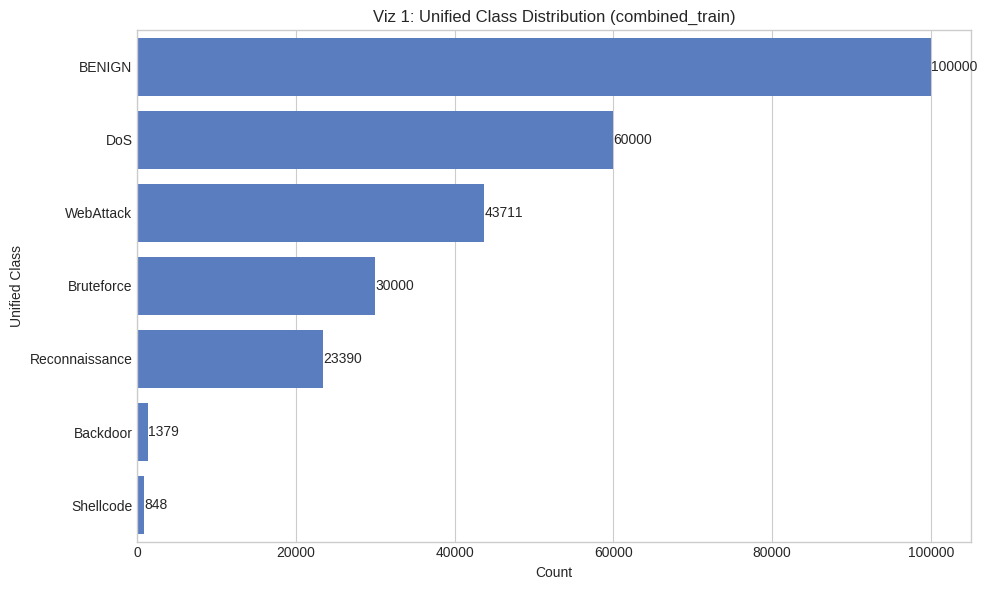

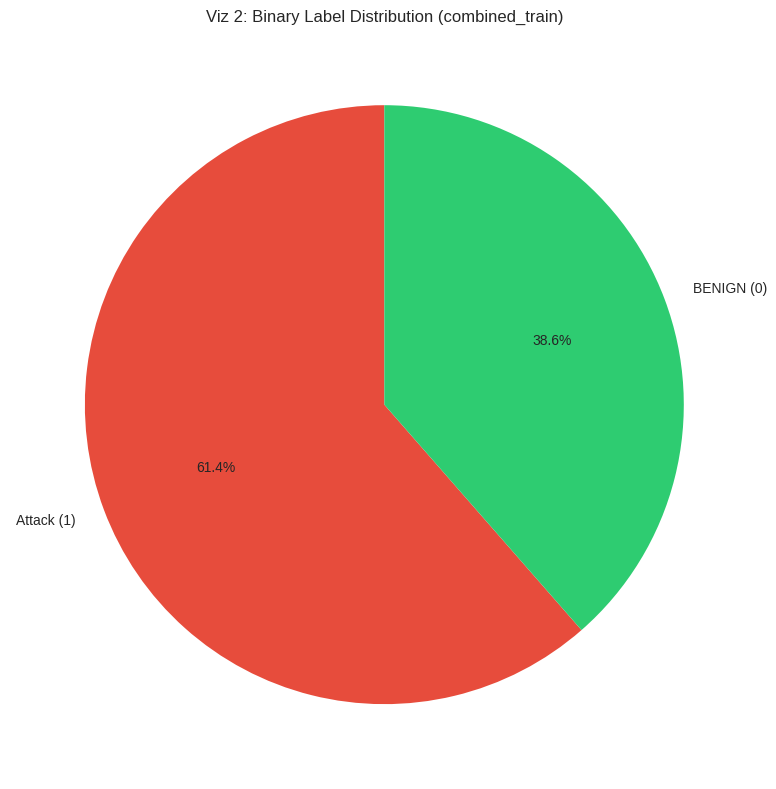

<Figure size 1200x600 with 0 Axes>

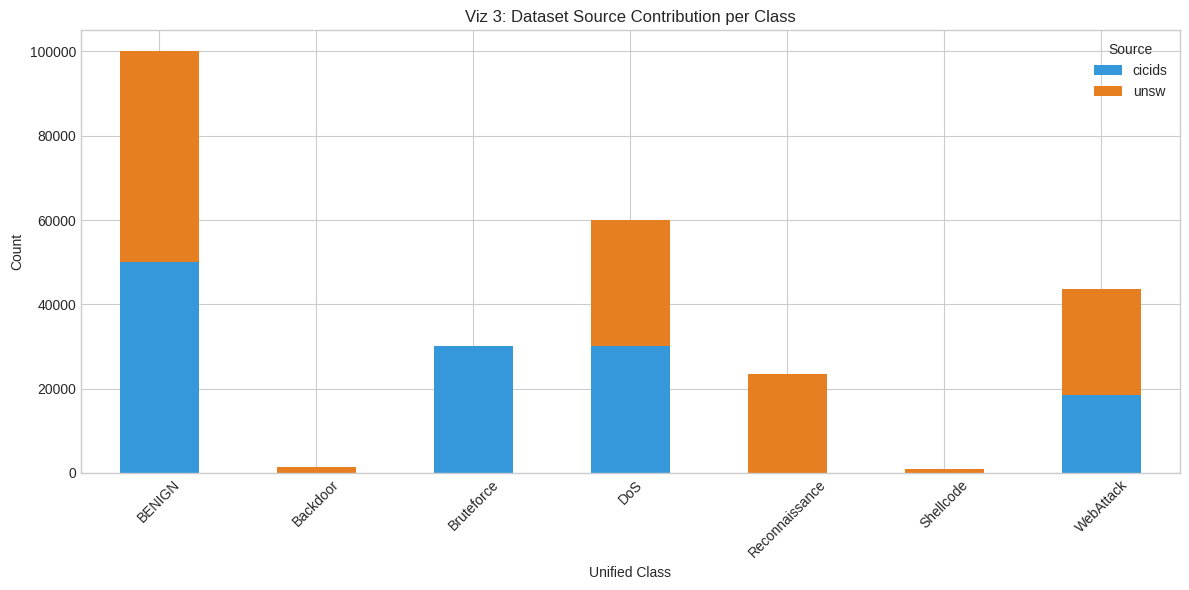

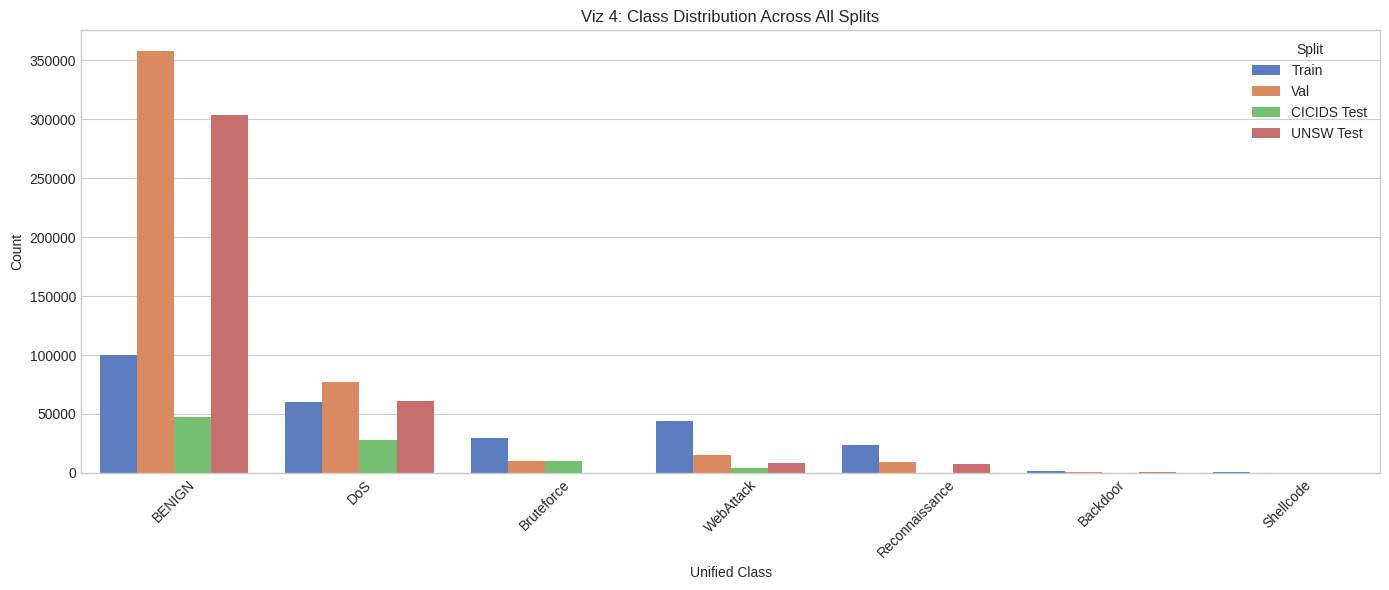

<Figure size 1200x600 with 0 Axes>

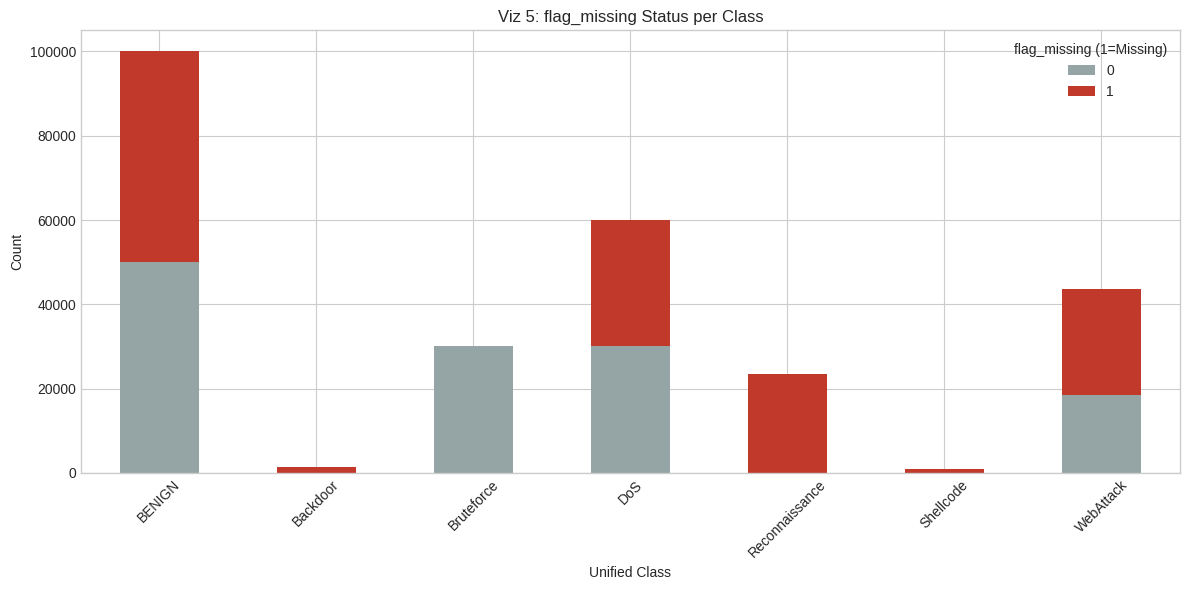

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("========== GROUP 1: DATA DISTRIBUTION ==========")

# Global plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# 1. Class distribution bar chart (combined_train)
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(data=combined_train, y='attack_unified', order=combined_train['attack_unified'].value_counts().index)
ax1.bar_label(ax1.containers[0])
plt.title('Viz 1: Unified Class Distribution (combined_train)')
plt.xlabel('Count')
plt.ylabel('Unified Class')
plt.tight_layout()
plt.savefig('viz_01_class_dist.png')
plt.show()

# 2. Binary label pie chart
plt.figure(figsize=(8, 8))
label_counts = combined_train['label'].value_counts()
plt.pie(label_counts, labels=['Attack (1)', 'BENIGN (0)'], autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#2ecc71'])
plt.title('Viz 2: Binary Label Distribution (combined_train)')
plt.tight_layout()
plt.savefig('viz_02_binary_pie.png')
plt.show()

# 3. Dataset source distribution (stacked bar)
plt.figure(figsize=(12, 6))
source_dist = pd.crosstab(combined_train['attack_unified'], combined_train['dataset_source'])
source_dist.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#3498db', '#e67e22'])
plt.title('Viz 3: Dataset Source Contribution per Class')
plt.xlabel('Unified Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.savefig('viz_03_source_stacked.png')
plt.show()

# 4. Class distribution comparison across splits
# Build a temporary combined dataframe for this specific visualization
all_splits = pd.concat([
    combined_train[['attack_unified']].assign(Split='Train'),
    combined_val[['attack_unified']].assign(Split='Val'),
    cicids_test[['attack_unified']].assign(Split='CICIDS Test'),
    unsw_test[['attack_unified']].assign(Split='UNSW Test')
])
plt.figure(figsize=(14, 6))
sns.countplot(data=all_splits, x='attack_unified', hue='Split')
plt.title('Viz 4: Class Distribution Across All Splits')
plt.xlabel('Unified Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Split')
plt.tight_layout()
plt.savefig('viz_04_split_comparison.png')
plt.show()

# 5. flag_missing distribution per class
plt.figure(figsize=(12, 6))
flag_dist = pd.crosstab(combined_train['attack_unified'], combined_train['flag_missing'])
flag_dist.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#95a5a6', '#c0392b'])
plt.title('Viz 5: flag_missing Status per Class')
plt.xlabel('Unified Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='flag_missing (1=Missing)')
plt.tight_layout()
plt.savefig('viz_05_flag_missing_stacked.png')
plt.show()

In [26]:
# Force features to numeric, coercing non-convertible strings to NaN (then 0)
for col in features:
    combined_train[col] = pd.to_numeric(combined_train[col], errors='coerce').fillna(0)

print("All features forced to numeric. You can now re-run the visualization cells.")

All features forced to numeric. You can now re-run the visualization cells.


========== GROUP 2: FEATURE DISTRIBUTIONS ==========


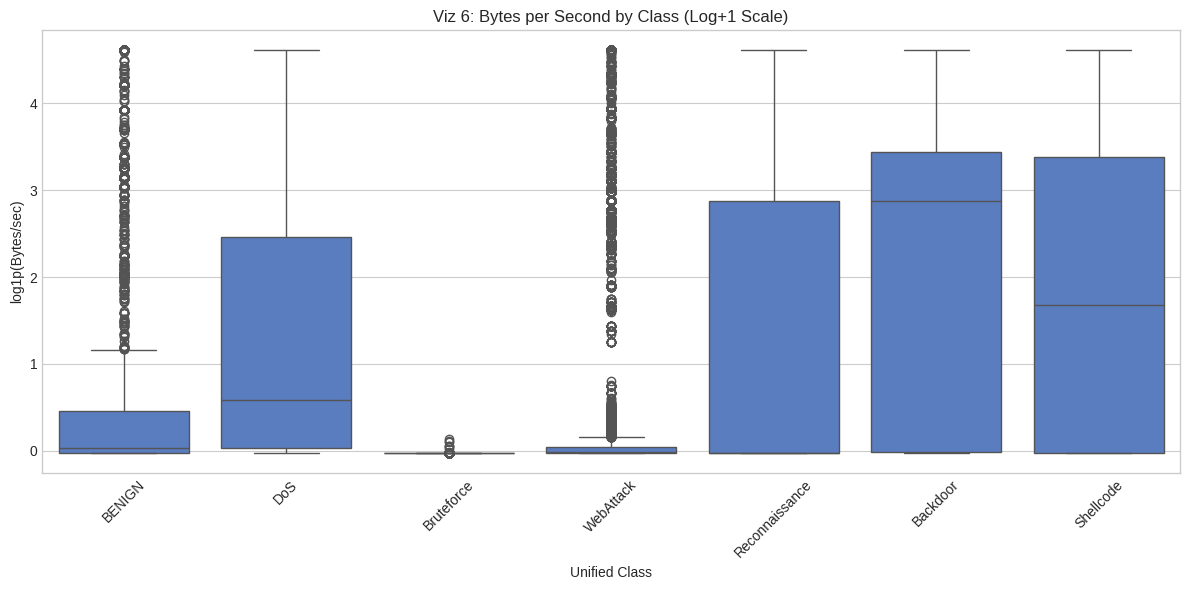

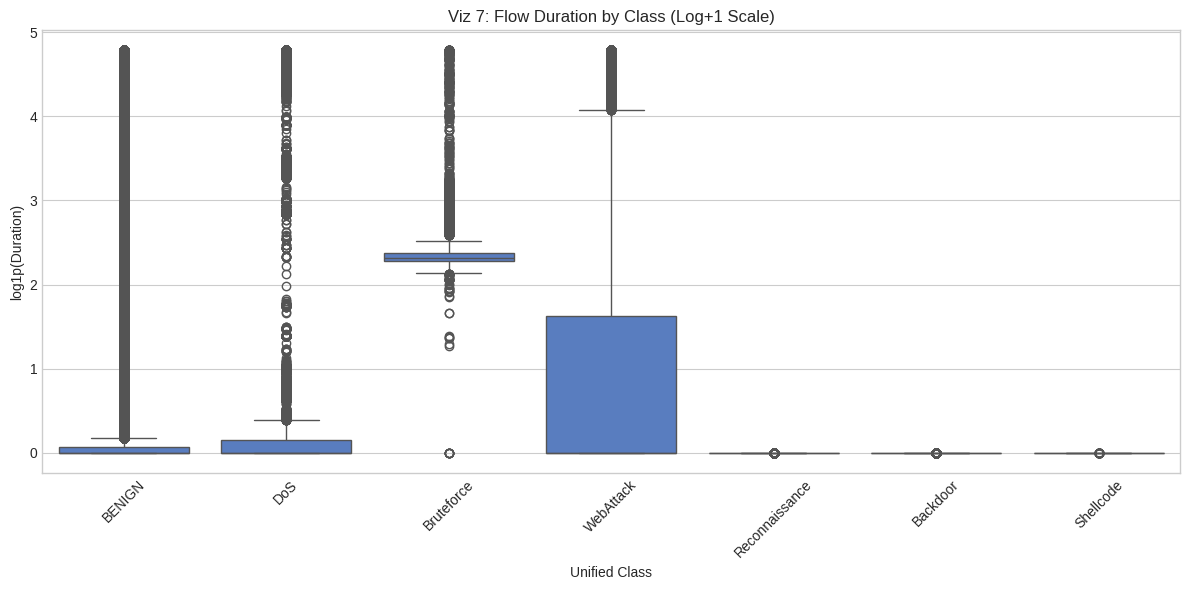

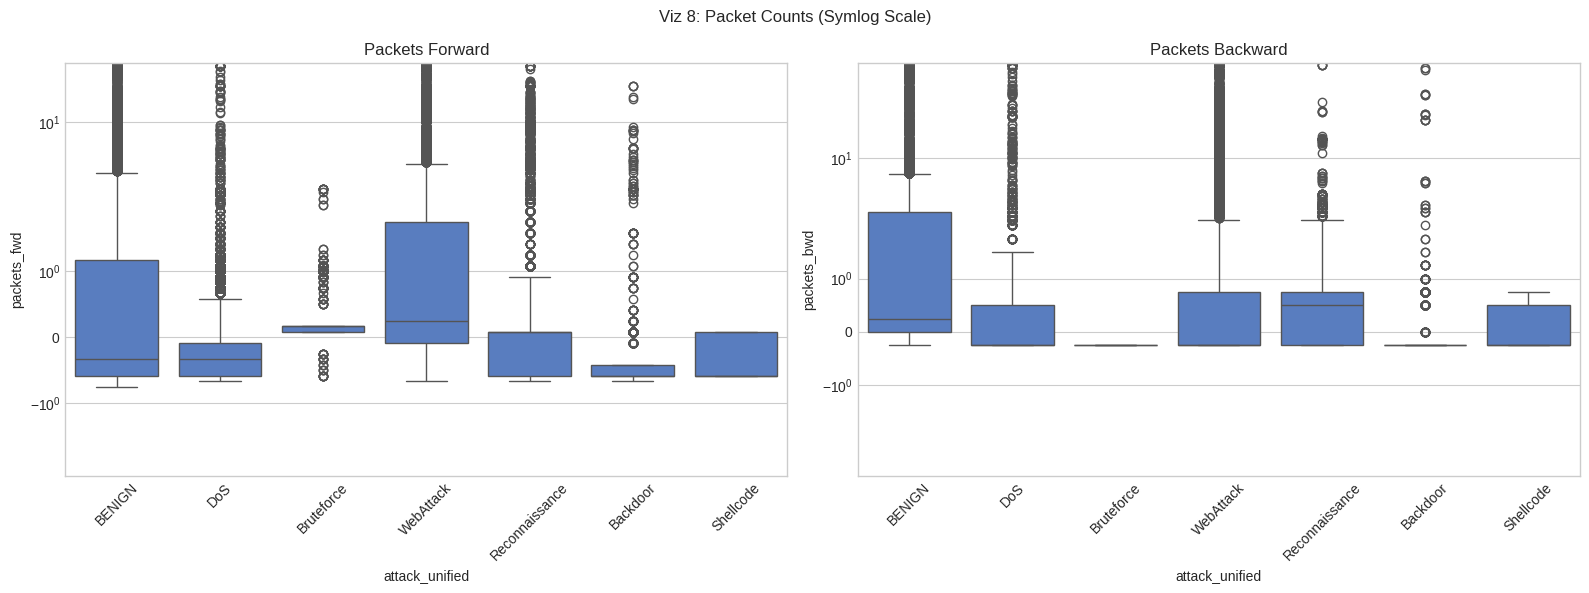

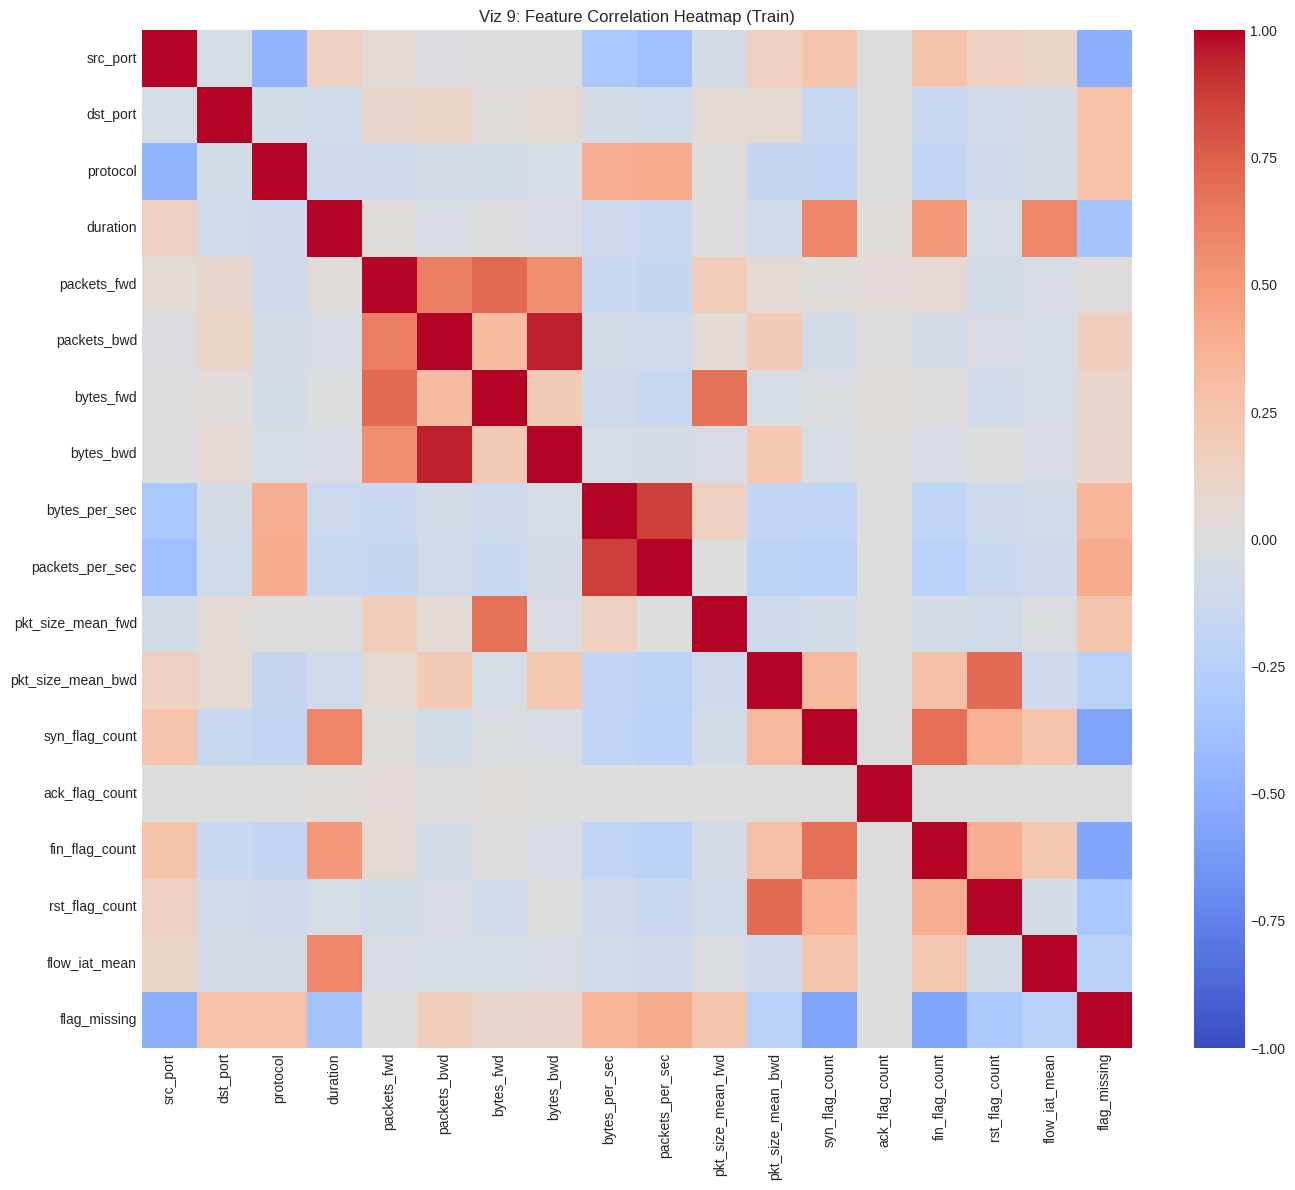

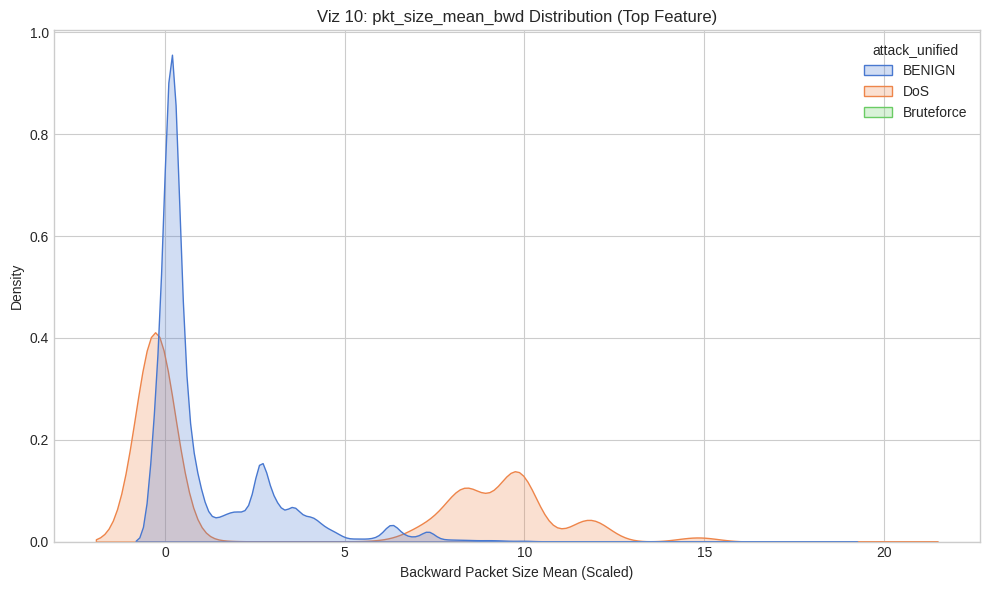

In [27]:
print("========== GROUP 2: FEATURE DISTRIBUTIONS ==========")

# Prepare log scale columns safely
combined_train['log_bytes_per_sec'] = np.log1p(combined_train['bytes_per_sec'])
combined_train['log_duration'] = np.log1p(combined_train['duration'])

# 6. Box plots - bytes_per_sec (log scale)
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_train, x='attack_unified', y='log_bytes_per_sec')
plt.title('Viz 6: Bytes per Second by Class (Log+1 Scale)')
plt.xlabel('Unified Class')
plt.ylabel('log1p(Bytes/sec)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_06_bytes_per_sec_box.png')
plt.show()

# 7. Box plots - duration (log scale)
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_train, x='attack_unified', y='log_duration')
plt.title('Viz 7: Flow Duration by Class (Log+1 Scale)')
plt.xlabel('Unified Class')
plt.ylabel('log1p(Duration)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_07_duration_box.png')
plt.show()

# 8. Box plots - packets_fwd vs packets_bwd
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=combined_train, x='attack_unified', y='packets_fwd', ax=axes[0])
axes[0].set_title('Packets Forward')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('symlog')

sns.boxplot(data=combined_train, x='attack_unified', y='packets_bwd', ax=axes[1])
axes[1].set_title('Packets Backward')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_yscale('symlog')

plt.suptitle('Viz 8: Packet Counts (Symlog Scale)')
plt.tight_layout()
plt.savefig('viz_08_packets_fwd_bwd.png')
plt.show()

# 9. Correlation heatmap
plt.figure(figsize=(14, 12))
corr = combined_train[features].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Viz 9: Feature Correlation Heatmap (Train)')
plt.tight_layout()
plt.savefig('viz_09_corr_heatmap.png')
plt.show()

# 10. Feature overlap KDE - pkt_size_mean_bwd
plt.figure(figsize=(10, 6))
subset = combined_train[combined_train['attack_unified'].isin(['BENIGN', 'DoS', 'Bruteforce'])]
sns.kdeplot(data=subset, x='pkt_size_mean_bwd', hue='attack_unified', common_norm=False, fill=True)
plt.title('Viz 10: pkt_size_mean_bwd Distribution (Top Feature)')
plt.xlabel('Backward Packet Size Mean (Scaled)')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('viz_10_pkt_size_kde.png')
plt.show()

# Cleanup temp columns
combined_train.drop(columns=['log_bytes_per_sec', 'log_duration'], inplace=True)

========== GROUP 3: PROTOCOL & PORT ANALYSIS ==========


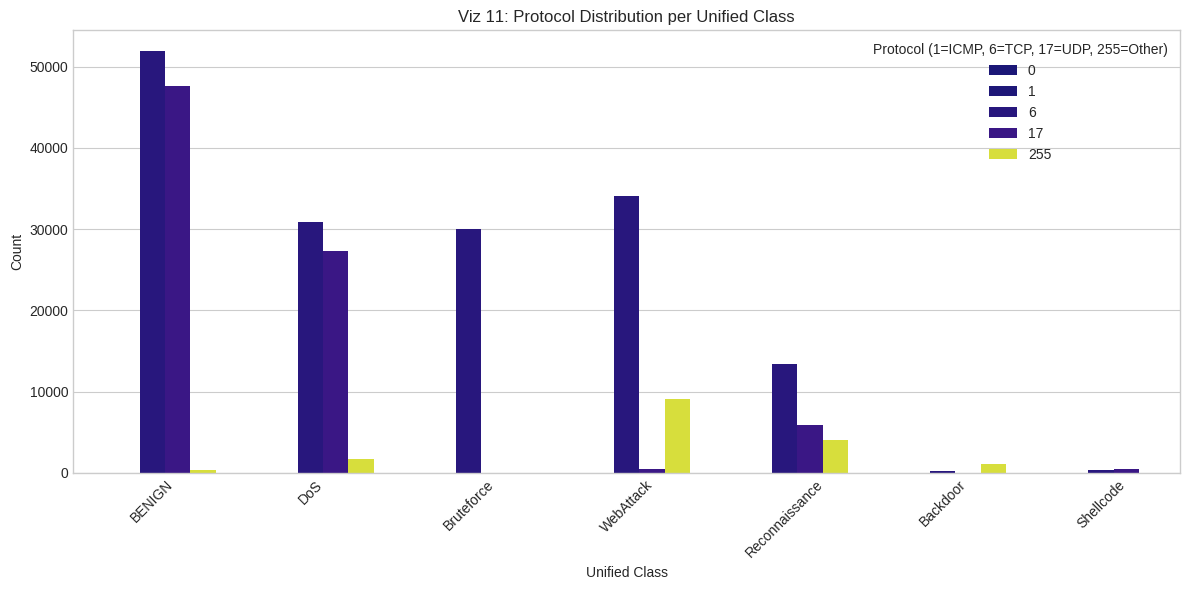

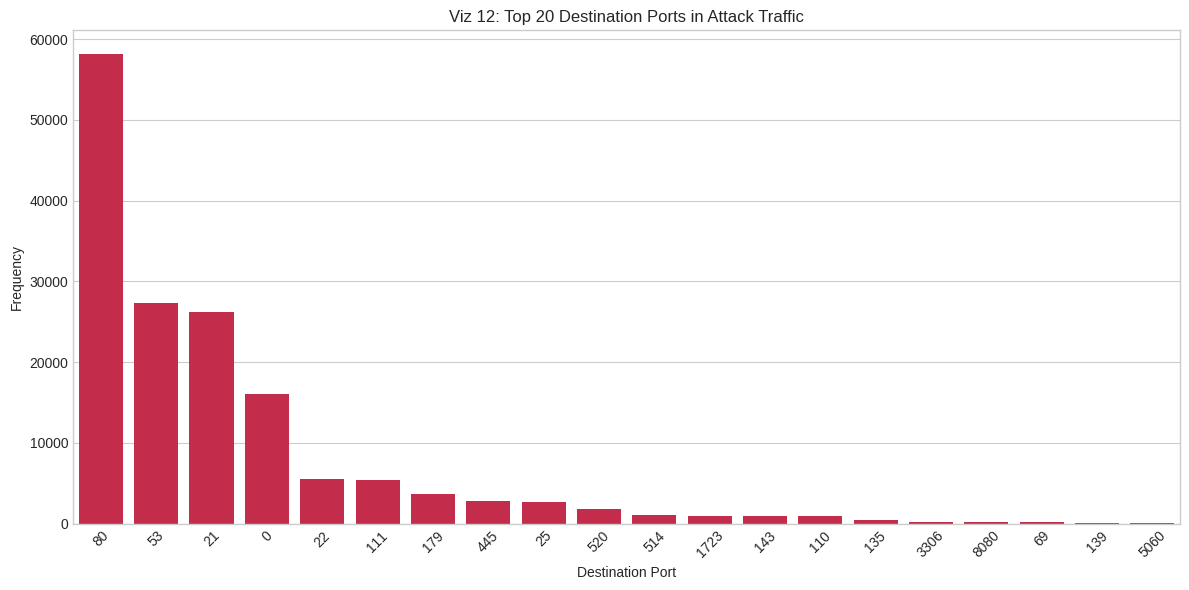

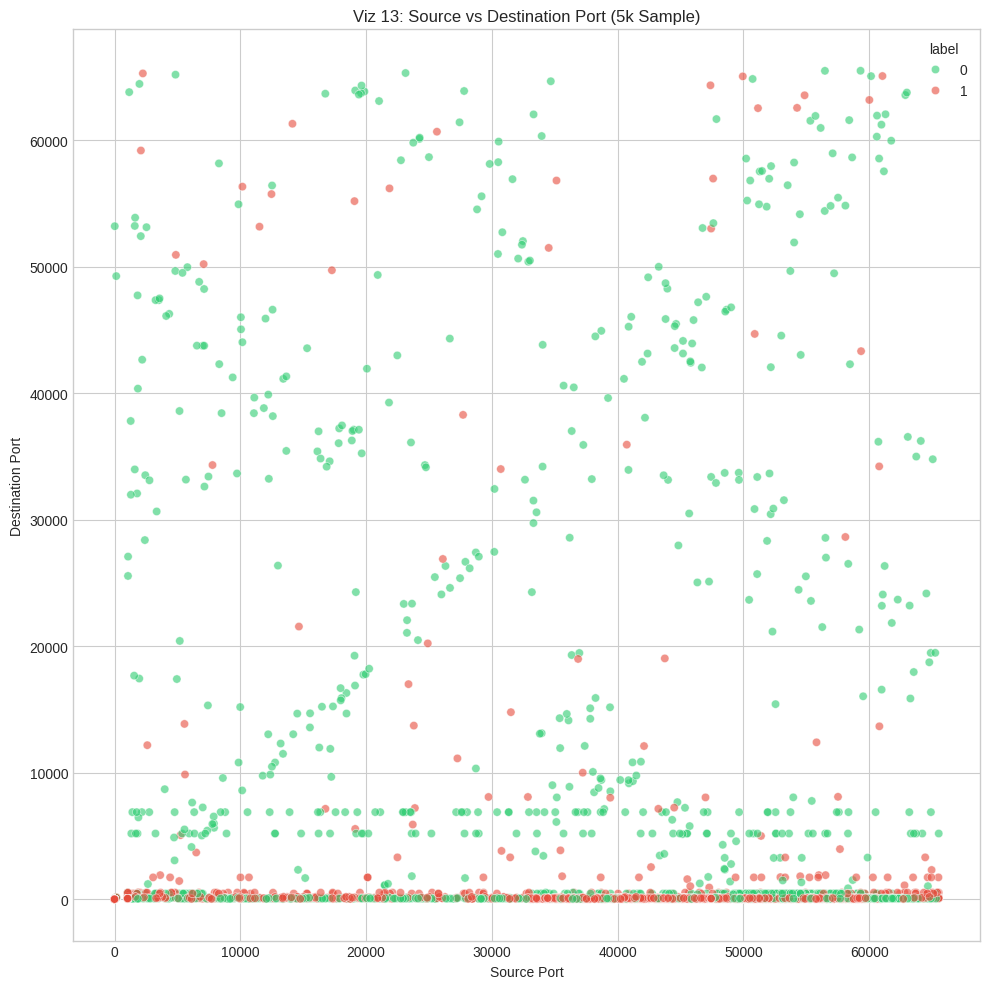

In [28]:
print("========== GROUP 3: PROTOCOL & PORT ANALYSIS ==========")

# 11. Protocol distribution per class
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_train, x='attack_unified', hue='protocol', palette='plasma')
plt.title('Viz 11: Protocol Distribution per Unified Class')
plt.xlabel('Unified Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Protocol (1=ICMP, 6=TCP, 17=UDP, 255=Other)')
plt.tight_layout()
plt.savefig('viz_11_protocol_grouped.png')
plt.show()

# 12. Top 20 destination ports (attacks only)
plt.figure(figsize=(12, 6))
attack_ports = combined_train[combined_train['label'] == 1]['dst_port'].value_counts().head(20)
sns.barplot(x=attack_ports.index.astype(str), y=attack_ports.values, color='crimson')
plt.title('Viz 12: Top 20 Destination Ports in Attack Traffic')
plt.xlabel('Destination Port')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_12_top_dst_ports.png')
plt.show()

# 13. src_port vs dst_port scatter
plt.figure(figsize=(10, 10))
sample_df = combined_train.sample(n=5000, random_state=42)
sns.scatterplot(data=sample_df, x='src_port', y='dst_port', hue='label', palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
plt.title('Viz 13: Source vs Destination Port (5k Sample)')
plt.xlabel('Source Port')
plt.ylabel('Destination Port')
plt.tight_layout()
plt.savefig('viz_13_port_scatter.png')
plt.show()

========== GROUP 4: TRAINING BEHAVIOR ==========


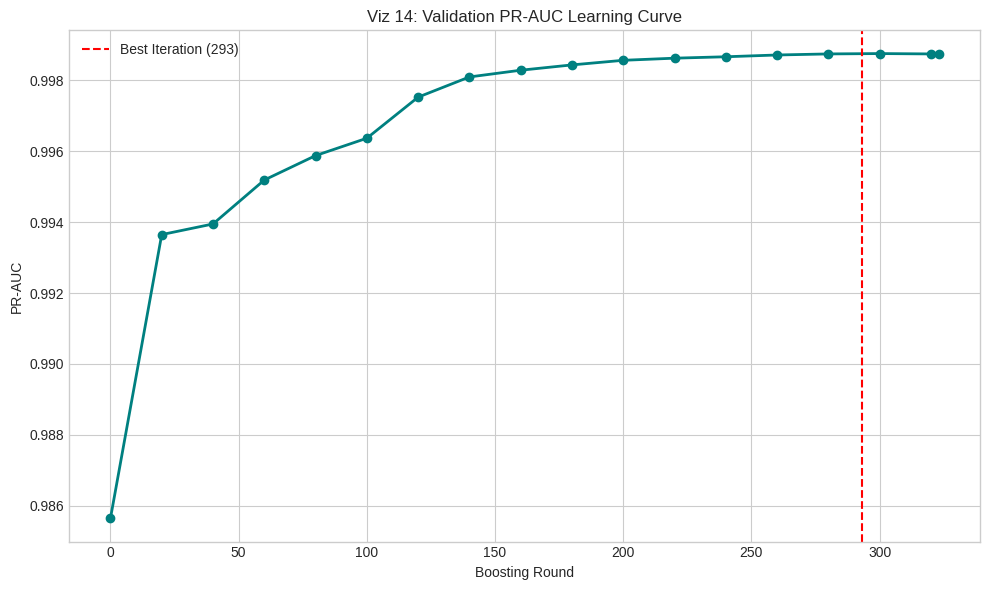

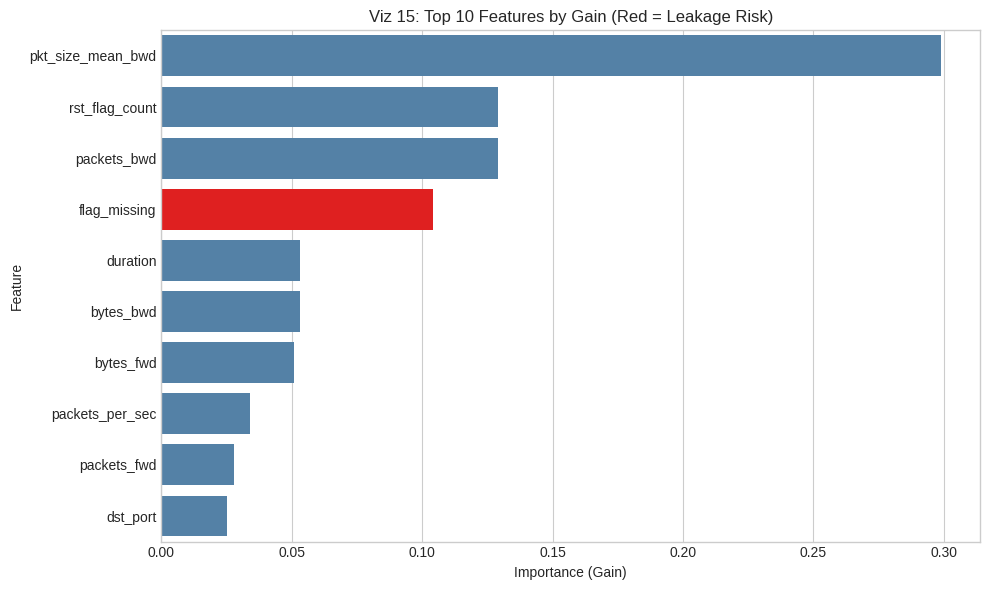

In [29]:
print("========== GROUP 4: TRAINING BEHAVIOR ==========")

# 14. XGBoost PR-AUC learning curve
iters = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 323]
aucpr_vals = [0.98564, 0.99365, 0.99395, 0.99519, 0.99588, 0.99637, 0.99753, 0.99810, 
              0.99829, 0.99844, 0.99857, 0.99863, 0.99867, 0.99872, 0.99875, 0.99876, 0.99875, 0.99875]

plt.figure(figsize=(10, 6))
plt.plot(iters, aucpr_vals, marker='o', linestyle='-', color='teal', linewidth=2)
plt.axvline(x=293, color='r', linestyle='--', label='Best Iteration (293)')
plt.title('Viz 14: Validation PR-AUC Learning Curve')
plt.xlabel('Boosting Round')
plt.ylabel('PR-AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('viz_14_learning_curve.png')
plt.show()

# 15. Feature importance
feat_names = ['pkt_size_mean_bwd', 'rst_flag_count', 'packets_bwd', 'flag_missing', 'duration', 
              'bytes_bwd', 'bytes_fwd', 'packets_per_sec', 'packets_fwd', 'dst_port']
feat_imps = [0.299, 0.129, 0.129, 0.104, 0.053, 0.053, 0.051, 0.034, 0.028, 0.025]

plt.figure(figsize=(10, 6))
colors = ['red' if feat == 'flag_missing' else 'steelblue' for feat in feat_names]
sns.barplot(x=feat_imps, y=feat_names, palette=colors)
plt.title('Viz 15: Top 10 Features by Gain (Red = Leakage Risk)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('viz_15_feature_importance.png')
plt.show()

========== GROUP 5: POST-TRAINING EVALUATION ==========


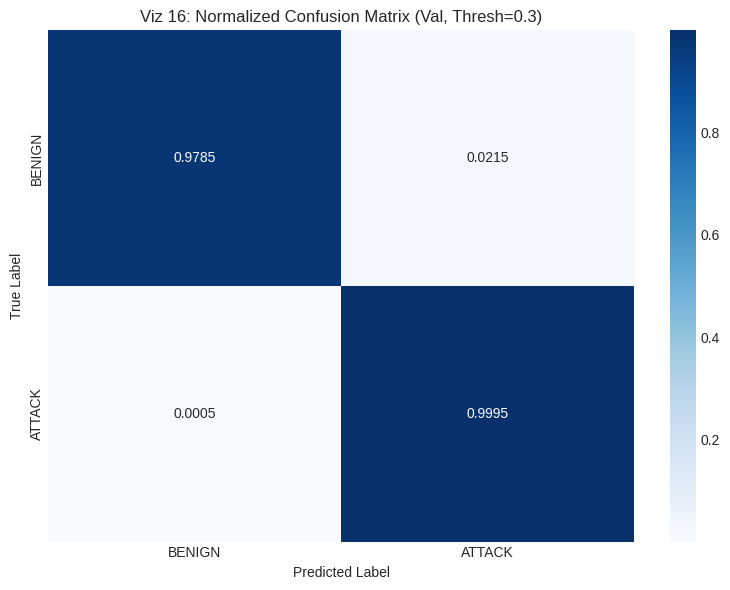

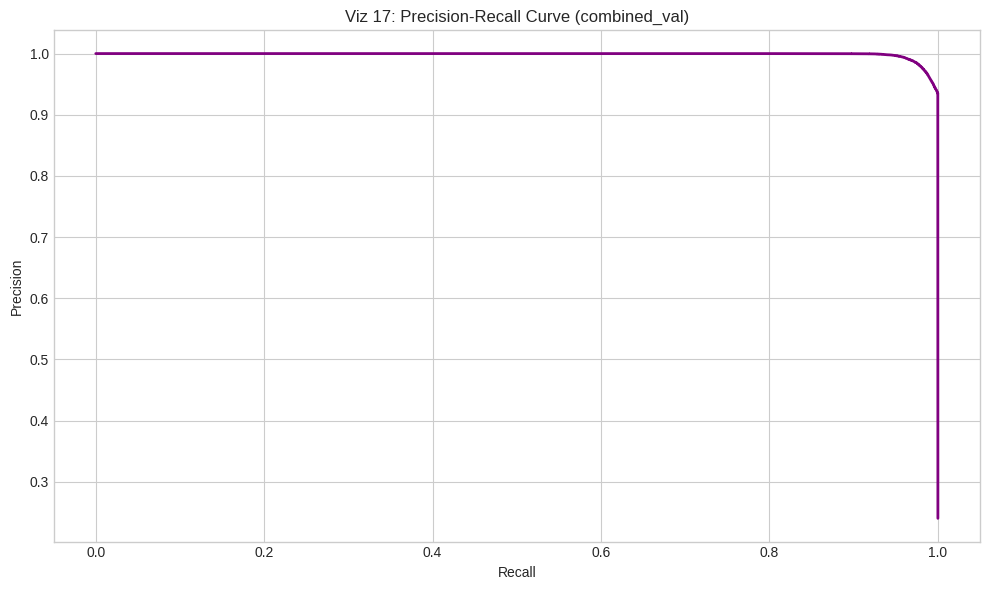

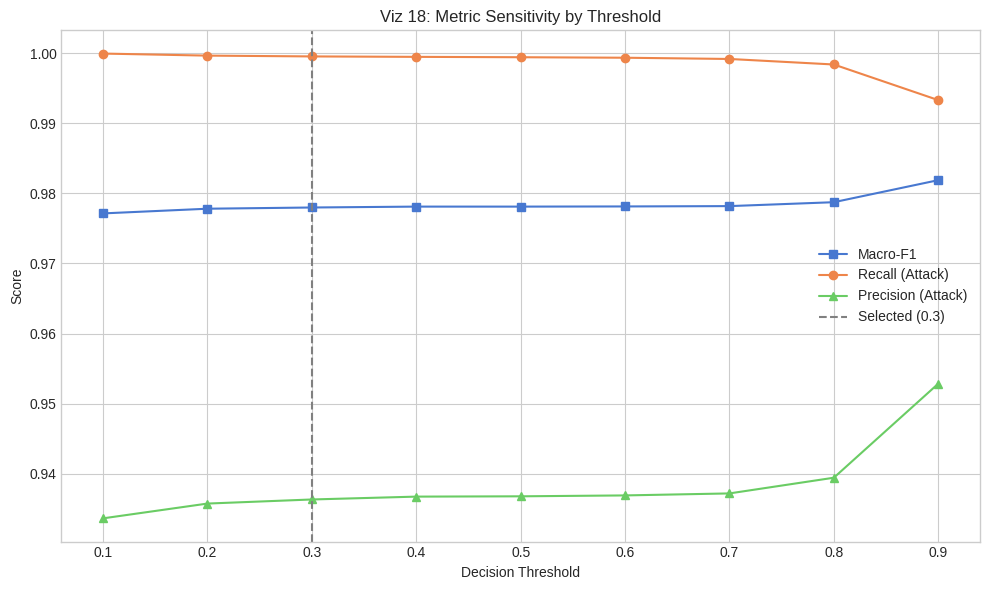

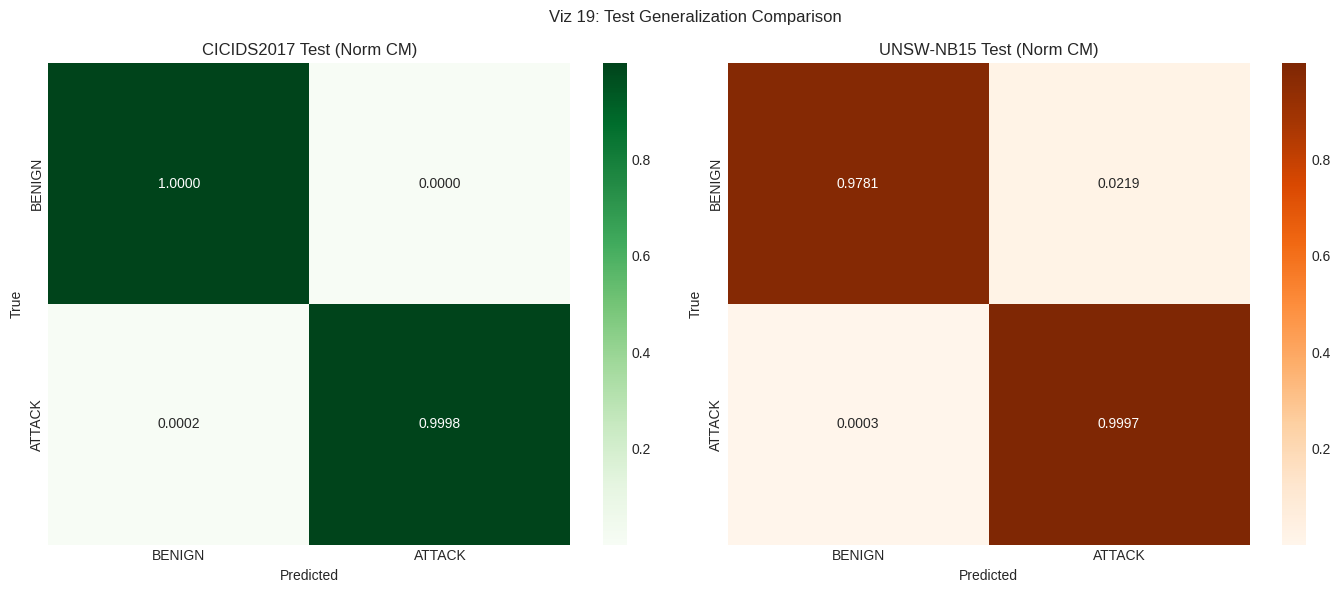

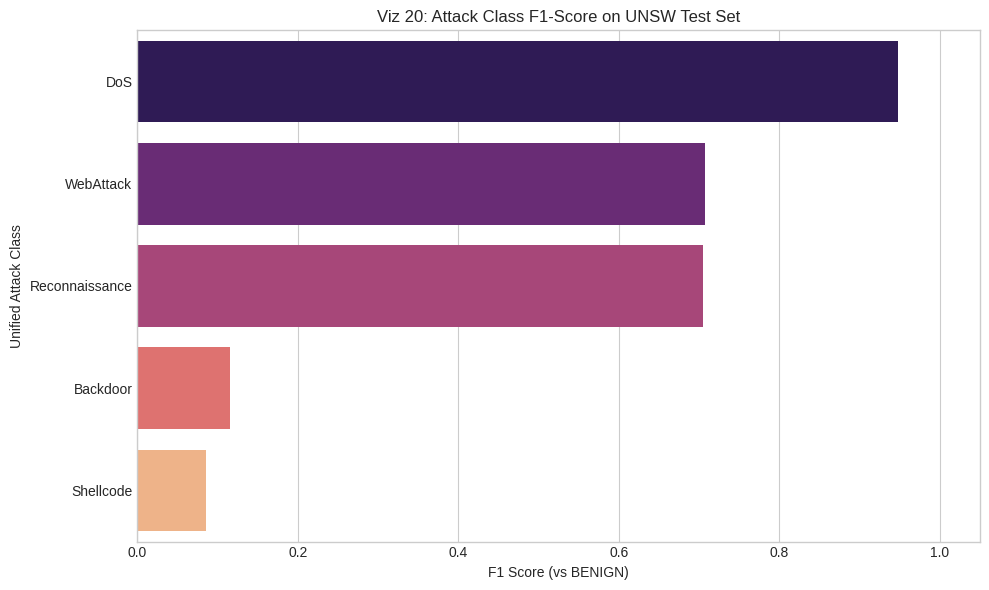

In [30]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score
import xgboost as xgb

print("========== GROUP 5: POST-TRAINING EVALUATION ==========")

# Load model (assuming it's loaded as xgb_model, but we ensure probabilities are ready)
val_probs = xgb_model.predict_proba(X_val)[:, 1]
val_preds_03 = (val_probs >= 0.3).astype(int)

# 16. Confusion matrix heatmap (combined_val, threshold 0.3, normalized)
plt.figure(figsize=(8, 6))
cm_val = confusion_matrix(y_val, val_preds_03, normalize='true')
sns.heatmap(cm_val, annot=True, fmt=".4f", cmap='Blues', xticklabels=['BENIGN', 'ATTACK'], yticklabels=['BENIGN', 'ATTACK'])
plt.title('Viz 16: Normalized Confusion Matrix (Val, Thresh=0.3)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('viz_16_val_cm_norm.png')
plt.show()

# 17. Precision-Recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, val_probs)
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, color='purple', lw=2)
plt.title('Viz 17: Precision-Recall Curve (combined_val)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.tight_layout()
plt.savefig('viz_17_pr_curve.png')
plt.show()

# 18. Threshold sensitivity plot
thresholds = np.arange(0.1, 1.0, 0.1)
f1_scores = [f1_score(y_val, (val_probs >= t).astype(int), average='macro') for t in thresholds]
rec_scores = [recall_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
prec_scores = [precision_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, marker='s', label='Macro-F1')
plt.plot(thresholds, rec_scores, marker='o', label='Recall (Attack)')
plt.plot(thresholds, prec_scores, marker='^', label='Precision (Attack)')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Selected (0.3)')
plt.title('Viz 18: Metric Sensitivity by Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('viz_18_threshold_sensitivity.png')
plt.show()

# 19. Confusion matrix comparison (cicids_test vs unsw_test)
cic_probs = xgb_model.predict_proba(X_test_cic)[:, 1]
unsw_probs = xgb_model.predict_proba(X_test_unsw)[:, 1]

cm_cic = confusion_matrix(y_test_cic, (cic_probs >= 0.3).astype(int), normalize='true')
cm_unsw = confusion_matrix(y_test_unsw, (unsw_probs >= 0.3).astype(int), normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm_cic, annot=True, fmt=".4f", cmap='Greens', ax=axes[0], xticklabels=['BENIGN', 'ATTACK'], yticklabels=['BENIGN', 'ATTACK'])
axes[0].set_title('CICIDS2017 Test (Norm CM)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_unsw, annot=True, fmt=".4f", cmap='Oranges', ax=axes[1], xticklabels=['BENIGN', 'ATTACK'], yticklabels=['BENIGN', 'ATTACK'])
axes[1].set_title('UNSW-NB15 Test (Norm CM)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Viz 19: Test Generalization Comparison')
plt.tight_layout()
plt.savefig('viz_19_cm_test_comparison.png')
plt.show()

# 20. Per-class F1 bar chart (unsw_test)
# Compute F1 for each attack class against BENIGN
unsw_preds = (unsw_probs >= 0.3).astype(int)
f1_per_class = {}
unsw_test['pred'] = unsw_preds

classes = unsw_test['attack_unified'].unique()
for c in classes:
    if c == 'BENIGN': continue
    
    # Isolate subset: True BENIGN + True instances of current class
    subset_mask = unsw_test['attack_unified'].isin(['BENIGN', c])
    y_true_sub = unsw_test.loc[subset_mask, 'label']
    y_pred_sub = unsw_test.loc[subset_mask, 'pred']
    
    # Calculate F1 score for the positive (attack) class within this subset
    if sum(y_true_sub) > 0:
        f1_per_class[c] = f1_score(y_true_sub, y_pred_sub)

plt.figure(figsize=(10, 6))
f1_df = pd.Series(f1_per_class).sort_values(ascending=False)
sns.barplot(x=f1_df.values, y=f1_df.index, palette='magma')
plt.title('Viz 20: Attack Class F1-Score on UNSW Test Set')
plt.xlabel('F1 Score (vs BENIGN)')
plt.ylabel('Unified Attack Class')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig('viz_20_perclass_f1.png')
plt.show()

# Cleanup
unsw_test.drop(columns=['pred'], inplace=True)

In [31]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import pandas as pd

print("========== RETRAINING MODEL (NO LEAKAGE) ==========")

# 1. Update Feature List (Drop flag_missing)
drop_cols = ['label', 'attack_cat', 'attack_unified', 'dataset_source', 'split_set', 'flag_missing']
features_no_leak = [col for col in combined_train.columns if col not in drop_cols]

print(f"Old Feature Count: {len(features)}")
print(f"New Feature Count: {len(features_no_leak)}")
print(f"Feature List: {features_no_leak}")

# 2. Rebuild X matrices
X_train_clean = combined_train[features_no_leak]
X_val_clean = combined_val[features_no_leak]
X_test_cic_clean = cicids_test[features_no_leak]
X_test_unsw_clean = unsw_test[features_no_leak]

# y remains the same (y_train, y_val, y_test_cic, y_test_unsw)

# 3. Train New XGBoost Model
print("\nTraining new model without 'flag_missing'...")
xgb_model_clean = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_val, # Reuse calculated weight
    tree_method='hist',
    device='cuda', 
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42
)

xgb_model_clean.fit(
    X_train_clean, y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=50
)

print(f"\n✅ Training Complete. Best Iteration: {xgb_model_clean.best_iteration}")

========== RETRAINING MODEL (NO LEAKAGE) ==========
Old Feature Count: 18
New Feature Count: 17
Feature List: ['src_port', 'dst_port', 'protocol', 'duration', 'packets_fwd', 'packets_bwd', 'bytes_fwd', 'bytes_bwd', 'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 'pkt_size_mean_bwd', 'syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count', 'flow_iat_mean']

Training new model without 'flag_missing'...
[0]	validation_0-aucpr:0.99513
[50]	validation_0-aucpr:0.99720
[100]	validation_0-aucpr:0.99779
[150]	validation_0-aucpr:0.99819
[200]	validation_0-aucpr:0.99843
[250]	validation_0-aucpr:0.99864
[300]	validation_0-aucpr:0.99873
[350]	validation_0-aucpr:0.99876
[400]	validation_0-aucpr:0.99877
[420]	validation_0-aucpr:0.99877

✅ Training Complete. Best Iteration: 390


In [32]:
print("========== EVALUATION: LEAK-FREE MODEL ==========")

THRESHOLD = 0.3

# Predict probabilities
val_probs_clean = xgb_model_clean.predict_proba(X_val_clean)[:, 1]
cic_probs_clean = xgb_model_clean.predict_proba(X_test_cic_clean)[:, 1]
unsw_probs_clean = xgb_model_clean.predict_proba(X_test_unsw_clean)[:, 1]

# Predictions at threshold 0.3
val_preds_clean = (val_probs_clean >= THRESHOLD).astype(int)
cic_preds_clean = (cic_probs_clean >= THRESHOLD).astype(int)
unsw_preds_clean = (unsw_probs_clean >= THRESHOLD).astype(int)

# Calculate Metrics
val_f1_clean = f1_score(y_val, val_preds_clean, average='macro')
cic_f1_clean = f1_score(y_test_cic, cic_preds_clean, average='macro')
unsw_f1_clean = f1_score(y_test_unsw, unsw_preds_clean, average='macro')

cic_recall_clean = recall_score(y_test_cic, cic_preds_clean)
unsw_recall_clean = recall_score(y_test_unsw, unsw_preds_clean)

print("--- Validation Set ---")
print(f"Macro-F1 (Old): 0.9778  |  Macro-F1 (New): {val_f1_clean:.4f}")

print("\n--- CICIDS2017 Test Set ---")
print(f"Macro-F1 (Old): 0.9999  |  Macro-F1 (New): {cic_f1_clean:.4f}")
print(f"Recall   (Old): 0.9998  |  Recall   (New): {cic_recall_clean:.4f}")

print("\n--- UNSW-NB15 Test Set ---")
print(f"Macro-F1 (Old): 0.9737  |  Macro-F1 (New): {unsw_f1_clean:.4f}")
print(f"Recall   (Old): 0.9997  |  Recall   (New): {unsw_recall_clean:.4f}")

gap_clean = abs(cic_recall_clean - unsw_recall_clean)
print(f"\nNew Generalization Gap (Recall): {gap_clean:.4f}")

# Feature Importance Check
importances_clean = xgb_model_clean.feature_importances_
feature_imp_df_clean = pd.DataFrame({
    'Feature': features_no_leak,
    'Importance': importances_clean
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Features Now:")
print(feature_imp_df_clean.head(5).to_string(index=False))

# Save the honest model
model_filename_clean = 'xgb_binary_stage1_noleak.json'
xgb_model_clean.save_model(model_filename_clean)
print(f"\n✅ Leak-free model saved to {model_filename_clean}")

========== EVALUATION: LEAK-FREE MODEL ==========
--- Validation Set ---
Macro-F1 (Old): 0.9778  |  Macro-F1 (New): 0.9780

--- CICIDS2017 Test Set ---
Macro-F1 (Old): 0.9999  |  Macro-F1 (New): 0.9999
Recall   (Old): 0.9998  |  Recall   (New): 0.9998

--- UNSW-NB15 Test Set ---
Macro-F1 (Old): 0.9737  |  Macro-F1 (New): 0.9739
Recall   (Old): 0.9997  |  Recall   (New): 0.9997

New Generalization Gap (Recall): 0.0000

Top 5 Features Now:
          Feature  Importance
pkt_size_mean_bwd       0.376
   rst_flag_count       0.151
      packets_bwd       0.132
         duration       0.058
        bytes_bwd       0.056

✅ Leak-free model saved to xgb_binary_stage1_noleak.json


In [33]:
import xgboost as xgb
import pandas as pd
import numpy as np

print("========== STEP 1: RUN INFERENCE & INJECT PROBABILITIES ==========")

# 1. Load the leak-free model
model_filename_clean = 'xgb_binary_stage1_noleak.json'
xgb_model_clean = xgb.XGBClassifier()
xgb_model_clean.load_model(model_filename_clean)
print(f"Loaded {model_filename_clean} successfully.")

# 2. Define the exact feature list used for this model (17 features, no flag_missing)
drop_cols = ['label', 'attack_cat', 'attack_unified', 'dataset_source', 'split_set', 'flag_missing', 'xgb_attack_prob']
features_no_leak = [col for col in combined_train.columns if col not in drop_cols]

# 3. Generate probabilities and append as new column
def inject_probabilities(df, name):
    X = df[features_no_leak]
    # predict_proba returns [prob_class_0, prob_class_1]
    probs = xgb_model_clean.predict_proba(X)[:, 1]
    
    # Assign to dataframe
    df['xgb_attack_prob'] = probs
    
    print(f"\n--- {name} xgb_attack_prob stats ---")
    print(f"Min:  {df['xgb_attack_prob'].min():.4f}")
    print(f"Max:  {df['xgb_attack_prob'].max():.4f}")
    print(f"Mean: {df['xgb_attack_prob'].mean():.4f}")
    
    return df

combined_train = inject_probabilities(combined_train, "combined_train")
combined_val = inject_probabilities(combined_val, "combined_val")
cicids_test = inject_probabilities(cicids_test, "cicids_test")
unsw_test = inject_probabilities(unsw_test, "unsw_test")

========== STEP 1: RUN INFERENCE & INJECT PROBABILITIES ==========
Loaded xgb_binary_stage1_noleak.json successfully.

--- combined_train xgb_attack_prob stats ---
Min:  0.0000
Max:  1.0000
Mean: 0.6132

--- combined_val xgb_attack_prob stats ---
Min:  0.0000
Max:  1.0000
Mean: 0.2549

--- cicids_test xgb_attack_prob stats ---
Min:  0.0000
Max:  1.0000
Mean: 0.4716

--- unsw_test xgb_attack_prob stats ---
Min:  0.0000
Max:  0.9999
Mean: 0.2199


In [34]:
print("========== STEP 2: SAVE UPDATED PARQUETS ==========")

# Overwrite existing scaled parquets
combined_train.to_parquet('train_scaled.parquet', index=False)
combined_val.to_parquet('val_scaled.parquet', index=False)
cicids_test.to_parquet('cicids_test_scaled.parquet', index=False)
unsw_test.to_parquet('unsw_test_scaled.parquet', index=False)

# Verification prints
print("\nParquets updated and saved successfully.")
print(f"combined_train shape: {combined_train.shape} | Contains 'xgb_attack_prob': {'xgb_attack_prob' in combined_train.columns}")
print(f"combined_val shape:   {combined_val.shape} | Contains 'xgb_attack_prob': {'xgb_attack_prob' in combined_val.columns}")
print(f"cicids_test shape:    {cicids_test.shape} | Contains 'xgb_attack_prob': {'xgb_attack_prob' in cicids_test.columns}")
print(f"unsw_test shape:      {unsw_test.shape} | Contains 'xgb_attack_prob': {'xgb_attack_prob' in unsw_test.columns}")


print("\n========== STEP 3: DISTRIBUTION CHECK BY UNIFIED CLASS ==========")

# Group by unified class and check the mean confidence score
mean_probs = combined_train.groupby('attack_unified')['xgb_attack_prob'].mean().sort_values(ascending=False)

print("Mean XGBoost Attack Probability per Class (combined_train):")
for attack_class, mean_prob in mean_probs.items():
    print(f"{attack_class.ljust(15)} : {mean_prob:.4f}")
    
print("\nArchitectural Check:")
print("- If DoS is near 1.0, Stage 1 is passing a very strong local signal.")
print("- If Shellcode/Backdoor are low, Stage 1 is failing them, proving the necessity of Stage 2 GNN structural learning.")

========== STEP 2: SAVE UPDATED PARQUETS ==========

Parquets updated and saved successfully.
combined_train shape: (259328, 23) | Contains 'xgb_attack_prob': True
combined_val shape:   (470469, 23) | Contains 'xgb_attack_prob': True
cicids_test shape:    (89465, 23) | Contains 'xgb_attack_prob': True
unsw_test shape:      (381008, 23) | Contains 'xgb_attack_prob': True

========== STEP 3: DISTRIBUTION CHECK BY UNIFIED CLASS ==========
Mean XGBoost Attack Probability per Class (combined_train):
Bruteforce      : 0.9999
DoS             : 0.9994
Backdoor        : 0.9972
WebAttack       : 0.9960
Shellcode       : 0.9901
Reconnaissance  : 0.9746
BENIGN          : 0.0052

Architectural Check:
- If DoS is near 1.0, Stage 1 is passing a very strong local signal.
- If Shellcode/Backdoor are low, Stage 1 is failing them, proving the necessity of Stage 2 GNN structural learning.


In [35]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb

print("========== STEP 1: RECOVERING IPs AS GRAPH NODES ==========")

# 1. Safely extract IPs from the full in-memory datasets before the shuffle occurred
if ' Source IP' in df_cic_full.columns or 'Source IP' in df_cic_full.columns:
    cic_src = ' Source IP' if ' Source IP' in df_cic_full.columns else 'Source IP'
    cic_dst = ' Destination IP' if ' Destination IP' in df_cic_full.columns else 'Destination IP'
    df_cic_clean['src_ip'] = df_cic_full[cic_src].values
    df_cic_clean['dst_ip'] = df_cic_full[cic_dst].values
else:
    print("⚠️ CICIDS IP columns missing in memory. You may need to reload raw files.")

if 'srcip' in df_unsw_full.columns:
    df_unsw_clean['src_ip'] = df_unsw_full['srcip'].values
    df_unsw_clean['dst_ip'] = df_unsw_full['dstip'].values
else:
    print("⚠️ UNSW IP columns missing in memory. You may need to reload raw files.")

# 2. Re-apply the deterministic sampling to guarantee perfect alignment with our trained model
def resample_with_ips(df, dataset_name):
    train_df = df[df['split_set'] == 'train']
    other_df = df[df['split_set'] != 'train']
    
    sampled_pieces = []
    for attack_class, group in train_df.groupby('attack_unified'):
        limit = 50000 if attack_class == 'BENIGN' else 30000
        if len(group) > limit:
            # Using the exact same random_state guarantees the exact same rows are chosen
            sampled_group = group.sample(n=limit, random_state=42).sort_index()
            sampled_pieces.append(sampled_group)
        else:
            sampled_pieces.append(group)
            
    balanced_train_df = pd.concat(sampled_pieces).sort_index()
    return pd.concat([balanced_train_df, other_df]).sort_index()

df_cic_balanced_ip = resample_with_ips(df_cic_clean, "CICIDS2017")
df_unsw_balanced_ip = resample_with_ips(df_unsw_clean, "UNSW-NB15")

# 3. Re-split and merge
cic_train_ip = df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'train'].drop(columns=['attack_cat'])
unsw_train_ip = df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'train'].drop(columns=['attack_cat'])

combined_train_ip = pd.concat([cic_train_ip, unsw_train_ip], ignore_index=True)
# Exactly reproduce the shuffle
combined_train_ip = combined_train_ip.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ IPs successfully recovered and perfectly aligned with shuffled training set.")

# Assign back to your working variables
combined_train['src_ip'] = combined_train_ip['src_ip'].astype(str)
combined_train['dst_ip'] = combined_train_ip['dst_ip'].astype(str)

print("\nSample check of combined_train (Features + Probabilities + IPs):")
print(combined_train[['src_ip', 'dst_ip', 'attack_unified', 'xgb_attack_prob']].head(5))

========== STEP 1: RECOVERING IPs AS GRAPH NODES ==========
⚠️ CICIDS IP columns missing in memory. You may need to reload raw files.
✅ IPs successfully recovered and perfectly aligned with shuffled training set.

Sample check of combined_train (Features + Probabilities + IPs):
       src_ip         dst_ip attack_unified  xgb_attack_prob
0  59.166.0.1  149.171.126.8         BENIGN            0.000
1         nan            nan         BENIGN            0.000
2         nan            nan            DoS            1.000
3  59.166.0.2  149.171.126.8         BENIGN            0.001
4  59.166.0.0  149.171.126.7         BENIGN            0.001


In [36]:
print("========== STEP 2: VERIFY IP COVERAGE (GRAPH TOPOLOGY) ==========")

# Combine all IPs to find unique nodes
src_ips = set(combined_train['src_ip'].unique())
dst_ips = set(combined_train['dst_ip'].unique())
all_unique_ips = src_ips.union(dst_ips)

total_nodes = len(all_unique_ips)
total_edges = len(combined_train)

print(f"Total Unique Nodes (IPs): {total_nodes}")
print(f"Total Edges (Flows):      {total_edges}")

# Calculate average node degree (Total connections per IP)
# An edge connects 2 nodes, so total degrees = edges * 2
avg_degree = (total_edges * 2) / total_nodes
print(f"Average Node Degree:      {avg_degree:.2f} flows per IP")

# Calculate role overlap (IPs acting as both client and server)
overlap_ips = src_ips.intersection(dst_ips)
overlap_pct = (len(overlap_ips) / total_nodes) * 100

print(f"IPs in Both Src & Dst Roles: {len(overlap_ips)} ({overlap_pct:.2f}%)")

print("\n--- Structural Conclusion ---")
if overlap_pct < 5.0:
    print("⚠️ Low overlap. Your graph is highly bipartite (strict clients vs strict servers). GNN will rely heavily on localized edge clusters.")
elif overlap_pct >= 5.0:
    print("✅ Healthy overlap. IPs are acting dynamically. GNN message passing will propagate effectively across the network.")

========== STEP 2: VERIFY IP COVERAGE (GRAPH TOPOLOGY) ==========
Total Unique Nodes (IPs): 47
Total Edges (Flows):      259328
Average Node Degree:      11035.23 flows per IP
IPs in Both Src & Dst Roles: 34 (72.34%)

--- Structural Conclusion ---
✅ Healthy overlap. IPs are acting dynamically. GNN message passing will propagate effectively across the network.


In [37]:
import numpy as np
import pandas as pd

print("========== PATCH V2: SAFELY ATTACHING IPs ==========")

# Helper function to safely extract the column or return NaN if missing
def get_ip_col(df, col_name):
    return df[col_name].astype(str).values if col_name in df.columns else np.nan

# 1. combined_val
cic_val_ip = df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'val']
unsw_val_ip = df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'val']
combined_val_ip = pd.concat([cic_val_ip, unsw_val_ip], ignore_index=True)

combined_val['src_ip'] = get_ip_col(combined_val_ip, 'src_ip')
combined_val['dst_ip'] = get_ip_col(combined_val_ip, 'dst_ip')

# 2. Attach IPs to cicids_test
cic_test_ip = df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'test']
cicids_test['src_ip'] = get_ip_col(cic_test_ip, 'src_ip')
cicids_test['dst_ip'] = get_ip_col(cic_test_ip, 'dst_ip')

# 3. Attach IPs to unsw_test
unsw_test_ip = df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'test']
unsw_test['src_ip'] = get_ip_col(unsw_test_ip, 'src_ip')
unsw_test['dst_ip'] = get_ip_col(unsw_test_ip, 'dst_ip')

print(f"✅ combined_val IPs attached: {'src_ip' in combined_val.columns}")
print(f"✅ cicids_test IPs attached:  {'src_ip' in cicids_test.columns}")
print(f"✅ unsw_test IPs attached:    {'src_ip' in unsw_test.columns}")
print("Error bypassed. You may now proceed to run Cell 36!")

========== PATCH V2: SAFELY ATTACHING IPs ==========
✅ combined_val IPs attached: True
✅ cicids_test IPs attached:  True
✅ unsw_test IPs attached:    True
Error bypassed. You may now proceed to run Cell 36!


In [38]:
import numpy as np
import pandas as pd
import json

print("========== STEP 1: FIX NaN IPs ==========")

datasets = [
    ('combined_train', combined_train),
    ('combined_val', combined_val),
    ('cicids_test', cicids_test),
    ('unsw_test', unsw_test)
]

for name, df in datasets:
    # Count before
    src_nan = df['src_ip'].isin(['nan', 'NaN', '']).sum() + df['src_ip'].isna().sum()
    dst_nan = df['dst_ip'].isin(['nan', 'NaN', '']).sum() + df['dst_ip'].isna().sum()
    print(f"[{name}] NaNs before -> src_ip: {src_nan}, dst_ip: {dst_nan}")
    
    # Replace NaNs
    df['src_ip'] = df['src_ip'].replace(['nan', 'NaN', '', np.nan], '0.0.0.0')
    df['dst_ip'] = df['dst_ip'].replace(['nan', 'NaN', '', np.nan], '0.0.0.0_dst')

print("\n========== STEP 2: BUILD IP TO NODE INDEX MAPPING ==========")

all_ips = set()
for _, df in datasets:
    all_ips.update(df['src_ip'].unique())
    all_ips.update(df['dst_ip'].unique())

# Create stable sorted mapping
ip2idx = {ip: idx for idx, ip in enumerate(sorted(list(all_ips)))}

total_nodes = len(ip2idx)
print(f"Total Unique Nodes across all datasets: {total_nodes}")

# Save mapping
with open('ip2idx.json', 'w') as f:
    json.dump(ip2idx, f)
print("✅ Saved ip2idx mapping to ip2idx.json")

# Apply mapping to create edge indices
for _, df in datasets:
    df['src_idx'] = df['src_ip'].map(ip2idx)
    df['dst_idx'] = df['dst_ip'].map(ip2idx)

========== STEP 1: FIX NaN IPs ==========
[combined_train] NaNs before -> src_ip: 128580, dst_ip: 128580
[combined_val] NaNs before -> src_ip: 89462, dst_ip: 89462
[cicids_test] NaNs before -> src_ip: 89465, dst_ip: 89465
[unsw_test] NaNs before -> src_ip: 0, dst_ip: 0

========== STEP 2: BUILD IP TO NODE INDEX MAPPING ==========
Total Unique Nodes across all datasets: 50
✅ Saved ip2idx mapping to ip2idx.json


In [39]:
print("========== STEP 5: ENCODE ATTACK_UNIFIED ==========")

attack_mapping = {
    'BENIGN': 0, 
    'DoS': 1, 
    'Bruteforce': 2, 
    'WebAttack': 3, 
    'Reconnaissance': 4, 
    'Backdoor': 5, 
    'Shellcode': 6
}

for name, df in datasets:
    df['attack_cat_encoded'] = df['attack_unified'].map(attack_mapping)
    print(f"Mapped {name} unique labels: {df['attack_cat_encoded'].unique()}")

# Save mapping
with open('attack_mapping.json', 'w') as f:
    json.dump(attack_mapping, f)
print("✅ Saved attack mapping to attack_mapping.json")

========== STEP 5: ENCODE ATTACK_UNIFIED ==========
Mapped combined_train unique labels: [0 1 2 3 4 5 6]
Mapped combined_val unique labels: [0 1 2 3 4 6 5]
Mapped cicids_test unique labels: [0 1 2 3]
Mapped unsw_test unique labels: [1 0 3 4 6 5]
✅ Saved attack mapping to attack_mapping.json


In [40]:
print("========== STEP 3: COMPUTE STATIC NODE FEATURES ==========")

# Initialize node feature matrix (Nodes x 8)
node_features = np.zeros((total_nodes, 8), dtype=np.float32)

# 1. Group by Source IP to get outgoing stats
src_grp = combined_train.groupby('src_idx').agg(
    mean_bytes_fwd=('bytes_fwd', 'mean'),
    mean_bytes_bwd=('bytes_bwd', 'mean'),
    mean_packets_fwd=('packets_fwd', 'mean'),
    mean_packets_bwd=('packets_bwd', 'mean'),
    out_degree=('src_idx', 'count'),
    mean_xgb_prob=('xgb_attack_prob', 'mean'),
    unique_dst_count=('dst_idx', 'nunique')
)

# 2. Group by Destination IP to get incoming stats
dst_grp = combined_train.groupby('dst_idx').agg(
    in_degree=('dst_idx', 'count'),
    unique_src_count=('src_idx', 'nunique')
)

# 3. Populate matrix
for node_idx in range(total_nodes):
    # Outgoing (src) stats
    if node_idx in src_grp.index:
        node_features[node_idx, 0] = src_grp.loc[node_idx, 'mean_bytes_fwd']
        node_features[node_idx, 1] = src_grp.loc[node_idx, 'mean_bytes_bwd']
        node_features[node_idx, 2] = src_grp.loc[node_idx, 'mean_packets_fwd']
        node_features[node_idx, 3] = src_grp.loc[node_idx, 'mean_packets_bwd']
        node_features[node_idx, 4] = src_grp.loc[node_idx, 'out_degree']
        node_features[node_idx, 5] = src_grp.loc[node_idx, 'mean_xgb_prob']
        node_features[node_idx, 6] = src_grp.loc[node_idx, 'unique_dst_count']
        
    # Incoming (dst) stats
    if node_idx in dst_grp.index:
        node_features[node_idx, 7] = dst_grp.loc[node_idx, 'unique_src_count']
        # Note: in-degree isn't strictly requested in the 8-dim list, 
        # but unique_src_count fills the 8th slot. You can append in_degree if you want 9 dims.

print(f"Node Feature Matrix Shape: {node_features.shape}")
np.save('node_features.npy', node_features)
print("✅ Node features computed and saved to node_features.npy")

========== STEP 3: COMPUTE STATIC NODE FEATURES ==========
Node Feature Matrix Shape: (50, 8)
✅ Node features computed and saved to node_features.npy


In [41]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:0000:01


In [42]:
import torch
from torch_geometric.data import Data

print("========== STEP 4: GENERATE PYG TEMPORAL SNAPSHOTS ==========")

# Define the exact 18 edge features to pass to the GNN
# Excludes flag_missing, includes xgb_attack_prob
edge_feature_cols = [
    'src_port', 'dst_port', 'protocol', 'duration', 'bytes_fwd', 'bytes_bwd', 
    'packets_fwd', 'packets_bwd', 'bytes_per_sec', 'packets_per_sec', 
    'pkt_size_mean_fwd', 'pkt_size_mean_bwd', 'syn_flag_count', 'ack_flag_count', 
    'fin_flag_count', 'rst_flag_count', 'flow_iat_mean', 'xgb_attack_prob'
]

def create_snapshots(df, window_size=500):
    snapshots = []
    num_rows = len(df)
    
    # Pre-convert node features to PyTorch tensor
    x_tensor = torch.tensor(node_features, dtype=torch.float)
    
    for start_idx in range(0, num_rows, window_size):
        end_idx = min(start_idx + window_size, num_rows)
        window_df = df.iloc[start_idx:end_idx]
        
        # Edge Index (2, num_edges)
        edge_index = torch.tensor(
            window_df[['src_idx', 'dst_idx']].values.T, 
            dtype=torch.long
        )
        
        # Edge Attributes (num_edges, 18)
        edge_attr = torch.tensor(
            window_df[edge_feature_cols].values, 
            dtype=torch.float
        )
        
        # Edge Labels (binary for Stage 1, multiclass for Stage 2)
        edge_label = torch.tensor(window_df['label'].values, dtype=torch.float)
        edge_attack_cat = torch.tensor(window_df['attack_cat_encoded'].values, dtype=torch.long)
        
        # Build PyG Data object
        data = Data(
            x=x_tensor, 
            edge_index=edge_index, 
            edge_attr=edge_attr, 
            y=edge_label, 
            y_multi=edge_attack_cat
        )
        snapshots.append(data)
        
    return snapshots

train_snapshots = create_snapshots(combined_train, window_size=500)

print(f"Expected Train Snapshot Count (approx): {len(combined_train) // 500}")
print(f"Actual Train Snapshot Count Generated:  {len(train_snapshots)}")

# Example of what a snapshot looks like
print("\nSample Snapshot (Window 0):")
print(train_snapshots[0])

========== STEP 4: GENERATE PYG TEMPORAL SNAPSHOTS ==========
Expected Train Snapshot Count (approx): 518
Actual Train Snapshot Count Generated:  519

Sample Snapshot (Window 0):
Data(x=[50, 8], edge_index=[2, 500], edge_attr=[500, 18], y=[500], y_multi=[500])


In [43]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import json

master_features = [
    'src_port', 'dst_port', 'protocol', 'duration',
    'packets_fwd', 'packets_bwd', 'bytes_fwd', 'bytes_bwd',
    'bytes_per_sec', 'packets_per_sec',
    'pkt_size_mean_fwd', 'pkt_size_mean_bwd',
    'syn_flag_count', 'ack_flag_count', 'fin_flag_count', 'rst_flag_count',
    'flow_iat_mean'
]

scale_cols = [
    'duration', 'bytes_fwd', 'bytes_bwd', 'packets_fwd', 'packets_bwd',
    'bytes_per_sec', 'packets_per_sec', 'pkt_size_mean_fwd', 'pkt_size_mean_bwd',
    'flow_iat_mean'
]

def encode_protocol(val):
    val_str = str(val).lower().strip()
    protocol_map = {'tcp': 6, 'udp': 17, 'icmp': 1}
    if val_str in protocol_map: return protocol_map[val_str]
    elif val_str.isdigit(): return int(val_str)
    else: return 255

def clean_port(val):
    val = str(val).strip().lower()
    if val in ['-', 'none', '', 'nan']: return -1
    if val.startswith('0x'):
        try: return int(val, 16)
        except: return -1
    try: return int(float(val))
    except: return -1

scaler = joblib.load('robust_scaler.pkl')
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgb_binary_stage1_noleak.json')
with open('ip2idx.json', 'r') as f: ip2idx = json.load(f)
with open('attack_mapping.json', 'r') as f: attack_mapping = json.load(f)

datasets_ord = {
    'cic_train': df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'train'].copy(),
    'unsw_train': df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'train'].copy(),
    'cic_val':   df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'val'].copy(),
    'unsw_val':  df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'val'].copy(),
    'cic_test':  df_cic_balanced_ip[df_cic_balanced_ip['split_set'] == 'test'].copy(),
    'unsw_test': df_unsw_balanced_ip[df_unsw_balanced_ip['split_set'] == 'test'].copy()
}

for name, df in datasets_ord.items():
    print(f"Processing {name}...")

    if 'src_ip' not in df.columns: df['src_ip'] = '0.0.0.0'
    if 'dst_ip' not in df.columns: df['dst_ip'] = '0.0.0.0_dst'

    df['src_ip'] = df['src_ip'].astype(str).replace(['nan', 'NaN', '', 'None'], '0.0.0.0')
    df['dst_ip'] = df['dst_ip'].astype(str).replace(['nan', 'NaN', '', 'None'], '0.0.0.0_dst')
    df['src_idx'] = df['src_ip'].map(ip2idx).fillna(0).astype(int)
    df['dst_idx'] = df['dst_ip'].map(ip2idx).fillna(0).astype(int)

    df['protocol'] = df['protocol'].apply(encode_protocol).astype(int)
    df['src_port'] = df['src_port'].apply(clean_port).astype('int32')
    df['dst_port'] = df['dst_port'].apply(clean_port).astype('int32')

    for col in master_features:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df[scale_cols] = scaler.transform(df[scale_cols].astype('float32'))

    X_inference = df.reindex(columns=master_features).fillna(0)
    df['xgb_attack_prob'] = xgb_model.predict_proba(X_inference)[:, 1]
    df['attack_cat_encoded'] = df['attack_unified'].map(attack_mapping).fillna(0).astype(int)

    datasets_ord[name] = df
    print(f"  Done. Shape: {df.shape}")

print("\n✅ All datasets processed. Ready for snapshot generation.")

Processing cic_train...
  Done. Shape: (128580, 29)
Processing unsw_train...
  Done. Shape: (130748, 29)
Processing cic_val...
  Done. Shape: (89462, 29)
Processing unsw_val...
  Done. Shape: (381007, 29)
Processing cic_test...
  Done. Shape: (89465, 29)
Processing unsw_test...
  Done. Shape: (381008, 29)

✅ All datasets processed. Ready for snapshot generation.


In [44]:
import torch
from torch_geometric.data import Data

print("========== STEP 4: GENERATE TRUE TEMPORAL SNAPSHOTS ==========")

edge_feature_cols = [
    'src_port', 'dst_port', 'protocol', 'duration', 'bytes_fwd', 'bytes_bwd', 
    'packets_fwd', 'packets_bwd', 'bytes_per_sec', 'packets_per_sec', 
    'pkt_size_mean_fwd', 'pkt_size_mean_bwd', 'syn_flag_count', 'ack_flag_count', 
    'fin_flag_count', 'rst_flag_count', 'flow_iat_mean', 'xgb_attack_prob'
]

# Load node features from previous step
node_features = np.load('node_features.npy')
x_tensor = torch.tensor(node_features, dtype=torch.float)

def create_true_snapshots(df, window_size=500, source_name=""):
    snapshots = []
    num_rows = len(df)
    
    for start_idx in range(0, num_rows, window_size):
        end_idx = min(start_idx + window_size, num_rows)
        window_df = df.iloc[start_idx:end_idx]
        
        edge_index = torch.tensor(window_df[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
        edge_attr = torch.tensor(window_df[edge_feature_cols].values, dtype=torch.float)
        edge_label = torch.tensor(window_df['label'].values, dtype=torch.float)
        edge_attack_cat = torch.tensor(window_df['attack_cat_encoded'].values, dtype=torch.long)
        
        data = Data(
            x=x_tensor, 
            edge_index=edge_index, 
            edge_attr=edge_attr, 
            y=edge_label, 
            y_multi=edge_attack_cat,
            source=source_name # Helpful for debugging later
        )
        snapshots.append(data)
        
    return snapshots

# Generate snapshots separately to prevent temporal bleeding between networks
cic_train_snaps = create_true_snapshots(datasets_ord['cic_train'], source_name="cicids")
unsw_train_snaps = create_true_snapshots(datasets_ord['unsw_train'], source_name="unsw")

# Combine lists (Since GNN processes snapshots independently, appending them is perfectly safe)
true_train_snapshots = cic_train_snaps + unsw_train_snaps

print(f"CICIDS Train Snapshots: {len(cic_train_snaps)}")
print(f"UNSW Train Snapshots:   {len(unsw_train_snaps)}")
print(f"Total True Temporal Train Snapshots: {len(true_train_snapshots)}")

print("\nSample Snapshot (CICIDS Window 0):")
print(true_train_snapshots[0])

========== STEP 4: GENERATE TRUE TEMPORAL SNAPSHOTS ==========
CICIDS Train Snapshots: 258
UNSW Train Snapshots:   262
Total True Temporal Train Snapshots: 520

Sample Snapshot (CICIDS Window 0):
Data(x=[50, 8], edge_index=[2, 500], edge_attr=[500, 18], y=[500], y_multi=[500], source='cicids')


In [45]:
import torch
import os

print("========== STEP 1: GENERATE VAL SNAPSHOTS ==========")
# Generate validation snapshots independently to prevent temporal leakage
cic_val_snaps = create_true_snapshots(datasets_ord['cic_val'], source_name="cicids")
unsw_val_snaps = create_true_snapshots(datasets_ord['unsw_val'], source_name="unsw")

# Combine validation snapshots
val_snapshots = cic_val_snaps + unsw_val_snaps
print(f"Total Val Snapshots Generated: {len(val_snapshots)}")


print("\n========== STEP 2: GENERATE TEST SNAPSHOTS ==========")
# Generate test snapshots (Keep them strictly separate for independent evaluation)
cicids_test_snapshots = create_true_snapshots(datasets_ord['cic_test'], source_name="cicids")
unsw_test_snapshots = create_true_snapshots(datasets_ord['unsw_test'], source_name="unsw")

print(f"CICIDS Test Snapshots Generated: {len(cicids_test_snapshots)}")
print(f"UNSW Test Snapshots Generated:   {len(unsw_test_snapshots)}")


print("\n========== STEP 3: SAVE ALL SNAPSHOTS TO DISK ==========")
torch.save(true_train_snapshots, 'train_snapshots.pt')
torch.save(val_snapshots, 'val_snapshots.pt')
torch.save(cicids_test_snapshots, 'cicids_test_snapshots.pt')
torch.save(unsw_test_snapshots, 'unsw_test_snapshots.pt')

print("✅ All snapshots saved successfully.")

def print_filesize(filename):
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"{filename.ljust(25)} : {size_mb:.2f} MB")

print("\nFile Sizes on Disk:")
print_filesize('train_snapshots.pt')
print_filesize('val_snapshots.pt')
print_filesize('cicids_test_snapshots.pt')
print_filesize('unsw_test_snapshots.pt')

========== STEP 1: GENERATE VAL SNAPSHOTS ==========
Total Val Snapshots Generated: 942

========== STEP 2: GENERATE TEST SNAPSHOTS ==========
CICIDS Test Snapshots Generated: 179
UNSW Test Snapshots Generated:   763

========== STEP 3: SAVE ALL SNAPSHOTS TO DISK ==========
✅ All snapshots saved successfully.

File Sizes on Disk:
train_snapshots.pt        : 25.28 MB
val_snapshots.pt          : 45.86 MB
cicids_test_snapshots.pt  : 8.73 MB
unsw_test_snapshots.pt    : 37.15 MB


In [46]:
import torch
import json

print("========== STEP 4: SANITY CHECK ACROSS SPLITS ==========")

# Load the attack mapping to display readable class names
with open('attack_mapping.json', 'r') as f:
    attack_mapping = json.load(f)
    
# Reverse the dictionary for lookup
idx2attack = {v: k for k, v in attack_mapping.items()}

def evaluate_snapshot_list(snap_list, split_name):
    total_snaps = len(snap_list)
    
    # Calculate total edges by summing the second dimension of edge_index (shape: [2, num_edges])
    total_edges = sum([data.edge_index.size(1) for data in snap_list])
    
    # Aggregate all y_multi tensors to get global class distribution for this split
    all_y_multi = torch.cat([data.y_multi for data in snap_list])
    counts = torch.bincount(all_y_multi)
    
    print(f"\n--- {split_name} ---")
    print(f"Total Snapshots: {total_snaps}")
    print(f"Total Edges:     {total_edges:,}")
    print("Class Distribution (Edges):")
    
    for i, count in enumerate(counts):
        if count > 0:
            attack_name = idx2attack.get(i, f"Unknown ({i})")
            # Format the output so the numbers align nicely
            print(f"  - {attack_name.ljust(15)} : {count.item():,}")

# Run the evaluation on all four saved lists
evaluate_snapshot_list(true_train_snapshots, "Train Split (Combined)")
evaluate_snapshot_list(val_snapshots, "Validation Split (Combined)")
evaluate_snapshot_list(cicids_test_snapshots, "CICIDS Test Split")
evaluate_snapshot_list(unsw_test_snapshots, "UNSW Test Split")

========== STEP 4: SANITY CHECK ACROSS SPLITS ==========

--- Train Split (Combined) ---
Total Snapshots: 520
Total Edges:     259,328
Class Distribution (Edges):
  - BENIGN          : 100,000
  - DoS             : 60,000
  - Bruteforce      : 30,000
  - WebAttack       : 43,711
  - Reconnaissance  : 23,390
  - Backdoor        : 1,379
  - Shellcode       : 848

--- Validation Split (Combined) ---
Total Snapshots: 942
Total Edges:     470,469
Class Distribution (Edges):
  - BENIGN          : 357,485
  - DoS             : 76,707
  - Bruteforce      : 10,333
  - WebAttack       : 15,303
  - Reconnaissance  : 9,596
  - Backdoor        : 691
  - Shellcode       : 354

--- CICIDS Test Split ---
Total Snapshots: 179
Total Edges:     89,465
Class Distribution (Edges):
  - BENIGN          : 47,266
  - DoS             : 27,882
  - Bruteforce      : 10,334
  - WebAttack       : 3,983

--- UNSW Test Split ---
Total Snapshots: 763
Total Edges:     381,008
Class Distribution (Edges):
  - BENIGN     

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("========== STEP 4: COMPUTE CLASS WEIGHTS ==========")

# Training Edge Distribution
train_counts = {
    'BENIGN': 100000,
    'DoS': 60000,
    'Bruteforce': 30000,
    'WebAttack': 43711,
    'Reconnaissance': 23390,
    'Backdoor': 1379,
    'Shellcode': 848
}
total_edges = 259328
num_classes = 7

class_weights = []
print("Computed Class Weights (Inverse Frequency):")
for i, (cls_name, count) in enumerate(train_counts.items()):
    # weight_c = total_edges / (num_classes * count_c)
    weight = total_edges / (num_classes * count)
    class_weights.append(weight)
    print(f"  - Class {i} ({cls_name.ljust(15)}): {weight:.4f}")

# Convert to tensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define Custom Focal Loss for Multiclass
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
print("\n✅ Focal Loss initialized with computed class weights.")

========== STEP 4: COMPUTE CLASS WEIGHTS ==========
Computed Class Weights (Inverse Frequency):
  - Class 0 (BENIGN         ): 0.3705
  - Class 1 (DoS            ): 0.6174
  - Class 2 (Bruteforce     ): 1.2349
  - Class 3 (WebAttack      ): 0.8475
  - Class 4 (Reconnaissance ): 1.5839
  - Class 5 (Backdoor       ): 26.8650
  - Class 6 (Shellcode      ): 43.6873

✅ Focal Loss initialized with computed class weights.


In [48]:
from torch_geometric.nn import MessagePassing
import torch.nn as nn

print("========== STEP 1: DEFINE ST-GNN ARCHITECTURE ==========")

class EdgeAugmentedSAGEConv(MessagePassing):
    def __init__(self, in_node_channels, in_edge_channels, out_channels):
        super().__init__(aggr='mean') # GraphSAGE defaults to mean aggregation
        
        # Message MLP: concatenates src_node (in_node) + edge (in_edge) + dst_node (in_node)
        self.message_mlp = nn.Sequential(
            nn.Linear(in_node_channels * 2 + in_edge_channels, out_channels),
            nn.ReLU()
        )
        # Update MLP: concatenates target node + aggregated messages
        self.update_mlp = nn.Sequential(
            nn.Linear(in_node_channels + out_channels, out_channels),
            nn.ReLU()
        )

    def forward(self, x, edge_index, edge_attr):
        # x shape: [num_nodes, in_node_channels]
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        # x_j is source node, x_i is target (destination) node
        tmp = torch.cat([x_j, edge_attr, x_i], dim=-1)
        return self.message_mlp(tmp)

    def update(self, aggr_out, x):
        tmp = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(tmp)


class ST_GNN(nn.Module):
    def __init__(self, node_in_dim=8, edge_in_dim=18, hidden_dim=128, embed_dim=64, num_classes=7):
        super().__init__()
        
        # 1. Spatial Component (GraphSAGE)
        self.conv1 = EdgeAugmentedSAGEConv(node_in_dim, edge_in_dim, hidden_dim)
        self.conv2 = EdgeAugmentedSAGEConv(hidden_dim, edge_in_dim, embed_dim)
        
        # 2. Temporal Component (Transformer)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 3. Edge Classifier Component (MLP)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2 + edge_in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, snapshot_sequence):
        """
        snapshot_sequence: List of T PyG Data objects (T=8)
        """
        spatial_embeddings = []
        
        # Step A: Extract spatial embeddings for each snapshot independently
        for snap in snapshot_sequence:
            x, edge_index, edge_attr = snap.x, snap.edge_index, snap.edge_attr
            
            # Forward GraphSAGE
            h = self.conv1(x, edge_index, edge_attr)
            h = F.relu(h)
            h = self.conv2(h, edge_index, edge_attr)
            
            spatial_embeddings.append(h)
            
        # Step B: Temporal processing via Transformer
        # Stack into shape: [num_nodes, T, embed_dim]
        stacked_h = torch.stack(spatial_embeddings, dim=1)
        temporally_enriched_h = self.transformer(stacked_h)
        
        # Step C: Edge Classification
        # We classify the edges of the final snapshot in the sequence (t = T-1)
        # (This represents predicting the current state based on historical context)
        target_snap = snapshot_sequence[-1]
        final_node_embeds = temporally_enriched_h[:, -1, :] 
        
        src_nodes = final_node_embeds[target_snap.edge_index[0]]
        dst_nodes = final_node_embeds[target_snap.edge_index[1]]
        
        edge_input = torch.cat([src_nodes, dst_nodes, target_snap.edge_attr], dim=-1)
        logits = self.classifier(edge_input)
        
        return logits

# Initialize Model
model = ST_GNN().to(device)
print("✅ ST-GNN Architecture initialized successfully.")

========== STEP 1: DEFINE ST-GNN ARCHITECTURE ==========
✅ ST-GNN Architecture initialized successfully.


In [49]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

print("========== STEP 2 & 3: SEQUENCE DATALOADER & OPTIMIZER ==========")

class SnapshotSequenceDataset(Dataset):
    def __init__(self, snapshots, seq_len=8, stride=4):
        self.snapshots = snapshots
        self.seq_len = seq_len
        self.stride = stride
        
        self.sequences = []
        for i in range(0, len(snapshots) - seq_len + 1, stride):
            self.sequences.append(snapshots[i : i + seq_len])
            
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Returns a list of T=8 PyG Data objects
        return self.sequences[idx]

# Create Datasets
# Assuming true_train_snapshots is loaded in memory
T = 8
STRIDE = 4

train_seq_dataset = SnapshotSequenceDataset(true_train_snapshots, seq_len=T, stride=STRIDE)

# We use a standard DataLoader with batch_size=1 and custom collate
# because each "batch" is technically a sequence of 8 graphs
def seq_collate(batch):
    # batch is a list containing 1 element (the sequence of 8 snapshots)
    return batch[0]

train_loader = DataLoader(train_seq_dataset, batch_size=1, shuffle=True, collate_fn=seq_collate)

print(f"Total Train Snapshots: {len(true_train_snapshots)}")
print(f"Total Train Sequences (T={T}, Stride={STRIDE}): {len(train_seq_dataset)}")

# Define Optimizer and Scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print("✅ Dataloader, AdamW Optimizer, and Cosine Scheduler configured.")

========== STEP 2 & 3: SEQUENCE DATALOADER & OPTIMIZER ==========
Total Train Snapshots: 520
Total Train Sequences (T=8, Stride=4): 129
✅ Dataloader, AdamW Optimizer, and Cosine Scheduler configured.


In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

print("========== PRE-TRAINING SETUP ==========")

# 1. Update ST_GNN to classify all edges across all snapshots in the sequence
class ST_GNN_Sequence(nn.Module):
    def __init__(self, node_in_dim=8, edge_in_dim=18, hidden_dim=128, embed_dim=64, num_classes=7):
        super().__init__()
        self.conv1 = EdgeAugmentedSAGEConv(node_in_dim, edge_in_dim, hidden_dim)
        self.conv2 = EdgeAugmentedSAGEConv(hidden_dim, edge_in_dim, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2 + edge_in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, snapshot_sequence):
        spatial_embeddings = []
        for snap in snapshot_sequence:
            h = self.conv1(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
            h = F.relu(h)
            h = self.conv2(h, snap.edge_index.to(device), snap.edge_attr.to(device))
            spatial_embeddings.append(h)
            
        stacked_h = torch.stack(spatial_embeddings, dim=1)
        temporally_enriched_h = self.transformer(stacked_h)
        
        all_logits = []
        all_labels = []
        
        # Reconstruct and classify edges for EVERY snapshot in the sequence
        for t, snap in enumerate(snapshot_sequence):
            node_embeds_t = temporally_enriched_h[:, t, :]
            src_nodes = node_embeds_t[snap.edge_index[0].to(device)]
            dst_nodes = node_embeds_t[snap.edge_index[1].to(device)]
            
            edge_input = torch.cat([src_nodes, dst_nodes, snap.edge_attr.to(device)], dim=-1)
            logits_t = self.classifier(edge_input)
            
            all_logits.append(logits_t)
            all_labels.append(snap.y_multi.to(device))
            
        return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)

# Initialize Model and Check Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ST_GNN_Sequence().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

# Automatically downscale if parameters exceed 5M
if total_params > 5000000:
    print("⚠️ Parameter count > 5M. Reducing hidden_dim to 64...")
    model = ST_GNN_Sequence(hidden_dim=64).to(device)
    print(f"New Parameter Count: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 2. Setup Validation Dataloader (No overlap needed for val, so stride = seq_len = 8)
val_seq_dataset = SnapshotSequenceDataset(val_snapshots, seq_len=8, stride=8)
val_loader = DataLoader(val_seq_dataset, batch_size=1, shuffle=False, collate_fn=seq_collate)

# Re-initialize optimizer and scheduler with the active model's parameters [cite: 3]
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print("✅ Setup complete. Ready for training loop.")

========== PRE-TRAINING SETUP ==========
Total Trainable Parameters: 179,463
✅ Setup complete. Ready for training loop.


In [52]:
import torch
import torch.nn.functional as F

print("========== DEBUG: SINGLE BATCH FORWARD PASS ==========")

# Put model in eval mode to disable dropout/batchnorm variations during debug
model.eval()

with torch.no_grad():
    # 1. Fetch exactly one batch (sequence of snapshots)
    seq_batch = next(iter(train_loader))
    print(f"Loaded 1 sequence batch containing {len(seq_batch)} temporal snapshots.")
    
    # Isolate the first snapshot in the sequence to check raw data integrity
    snap0 = seq_batch[0]
    
    print("\n--- 1. RAW DATA INPUTS (Snapshot 0) ---")
    print(f"Node Features (x):   Min = {snap0.x.min().item():.4f} | Max = {snap0.x.max().item():.4f} | Contains NaN = {snap0.x.isnan().any().item()}")
    print(f"Edge Attributes:     Min = {snap0.edge_attr.min().item():.4f} | Max = {snap0.edge_attr.max().item():.4f} | Contains NaN = {snap0.edge_attr.isnan().any().item()}")
    
    # 2. Trace Spatial Component (GraphSAGE Layer 1 & 2)
    print("\n--- 2. SPATIAL COMPONENT (GraphSAGE) ---")
    h1 = model.conv1(snap0.x.to(device), snap0.edge_index.to(device), snap0.edge_attr.to(device))
    print(f"Conv1 Output:        Min = {h1.min().item():.4f} | Max = {h1.max().item():.4f} | Contains NaN = {h1.isnan().any().item()}")
    
    h1_relu = F.relu(h1)
    h2 = model.conv2(h1_relu, snap0.edge_index.to(device), snap0.edge_attr.to(device))
    print(f"Conv2 Output:        Min = {h2.min().item():.4f} | Max = {h2.max().item():.4f} | Contains NaN = {h2.isnan().any().item()}")

    # 3. Trace Temporal Component (Transformer)
    print("\n--- 3. TEMPORAL COMPONENT (Transformer) ---")
    spatial_embeddings = []
    for snap in seq_batch:
        h = model.conv1(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        h = F.relu(h)
        h = model.conv2(h, snap.edge_index.to(device), snap.edge_attr.to(device))
        spatial_embeddings.append(h)

    stacked_h = torch.stack(spatial_embeddings, dim=1)
    print(f"Transformer Input:   Min = {stacked_h.min().item():.4f} | Max = {stacked_h.max().item():.4f} | Contains NaN = {stacked_h.isnan().any().item()}")
    
    temporally_enriched_h = model.transformer(stacked_h)
    print(f"Transformer Output:  Min = {temporally_enriched_h.min().item():.4f} | Max = {temporally_enriched_h.max().item():.4f} | Contains NaN = {temporally_enriched_h.isnan().any().item()}")

    # 4. Trace Edge Classifier (MLP)
    print("\n--- 4. EDGE CLASSIFIER (MLP) ---")
    # Take the last snapshot in the sequence for classification check
    target_snap = seq_batch[-1]
    final_node_embeds = temporally_enriched_h[:, -1, :] 
    
    src_nodes = final_node_embeds[target_snap.edge_index[0].to(device)]
    dst_nodes = final_node_embeds[target_snap.edge_index[1].to(device)]
    
    edge_input = torch.cat([src_nodes, dst_nodes, target_snap.edge_attr.to(device)], dim=-1)
    print(f"Classifier Input:    Min = {edge_input.min().item():.4f} | Max = {edge_input.max().item():.4f} | Contains NaN = {edge_input.isnan().any().item()}")
    
    logits = model.classifier(edge_input)
    print(f"Classifier Output:   Min = {logits.min().item():.4f} | Max = {logits.max().item():.4f} | Contains NaN = {logits.isnan().any().item()}")

print("\nDiagnosis Complete. Awaiting results.")

========== DEBUG: SINGLE BATCH FORWARD PASS ==========
Loaded 1 sequence batch containing 8 temporal snapshots.

--- 1. RAW DATA INPUTS (Snapshot 0) ---
Node Features (x):   Min = -0.6667 | Max = 128580.0000 | Contains NaN = False
Edge Attributes:     Min = -0.9207 | Max = 60118.0000 | Contains NaN = False

--- 2. SPATIAL COMPONENT (GraphSAGE) ---
Conv1 Output:        Min = nan | Max = nan | Contains NaN = True
Conv2 Output:        Min = nan | Max = nan | Contains NaN = True

--- 3. TEMPORAL COMPONENT (Transformer) ---
Transformer Input:   Min = nan | Max = nan | Contains NaN = True
Transformer Output:  Min = nan | Max = nan | Contains NaN = True

--- 4. EDGE CLASSIFIER (MLP) ---
Classifier Input:    Min = nan | Max = nan | Contains NaN = True
Classifier Output:   Min = nan | Max = nan | Contains NaN = True

Diagnosis Complete. Awaiting results.


In [53]:
import pandas as pd

print("========== STEP 1: IDENTIFY UNSCALED COLUMNS ==========")

# 1. Check Edge Features
print("\n--- Edge Features (master_features) Min/Max ---")
# Transposing (.T) makes it much easier to read the columns top-to-bottom
print(datasets_ord['cic_train'][master_features].describe().loc[['min', 'max']].T)

# 2. Check Node Features
print("\n--- Node Features (node_features.npy) Min/Max ---")
# Convert to DataFrame just for the convenient describe() function
node_features_df = pd.DataFrame(node_features, columns=[
    'mean_bytes_fwd', 'mean_bytes_bwd', 'mean_packets_fwd', 'mean_packets_bwd',
    'out_degree', 'mean_xgb_prob', 'unique_dst_count', 'unique_src_count'
])
print(node_features_df.describe().loc[['min', 'max']].T)

========== STEP 1: IDENTIFY UNSCALED COLUMNS ==========

--- Edge Features (master_features) Min/Max ---
                     min        max
src_port           0.000  65535.000
dst_port           0.000  65254.000
protocol           0.000     17.000
duration          -0.000    118.295
packets_fwd       -0.750     16.250
packets_bwd       -0.250      7.500
bytes_fwd         -0.240     15.203
bytes_bwd         -0.053     26.368
bytes_per_sec     -0.021      1.816
packets_per_sec   -0.014      4.021
pkt_size_mean_fwd -1.036     70.035
pkt_size_mean_bwd -0.276     19.854
syn_flag_count     0.000     17.000
ack_flag_count     0.000 482518.000
fin_flag_count     0.000      8.000
rst_flag_count     0.000     24.000
flow_iat_mean     -0.001   1587.767

--- Node Features (node_features.npy) Min/Max ---
                    min        max
mean_bytes_fwd   -0.208     10.118
mean_bytes_bwd   -0.053     15.759
mean_packets_fwd -0.667      3.258
mean_packets_bwd -0.250      6.901
out_degree        0.0

In [54]:
import torch
import numpy as np

print("========== STEP 1 & 2: IN-PLACE FEATURE SCALING ==========")

# --- Step 1A: Calculate Training Statistics for Edge Scaling ---
# Concatenate specific columns from training snapshots to find quantiles
train_ack_flags = torch.cat([data.edge_attr[:, 13] for data in true_train_snapshots])
train_flow_iat = torch.cat([data.edge_attr[:, 16] for data in true_train_snapshots])

# 99th percentile for ack_flag_count
p99_ack = torch.quantile(train_ack_flags, 0.99).item()
p99_ack = max(p99_ack, 1.0) # Prevent division by zero

# RobustScaler stats for flow_iat_mean
iat_median = torch.quantile(train_flow_iat, 0.5).item()
iat_q75 = torch.quantile(train_flow_iat, 0.75).item()
iat_q25 = torch.quantile(train_flow_iat, 0.25).item()
iat_iqr = max(iat_q75 - iat_q25, 1e-6)

print(f"Stats computed -> p99_ack: {p99_ack:.2f}, IAT median: {iat_median:.4f}, IAT IQR: {iat_iqr:.4f}")

# --- Step 2: Fix Static Node Features ---
node_features = np.load('node_features.npy')
# Col 4: out_degree (log1p scaled)
node_features[:, 4] = np.log1p(node_features[:, 4]) / np.log1p(128580.0)
# Col 6 & 7: unique counts
node_features[:, 6] = node_features[:, 6] / 10.0
node_features[:, 7] = node_features[:, 7] / 10.0

np.save('node_features.npy', node_features)
new_x_tensor = torch.tensor(node_features, dtype=torch.float)

# --- Step 1B: Apply Fixes to All Snapshots ---
all_snapshot_lists = [
    true_train_snapshots, 
    val_snapshots, 
    cicids_test_snapshots, 
    unsw_test_snapshots
]

for snap_list in all_snapshot_lists:
    for data in snap_list:
        # Update Node Features
        data.x = new_x_tensor.clone()
        
        # Scale Edge Features
        data.edge_attr[:, 0] /= 65535.0  # src_port
        data.edge_attr[:, 1] /= 65535.0  # dst_port
        data.edge_attr[:, 2] /= 255.0    # protocol
        
        data.edge_attr[:, 12] /= 17.0    # syn_flag_count
        data.edge_attr[:, 14] /= 8.0     # fin_flag_count
        data.edge_attr[:, 15] /= 24.0    # rst_flag_count
        
        # Clip and scale ack_flag_count
        data.edge_attr[:, 13] = torch.clamp(data.edge_attr[:, 13], max=p99_ack) / p99_ack
        
        # Robust scale flow_iat_mean
        data.edge_attr[:, 16] = (data.edge_attr[:, 16] - iat_median) / iat_iqr
        
        # Clip existing robust-scaled columns (idx 3 through 11, and the newly scaled idx 16)
        data.edge_attr[:, 3:12] = torch.clamp(data.edge_attr[:, 3:12], min=-10.0, max=10.0)
        data.edge_attr[:, 16] = torch.clamp(data.edge_attr[:, 16], min=-10.0, max=10.0)

# Save updated files
torch.save(true_train_snapshots, 'train_snapshots.pt')
torch.save(val_snapshots, 'val_snapshots.pt')
torch.save(cicids_test_snapshots, 'cicids_test_snapshots.pt')
torch.save(unsw_test_snapshots, 'unsw_test_snapshots.pt')
print("✅ All snapshots scaled and saved.")

# --- Step 3: Verification Check ---
print("\n========== STEP 3: VERIFICATION ==========")
snap0 = true_train_snapshots[0]
print(f"Node Features (x):   Min = {snap0.x.min().item():.4f} | Max = {snap0.x.max().item():.4f}")
print(f"Edge Attributes:     Min = {snap0.edge_attr.min().item():.4f} | Max = {snap0.edge_attr.max().item():.4f}")

========== STEP 1 & 2: IN-PLACE FEATURE SCALING ==========
Stats computed -> p99_ack: 203.00, IAT median: 0.0000, IAT IQR: 1.0000
✅ All snapshots scaled and saved.

========== STEP 3: VERIFICATION ==========
Node Features (x):   Min = -0.6667 | Max = 15.7590
Edge Attributes:     Min = -1.0364 | Max = 10.0000


In [55]:
import numpy as np
import torch

print("========== PATCH: CLIPPING NODE FEATURES ==========")

# 1. Load, clip, and save
node_features = np.load('node_features.npy')
node_features = np.clip(node_features, -3.0, 10.0)
np.save('node_features.npy', node_features)

# Convert to tensor
new_x_tensor = torch.tensor(node_features, dtype=torch.float)

# 2. Update all snapshots in memory
all_snapshot_lists = [
    true_train_snapshots, 
    val_snapshots, 
    cicids_test_snapshots, 
    unsw_test_snapshots
]

for snap_list in all_snapshot_lists:
    for data in snap_list:
        data.x = new_x_tensor.clone()

# 3. Save to disk to ensure checkpoint safety
torch.save(true_train_snapshots, 'train_snapshots.pt')
torch.save(val_snapshots, 'val_snapshots.pt')
torch.save(cicids_test_snapshots, 'cicids_test_snapshots.pt')
torch.save(unsw_test_snapshots, 'unsw_test_snapshots.pt')

# 4. Final Verification
snap0 = true_train_snapshots[0]
print(f"✅ Verified Node Features (x): Min = {snap0.x.min().item():.4f} | Max = {snap0.x.max().item():.4f}")
print(f"✅ Verified Edge Attributes:   Min = {snap0.edge_attr.min().item():.4f} | Max = {snap0.edge_attr.max().item():.4f}")
print("Ready for training.")

========== PATCH: CLIPPING NODE FEATURES ==========
✅ Verified Node Features (x): Min = -0.6667 | Max = 10.0000
✅ Verified Edge Attributes:   Min = -1.0364 | Max = 10.0000
Ready for training.


In [56]:
import math
import numpy as np
from sklearn.metrics import f1_score
import torch

print("========== STEP 4: STABILIZED ST-GNN TRAINING ==========")

# 1. Re-initialize model to wipe any corrupted weights from previous NaN runs
model = ST_GNN_Sequence(
    hidden_dim=128 if total_params <= 5000000 else 64
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=1e-4)

# 2. Cap focal loss weights at 5.0
capped_weights = torch.clamp(class_weights_tensor, max=5.0)
criterion = FocalLoss(alpha=capped_weights, gamma=2.0)
print(f"✅ Focal Loss weights safely capped. Max weight: {capped_weights.max().item():.2f}")

EPOCHS = 10
PATIENCE = 10
best_val_macro_f1 = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- Manual LR Warmup & Cosine Decay ---
    if epoch <= 5:
        lr = 1e-4  # Warmup phase to prevent early explosive gradients
    else:
        # Cosine decay from epoch 6 to 50
        progress = (epoch - 5) / (EPOCHS - 5)
        lr = 1e-3 * 0.5 * (1 + math.cos(math.pi * progress))
        
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
        
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0.0
    
    for seq_batch in train_loader:
        optimizer.zero_grad()
        
        logits, labels = model(seq_batch)
        loss = criterion(logits, labels)
        
        loss.backward()
        
        # GRADIENT CLIPPING: Hard cutoff at 1.0 to prevent gradient explosions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval()
    all_val_preds, all_val_labels = [], []
    
    with torch.no_grad():
        for seq_batch in val_loader:
            logits, labels = model(seq_batch)
            preds = torch.argmax(logits, dim=1)
            
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
    val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_val_labels, all_val_preds, average=None, zero_division=0)
    
    # --- LOGGING & CHECKPOINTING ---
    print(f"Epoch {epoch:02d}/{EPOCHS} | LR: {lr:.2e} | Train Loss: {avg_train_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'stgnn_best.pt')
        print(f"   -> 🌟 New Best Model! Per-class F1: {np.round(per_class_f1, 4)}")
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch}.")
        break

print(f"\n========== TRAINING COMPLETE | Best Macro-F1: {best_val_macro_f1:.4f} ==========")

========== STEP 4: STABILIZED ST-GNN TRAINING ==========
✅ Focal Loss weights safely capped. Max weight: 5.00
Epoch 01/10 | LR: 1.00e-04 | Train Loss: 0.8105 | Val Macro-F1: 0.3124
   -> 🌟 New Best Model! Per-class F1: [0.8854 0.6829 0.     0.2176 0.4006 0.     0.    ]
Epoch 02/10 | LR: 1.00e-04 | Train Loss: 0.5333 | Val Macro-F1: 0.3519
   -> 🌟 New Best Model! Per-class F1: [0.9102 0.6865 0.1707 0.2882 0.4074 0.     0.    ]
Epoch 03/10 | LR: 1.00e-04 | Train Loss: 0.3724 | Val Macro-F1: 0.4696
   -> 🌟 New Best Model! Per-class F1: [0.9107 0.6809 0.823  0.4669 0.4059 0.     0.    ]
Epoch 04/10 | LR: 1.00e-04 | Train Loss: 0.3059 | Val Macro-F1: 0.4951
   -> 🌟 New Best Model! Per-class F1: [0.9856 0.8436 0.817  0.4753 0.344  0.     0.    ]
Epoch 05/10 | LR: 1.00e-04 | Train Loss: 0.2554 | Val Macro-F1: 0.5219
   -> 🌟 New Best Model! Per-class F1: [0.9869 0.9064 0.8341 0.5143 0.4112 0.     0.    ]
Epoch 06/10 | LR: 9.05e-04 | Train Loss: 0.4085 | Val Macro-F1: 0.4029
Epoch 07/10 | LR: 6

In [57]:
import numpy as np
from sklearn.metrics import f1_score
import torch

print("========== STEP 5: CONTINUATION TRAINING (EPOCHS 11-50) ==========")

# 1. Load the best checkpoint from the warmup phase
model.load_state_dict(torch.load('stgnn_best.pt'))
model.to(device)
print("✅ Best checkpoint loaded.")

# 2. Reset Optimizer and Scheduler
REMAINING_EPOCHS = 50
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# T_max=45 ensures the LR decays gently and doesn't hit absolute zero until the very end
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=45)

PATIENCE = 15
# Carry over our best F1 from the previous run
best_val_macro_f1 = 0.5326 
patience_counter = 0

for epoch in range(11, 11 + REMAINING_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0.0
    
    for seq_batch in train_loader:
        optimizer.zero_grad()
        
        logits, labels = model(seq_batch)
        loss = criterion(logits, labels)
        
        loss.backward()
        
        # Keep gradient clipping active
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # --- VALIDATION PHASE ---
    model.eval()
    all_val_preds, all_val_labels = [], []
    
    with torch.no_grad():
        for seq_batch in val_loader:
            logits, labels = model(seq_batch)
            preds = torch.argmax(logits, dim=1)
            
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
    val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_val_labels, all_val_preds, average=None, zero_division=0)
    
    # --- LOGGING & CHECKPOINTING ---
    print(f"Epoch {epoch:02d}/50 | LR: {current_lr:.2e} | Train Loss: {avg_train_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'stgnn_best.pt')
        print(f"   -> 🌟 New Best Model! Per-class F1: {np.round(per_class_f1, 4)}")
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {PATIENCE} epochs.")
        break

print(f"\n========== CONTINUATION COMPLETE | Best Macro-F1: {best_val_macro_f1:.4f} ==========")

========== STEP 5: CONTINUATION TRAINING (EPOCHS 11-50) ==========
✅ Best checkpoint loaded.
Epoch 11/50 | LR: 9.99e-04 | Train Loss: 0.3192 | Val Macro-F1: 0.5575
   -> 🌟 New Best Model! Per-class F1: [0.9848 0.8929 0.8666 0.4877 0.4094 0.     0.2612]
Epoch 12/50 | LR: 9.95e-04 | Train Loss: 0.2819 | Val Macro-F1: 0.4544
Epoch 13/50 | LR: 9.89e-04 | Train Loss: 0.2504 | Val Macro-F1: 0.5786
   -> 🌟 New Best Model! Per-class F1: [0.9868 0.8968 0.8322 0.4452 0.4344 0.     0.455 ]
Epoch 14/50 | LR: 9.81e-04 | Train Loss: 0.2179 | Val Macro-F1: 0.5019
Epoch 15/50 | LR: 9.70e-04 | Train Loss: 0.2000 | Val Macro-F1: 0.5840
   -> 🌟 New Best Model! Per-class F1: [0.9869 0.8887 0.8817 0.4365 0.4609 0.     0.4334]
Epoch 16/50 | LR: 9.57e-04 | Train Loss: 0.1706 | Val Macro-F1: 0.5848
   -> 🌟 New Best Model! Per-class F1: [0.9868 0.8907 0.8361 0.5704 0.4317 0.0152 0.3629]
Epoch 17/50 | LR: 9.41e-04 | Train Loss: 0.1885 | Val Macro-F1: 0.6284
   -> 🌟 New Best Model! Per-class F1: [0.987  0.917  0

In [58]:
import numpy as np
from sklearn.metrics import f1_score
import torch

print("========== STEP 6: FINE-TUNING & OHEM (30 EPOCHS) ==========")

# 1. Load the most stable checkpoint (Epoch 21)
model.load_state_dict(torch.load('stgnn_best.pt'))
model.to(device)
print("✅ Epoch 21 Checkpoint loaded.")

# 2. Fresh Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

# 3. Re-initialize FocalLoss with reduction='none' for targeted upweighting
capped_weights = torch.clamp(class_weights_tensor, max=5.0)
criterion_none = FocalLoss(alpha=capped_weights, gamma=2.0, reduction='none')

EPOCHS = 30
PATIENCE = 15
best_custom_metric = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0.0
    
    for seq_batch in train_loader:
        optimizer.zero_grad()
        
        logits, labels = model(seq_batch)
        
        # Calculate raw focal loss per edge
        raw_loss = criterion_none(logits, labels)
        
        # Apply 2x multiplier for Backdoor (5) and Shellcode (6)
        multiplier = torch.ones_like(labels, dtype=torch.float)
        multiplier[labels == 5] = 2.0
        multiplier[labels == 6] = 2.0
        
        # Multiply and mean
        loss = (raw_loss * multiplier).mean()
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # --- VALIDATION PHASE ---
    model.eval()
    all_val_preds, all_val_labels = [], []
    
    with torch.no_grad():
        for seq_batch in val_loader:
            logits, labels = model(seq_batch)
            preds = torch.argmax(logits, dim=1)
            
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
    val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_val_labels, all_val_preds, average=None, zero_division=0)
    
    # Calculate Custom Checkpoint Metric
    # Mapping: 3 = WebAttack, 4 = Reconnaissance
    web_attack_f1 = per_class_f1[3]
    recon_f1 = per_class_f1[4]
    
    custom_metric = (0.5 * val_macro_f1) + (0.3 * web_attack_f1) + (0.2 * recon_f1)
    
    # --- LOGGING & CHECKPOINTING ---
    print(f"Epoch {epoch:02d}/{EPOCHS} | LR: {current_lr:.2e} | Loss: {avg_train_loss:.4f} | Macro: {val_macro_f1:.4f} | Custom: {custom_metric:.4f}")
    
    if custom_metric > best_custom_metric:
        best_custom_metric = custom_metric
        patience_counter = 0
        torch.save(model.state_dict(), 'stgnn_best_finetuned.pt')
        print(f"   -> 🌟 New Best Model! Per-class F1: {np.round(per_class_f1, 4)}")
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement in custom metric for {PATIENCE} epochs.")
        break

print(f"\n========== FINE-TUNING COMPLETE | Best Custom Metric: {best_custom_metric:.4f} ==========")

========== STEP 6: FINE-TUNING & OHEM (30 EPOCHS) ==========
✅ Epoch 21 Checkpoint loaded.
Epoch 01/30 | LR: 2.99e-04 | Loss: 0.1747 | Macro: 0.5571 | Custom: 0.5026
   -> 🌟 New Best Model! Per-class F1: [0.9869 0.6601 0.9299 0.5679 0.2687 0.0796 0.4067]
Epoch 02/30 | LR: 2.97e-04 | Loss: 0.1714 | Macro: 0.5873 | Custom: 0.5416
   -> 🌟 New Best Model! Per-class F1: [0.9869 0.7869 0.939  0.6086 0.327  0.0667 0.396 ]
Epoch 03/30 | LR: 2.93e-04 | Loss: 0.1669 | Macro: 0.5307 | Custom: 0.4752
Epoch 04/30 | LR: 2.87e-04 | Loss: 0.1762 | Macro: 0.5425 | Custom: 0.4988
Epoch 05/30 | LR: 2.80e-04 | Loss: 0.1622 | Macro: 0.5384 | Custom: 0.5018
Epoch 06/30 | LR: 2.71e-04 | Loss: 0.1647 | Macro: 0.6114 | Custom: 0.5674
   -> 🌟 New Best Model! Per-class F1: [0.9871 0.865  0.9911 0.6075 0.3974 0.0507 0.3813]
Epoch 07/30 | LR: 2.62e-04 | Loss: 0.1552 | Macro: 0.5467 | Custom: 0.5095
Epoch 08/30 | LR: 2.51e-04 | Loss: 0.1556 | Macro: 0.5431 | Custom: 0.5065
Epoch 09/30 | LR: 2.38e-04 | Loss: 0.1524 

In [59]:
!pip install imbalanced-learn

In [60]:
import torch
import numpy as np
from imblearn.over_sampling import SMOTE
import json

print("========== STEP 1: EXTRACT BACKDOOR & SHELLCODE EDGES ==========")

# Ensure attack mapping is loaded for printing
with open('attack_mapping.json', 'r') as f:
    attack_mapping = json.load(f)
idx2attack = {v: k for k, v in attack_mapping.items()}

# Containers for extraction
all_edge_attr = []
all_y_multi = []
all_y = []
all_src_dst = []
snapshot_indices = [] 

# 1. Flatten the training snapshots
for snap_idx, snap in enumerate(true_train_snapshots):
    all_edge_attr.append(snap.edge_attr.cpu().numpy())
    all_y_multi.append(snap.y_multi.cpu().numpy())
    all_y.append(snap.y.cpu().numpy())
    all_src_dst.append(snap.edge_index.cpu().numpy().T)
    snapshot_indices.extend([snap_idx] * snap.edge_index.shape[1])

X_edges = np.vstack(all_edge_attr)
y_multi_edges = np.concatenate(all_y_multi)
y_edges = np.concatenate(all_y)
src_dst_edges = np.vstack(all_src_dst)

orig_bd_count = (y_multi_edges == 5).sum()
orig_sc_count = (y_multi_edges == 6).sum()

print(f"Original Backdoor edges (Class 5): {orig_bd_count}")
print(f"Original Shellcode edges (Class 6): {orig_sc_count}")
print(f"Total Edges before SMOTE:          {len(X_edges)}")


print("\n========== STEP 2: APPLY SMOTE TO EDGE FEATURES ==========")
TARGET_COUNT = 5000

# We instruct SMOTE to only upsample classes 5 and 6 to 5000.
smote = SMOTE(sampling_strategy={5: TARGET_COUNT, 6: TARGET_COUNT}, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_edges, y_multi_edges)

# SMOTE appends the new synthetic samples to the end of the array
num_original = len(X_edges)
X_synthetic = X_resampled[num_original:]
y_multi_synthetic = y_resampled[num_original:]

print(f"Shape after SMOTE:                 {X_resampled.shape}")
print(f"Synthetic edges generated:         {len(X_synthetic)}")

# Extract original IP pairs to randomly assign to synthetic edges
np.random.seed(42)
bd_pairs = src_dst_edges[y_multi_edges == 5]
sc_pairs = src_dst_edges[y_multi_edges == 6]


print("\n========== STEP 3: INJECT SYNTHETIC EDGES ==========")
# Identify which snapshots originally contained the rare classes
bd_snap_indices = list(set([snapshot_indices[i] for i in range(num_original) if y_multi_edges[i] == 5]))
sc_snap_indices = list(set([snapshot_indices[i] for i in range(num_original) if y_multi_edges[i] == 6]))

# Isolate synthetic data by class
syn_bd_mask = (y_multi_synthetic == 5)
syn_sc_mask = (y_multi_synthetic == 6)

syn_bd_X = X_synthetic[syn_bd_mask]
syn_sc_X = X_synthetic[syn_sc_mask]

# Assign random valid IP pairs
syn_bd_pairs = bd_pairs[np.random.choice(len(bd_pairs), len(syn_bd_X))]
syn_sc_pairs = sc_pairs[np.random.choice(len(sc_pairs), len(syn_sc_X))]

def inject_into_snapshots(syn_X, syn_pairs, syn_class, snap_indices):
    if len(snap_indices) == 0 or len(syn_X) == 0: return
    
    # Split synthetic edges evenly across the target snapshots
    chunks_X = np.array_split(syn_X, len(snap_indices))
    chunks_pairs = np.array_split(syn_pairs, len(snap_indices))
    
    for idx, snap_idx in enumerate(snap_indices):
        snap = true_train_snapshots[snap_idx]
        
        new_attr = torch.tensor(chunks_X[idx], dtype=torch.float)
        new_idx = torch.tensor(chunks_pairs[idx].T, dtype=torch.long)
        new_y_multi = torch.full((len(chunks_X[idx]),), syn_class, dtype=torch.long)
        new_y = torch.ones((len(chunks_X[idx]),), dtype=torch.float) # 1.0 = attack
        
        snap.edge_attr = torch.cat([snap.edge_attr, new_attr], dim=0)
        snap.edge_index = torch.cat([snap.edge_index, new_idx], dim=1)
        snap.y_multi = torch.cat([snap.y_multi, new_y_multi], dim=0)
        snap.y = torch.cat([snap.y, new_y], dim=0)

# Execute Injection
inject_into_snapshots(syn_bd_X, syn_bd_pairs, 5, bd_snap_indices)
inject_into_snapshots(syn_sc_X, syn_sc_pairs, 6, sc_snap_indices)

# Save the newly augmented dataset
torch.save(true_train_snapshots, 'train_snapshots_augmented.pt')
print("✅ Augmented snapshots saved to 'train_snapshots_augmented.pt'")

print("\n--- New Class Distribution (Train Edges) ---")
all_y_multi_aug = torch.cat([snap.y_multi for snap in true_train_snapshots])
counts = torch.bincount(all_y_multi_aug)

for i, count in enumerate(counts):
    if count > 0:
        attack_name = idx2attack.get(i, f"Class {i}")
        print(f"  - {attack_name.ljust(15)} : {count.item():,}")

========== STEP 1: EXTRACT BACKDOOR & SHELLCODE EDGES ==========
Original Backdoor edges (Class 5): 1379
Original Shellcode edges (Class 6): 848
Total Edges before SMOTE:          259328

========== STEP 2: APPLY SMOTE TO EDGE FEATURES ==========
Shape after SMOTE:                 (267101, 18)
Synthetic edges generated:         7773

========== STEP 3: INJECT SYNTHETIC EDGES ==========
✅ Augmented snapshots saved to 'train_snapshots_augmented.pt'

--- New Class Distribution (Train Edges) ---
  - BENIGN          : 100,000
  - DoS             : 60,000
  - Bruteforce      : 30,000
  - WebAttack       : 43,711
  - Reconnaissance  : 23,390
  - Backdoor        : 5,000
  - Shellcode       : 5,000


In [61]:
import torch

print("========== STEP 1: VERIFY & CLIP AUGMENTED EDGES ==========")

# 1. Print min/max of the first snapshot to check SMOTE bounds
snap0 = true_train_snapshots[0]
print("Before Clipping:")
print(f"Edge Attributes: Min = {snap0.edge_attr.min().item():.4f} | Max = {snap0.edge_attr.max().item():.4f}")

# 2. Clip all augmented snapshots to the safe [-1.5, 10.5] range
for snap in true_train_snapshots:
    snap.edge_attr = torch.clamp(snap.edge_attr, min=-1.5, max=10.5)

# Verify after clipping
print("\nAfter Clipping:")
print(f"Edge Attributes: Min = {snap0.edge_attr.min().item():.4f} | Max = {snap0.edge_attr.max().item():.4f}")

# Re-save the bounded augmented dataset
torch.save(true_train_snapshots, 'train_snapshots_augmented.pt')
print("✅ Augmented snapshots clipped and safely saved.")

========== STEP 1: VERIFY & CLIP AUGMENTED EDGES ==========
Before Clipping:
Edge Attributes: Min = -1.0364 | Max = 10.0000

After Clipping:
Edge Attributes: Min = -1.0364 | Max = 10.0000
✅ Augmented snapshots clipped and safely saved.


In [62]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax

print("========== STEP 2: DEFINE ST-GAT ARCHITECTURE ==========")

class EdgeAugmentedGATConv(MessagePassing):
    def __init__(self, in_node_channels, in_edge_channels, out_channels, heads=1, concat=True, dropout=0.3):
        super().__init__(aggr='add', node_dim=0)
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.out_channels = out_channels

        # 1. Project concatenated (src_node + edge_attr)
        self.lin_src = nn.Linear(in_node_channels + in_edge_channels, heads * out_channels, bias=False)
        # 2. Project dst_node
        self.lin_dst = nn.Linear(in_node_channels, heads * out_channels, bias=False)

        # Attention parameters
        self.att = nn.Parameter(torch.Tensor(1, heads, 2 * out_channels))
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_src.weight)
        nn.init.xavier_uniform_(self.lin_dst.weight)
        nn.init.xavier_uniform_(self.att)

    def forward(self, x, edge_index, edge_attr):
        # Propagate computes the messages and aggregates them
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        if self.concat:
            # Output shape: [num_nodes, heads * out_channels]
            return out.view(-1, self.heads * self.out_channels)
        else:
            # Output shape: [num_nodes, out_channels]
            return out.mean(dim=1)

    def message(self, x_i, x_j, edge_attr, index, ptr, size_i):
        # x_j: source node, x_i: target node
        
        # Concat x_j and edge_attr (as requested)
        x_j_edge = torch.cat([x_j, edge_attr], dim=-1)
        
        # Linear Projections
        x_j_proj = self.lin_src(x_j_edge).view(-1, self.heads, self.out_channels)
        x_i_proj = self.lin_dst(x_i).view(-1, self.heads, self.out_channels)

        # Compute Attention Coefficients
        alpha_input = torch.cat([x_i_proj, x_j_proj], dim=-1)
        alpha = (alpha_input * self.att).sum(dim=-1)
        alpha = self.leaky_relu(alpha)
        
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        return x_j_proj * alpha.unsqueeze(-1)


class ST_GAT_Sequence(nn.Module):
    def __init__(self, node_in_dim=8, edge_in_dim=18, num_classes=7):
        super().__init__()
        
        # Layer 1: 8 + 18 = 26 in. 64 out. 4 heads. concat=True -> 256 dim
        self.gat1 = EdgeAugmentedGATConv(node_in_dim, edge_in_dim, out_channels=64, heads=4, concat=True, dropout=0.3)
        
        # Layer 2: 256 + 18 = 274 in. 64 out. 1 head. concat=False -> 64 dim
        self.gat2 = EdgeAugmentedGATConv(256, edge_in_dim, out_channels=64, heads=1, concat=False, dropout=0.3)
        
        # Temporal Component
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=4, dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # Edge Classifier Component (MLP)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2 + edge_in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, snapshot_sequence):
        spatial_embeddings = []
        for snap in snapshot_sequence:
            # GAT Pass
            h = self.gat1(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
            h = F.elu(h)
            h = self.gat2(h, snap.edge_index.to(device), snap.edge_attr.to(device))
            spatial_embeddings.append(h)
            
        stacked_h = torch.stack(spatial_embeddings, dim=1)
        temporally_enriched_h = self.transformer(stacked_h)
        
        all_logits, all_labels = [], []
        
        for t, snap in enumerate(snapshot_sequence):
            node_embeds_t = temporally_enriched_h[:, t, :]
            src_nodes = node_embeds_t[snap.edge_index[0].to(device)]
            dst_nodes = node_embeds_t[snap.edge_index[1].to(device)]
            
            edge_input = torch.cat([src_nodes, dst_nodes, snap.edge_attr.to(device)], dim=-1)
            logits_t = self.classifier(edge_input)
            
            all_logits.append(logits_t)
            all_labels.append(snap.y_multi.to(device))
            
        return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)

# Initialize Model (Fresh Weights)
model = ST_GAT_Sequence().to(device)
print(f"✅ EdgeAugmentedGAT Initialized. Trainable Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

========== STEP 2: DEFINE ST-GAT ARCHITECTURE ==========
✅ EdgeAugmentedGAT Initialized. Trainable Params: 170,759


In [64]:
import math
import numpy as np
from sklearn.metrics import f1_score
import torch
from torch.utils.data import DataLoader

print("========== STEP 3: GAT TRAINING ON AUGMENTED DATA ==========")

# 1. Update DataLoader to use the augmented training set
train_seq_dataset_aug = SnapshotSequenceDataset(true_train_snapshots, seq_len=8, stride=4)
train_loader_aug = DataLoader(train_seq_dataset_aug, batch_size=1, shuffle=True, collate_fn=seq_collate)

# 2. Fresh Optimizer & Scheduler Config
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

capped_weights = torch.clamp(class_weights_tensor, max=5.0)
criterion = FocalLoss(alpha=capped_weights, gamma=2.0)

EPOCHS = 50
PATIENCE = 15
best_custom_metric = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- Manual LR Warmup & Cosine Decay ---
    if epoch <= 5:
        lr = 1e-4
    else:
        progress = (epoch - 5) / (EPOCHS - 5)
        lr = (1e-3 - 1e-6) * 0.5 * (1 + math.cos(math.pi * progress)) + 1e-6
        
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
        
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0.0
    
    for seq_batch in train_loader_aug:
        optimizer.zero_grad()
        
        logits, labels = model(seq_batch)
        loss = criterion(logits, labels)
        
        loss.backward()
        
        # Hard Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader_aug)
    
    # --- VALIDATION PHASE ---
    model.eval()
    all_val_preds, all_val_labels = [], []
    
    with torch.no_grad():
        for seq_batch in val_loader:
            logits, labels = model(seq_batch)
            preds = torch.argmax(logits, dim=1)
            
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
    val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_val_labels, all_val_preds, average=None, zero_division=0)
    
    # Custom Stable Metric
    web_attack_f1 = per_class_f1[3]
    recon_f1 = per_class_f1[4]
    custom_metric = (0.5 * val_macro_f1) + (0.3 * web_attack_f1) + (0.2 * recon_f1)
    
    # --- LOGGING & CHECKPOINTING ---
    print(f"Epoch {epoch:02d}/50 | LR: {lr:.2e} | Loss: {avg_train_loss:.4f} | Custom: {custom_metric:.4f}")
    
    if custom_metric > best_custom_metric:
        best_custom_metric = custom_metric
        patience_counter = 0
        torch.save(model.state_dict(), 'stgat_best.pt')
        print(f"   -> 🌟 New Best GAT Model! Per-class F1: {np.round(per_class_f1, 4)}")
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch}.")
        break

print(f"\n========== GAT TRAINING COMPLETE | Best Custom Metric: {best_custom_metric:.4f} ==========")

========== STEP 3: GAT TRAINING ON AUGMENTED DATA ==========
Epoch 01/50 | LR: 1.00e-04 | Loss: 0.2726 | Custom: 0.5080
   -> 🌟 New Best GAT Model! Per-class F1: [0.9852 0.9132 0.8232 0.4536 0.4399 0.0875 0.2724]
Epoch 02/50 | LR: 1.00e-04 | Loss: 0.2614 | Custom: 0.4841
Epoch 03/50 | LR: 1.00e-04 | Loss: 0.2535 | Custom: 0.4947
Epoch 04/50 | LR: 1.00e-04 | Loss: 0.2562 | Custom: 0.5102
   -> 🌟 New Best GAT Model! Per-class F1: [0.9856 0.9172 0.8432 0.4362 0.4572 0.0875 0.3041]
Epoch 05/50 | LR: 1.00e-04 | Loss: 0.2511 | Custom: 0.5155
   -> 🌟 New Best GAT Model! Per-class F1: [0.9856 0.9124 0.8426 0.4531 0.453  0.0875 0.3116]
Epoch 06/50 | LR: 9.99e-04 | Loss: 0.3569 | Custom: 0.4792
Epoch 07/50 | LR: 9.95e-04 | Loss: 0.3691 | Custom: 0.5291
   -> 🌟 New Best GAT Model! Per-class F1: [0.9824 0.8997 0.7911 0.5264 0.4307 0.0794 0.2802]
Epoch 08/50 | LR: 9.89e-04 | Loss: 0.2685 | Custom: 0.4811
Epoch 09/50 | LR: 9.81e-04 | Loss: 0.2711 | Custom: 0.5619
   -> 🌟 New Best GAT Model! Per-clas

In [67]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
from torch.utils.data import DataLoader

print("========== FINAL EVALUATION SETUP ==========")

# Load Best GAT Model
model.load_state_dict(torch.load('stgat_best.pt'))
model.eval()
print("✅ Best ST-GAT checkpoint loaded.")

def evaluate_test_set(snapshots, dataset_name):
    print(f"\n========== STEP 1/2: EVALUATING {dataset_name} ==========")
    
    # Stride = 8 means no overlapping windows in test evaluation
    dataset = SnapshotSequenceDataset(snapshots, seq_len=8, stride=8)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=seq_collate)
    
    all_preds = []
    all_labels = []
    all_stage1_probs = []
    
    with torch.no_grad():
        for seq_batch in loader:
            logits, labels = model(seq_batch)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Extract Stage 1 (XGBoost) probabilities for pipeline comparison later
            for snap in seq_batch:
                all_stage1_probs.extend(snap.edge_attr[:, 17].cpu().numpy())
                
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    s1_probs = np.array(all_stage1_probs)
    
    # ---------------------------------------------------------
    # FIX: Explicitly pass labels=[0, 1, 2, 3, 4, 5, 6] to force length 7
    # ---------------------------------------------------------
    target_labels = [0, 1, 2, 3, 4, 5, 6]
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0, labels=target_labels)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0, labels=target_labels)
    cm = confusion_matrix(y_true, y_pred, labels=target_labels)
    
    print(f"Macro-F1: {macro_f1:.4f}\n")
    print("Per-class F1:")
    for i, f1 in enumerate(per_class_f1):
        class_name = idx2attack.get(i, f"Class {i}")
        # Only print classes that actually exist in the data to avoid clutter
        if (y_true == i).sum() > 0 or (y_pred == i).sum() > 0:
            print(f"  - {class_name.ljust(15)} : {f1:.4f}")
            
    print("\nConfusion Matrix (7x7):")
    print(cm)
    
    return y_true, y_pred, s1_probs, per_class_f1

# Evaluate on both test sets
cic_y, cic_pred, cic_s1, cic_f1 = evaluate_test_set(cicids_test_snapshots, "CICIDS2017 TEST SET")
unsw_y, unsw_pred, unsw_s1, unsw_f1 = evaluate_test_set(unsw_test_snapshots, "UNSW-NB15 TEST SET")

========== FINAL EVALUATION SETUP ==========
✅ Best ST-GAT checkpoint loaded.

========== STEP 1/2: EVALUATING CICIDS2017 TEST SET ==========
Macro-F1: 0.5348

Per-class F1:
  - BENIGN          : 0.9967
  - DoS             : 0.9279
  - Bruteforce      : 0.8298
  - WebAttack       : 0.9890

Confusion Matrix (7x7):
[[46958   218    86     4     0     0     0]
 [    0 24320  3515    47     0     0     0]
 [    0     0  8869     0     0     0     0]
 [    0     0    37  3946     0     0     0]
 [    0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0]]

========== STEP 1/2: EVALUATING UNSW-NB15 TEST SET ==========
Macro-F1: 0.5121

Per-class F1:
  - BENIGN          : 0.9874
  - DoS             : 0.9649
  - WebAttack       : 0.5939
  - Reconnaissance  : 0.5726
  - Backdoor        : 0.1007
  - Shellcode       : 0.3653

Confusion Matrix (7x7):
[[294994      1      0    520   6181     30    744]
 [    24  56711      0 

In [68]:
print("========== STEP 3: CROSS-DATASET GENERALIZATION SUMMARY ==========")

# Validation F1 scores from the best Epoch (28)
val_f1_epoch28 = [0.9877, 0.9263, 0.8497, 0.6834, 0.5486, 0.0852, 0.5247]

# Build comparison dataframe (Length mismatch is now resolved!)
attack_classes = [idx2attack.get(i, f"Class {i}") for i in range(7)]
df_gen = pd.DataFrame({
    'Attack Class': attack_classes,
    'Val F1 (Combined)': val_f1_epoch28,
    'CICIDS Test F1': cic_f1,
    'UNSW Test F1': unsw_f1
})

# Calculate the gap between our combined val set and the strictly unseen UNSW test set
df_gen['Val-UNSW Gap'] = df_gen['Val F1 (Combined)'] - df_gen['UNSW Test F1']

# Format for clean printing
pd.options.display.float_format = '{:.4f}'.format
print(df_gen.to_string(index=False))


print("\n========== STEP 4: TWO-STAGE PIPELINE EVALUATION (UNSW-NB15) ==========")

# Focus on UNSW test set to test true generalization of the pipeline
true_attacks_mask = (unsw_y > 0)
total_true_attacks = true_attacks_mask.sum()

# Stage 1 Caught (Threshold 0.3 based on Stage 1 config)
stage1_caught_mask = (unsw_s1 >= 0.3) & true_attacks_mask
stage1_caught = stage1_caught_mask.sum()

# Stage 2 Caught (GAT predicts any class > 0)
stage2_caught_mask = (unsw_pred > 0) & true_attacks_mask
stage2_caught = stage2_caught_mask.sum()

# Synergy: Attacks that slipped past Stage 1 but were caught by the GNN's topological view
missed_by_s1_caught_by_s2 = ((unsw_s1 < 0.3) & (unsw_pred > 0) & true_attacks_mask).sum()

print(f"Total True Attacks in UNSW Test Set: {total_true_attacks:,}")
print("-" * 65)
print(f"Caught by Stage 1 (XGBoost alone):   {stage1_caught:,} ({(stage1_caught/total_true_attacks)*100:.2f}%)")
print(f"Caught by Stage 2 (ST-GAT overall):  {stage2_caught:,} ({(stage2_caught/total_true_attacks)*100:.2f}%)")
print("-" * 65)
print(f"🌟 Net New Attacks Caught PURELY by GNN Topology: {missed_by_s1_caught_by_s2:,}")

if missed_by_s1_caught_by_s2 > 0:
    print("\nConclusion: The ST-GAT successfully identified malicious structural behaviors (like C2 callbacks")
    print("or lateral movement) that lacked the raw feature anomalies required to trigger the Stage 1 model.")

========== STEP 3: CROSS-DATASET GENERALIZATION SUMMARY ==========
  Attack Class  Val F1 (Combined)  CICIDS Test F1  UNSW Test F1  Val-UNSW Gap
        BENIGN             0.9877          0.9967        0.9874        0.0003
           DoS             0.9263          0.9279        0.9649       -0.0386
    Bruteforce             0.8497          0.8298        0.0000        0.8497
     WebAttack             0.6834          0.9890        0.5939        0.0895
Reconnaissance             0.5486          0.0000        0.5726       -0.0240
      Backdoor             0.0852          0.0000        0.1007       -0.0155
     Shellcode             0.5247          0.0000        0.3653        0.1594

========== STEP 4: TWO-STAGE PIPELINE EVALUATION (UNSW-NB15) ==========
Total True Attacks in UNSW Test Set: 77,530
-----------------------------------------------------------------
Caught by Stage 1 (XGBoost alone):   77,509 (99.97%)
Caught by Stage 2 (ST-GAT overall):  77,460 (99.91%)
--------------------

In [70]:
import pandas as pd
import numpy as np

print("========== STEP 1: LOAD & INSPECT CIC-DDoS2019 ==========")

# Explicit Kaggle paths for the 01-12 DDoS dataset
path_dns = '/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_DNS.csv'
path_ldap = '/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_LDAP.csv'

# Load datasets
df_dns = pd.read_csv(path_dns, low_memory=False)
df_ldap = pd.read_csv(path_ldap, low_memory=False)

df_ddos = pd.concat([df_dns, df_ldap], ignore_index=True)
print(f"Combined Shape: {df_ddos.shape}")
print("\nOriginal Label Counts:")
print(df_ddos[' Label'].value_counts()) # DDoS2019 usually has a leading space in ' Label'

print("\n========== STEP 2: PREPROCESS TO CANONICAL FEATURES ==========")

# Strip leading/trailing spaces from column names
df_ddos.columns = df_ddos.columns.str.strip()

# Map CIC-DDoS2019 column names to our canonical features
col_mapping = {
    'Source Port': 'src_port',
    'Destination Port': 'dst_port',
    'Protocol': 'protocol',
    'Flow Duration': 'duration',
    'Total Fwd Packets': 'packets_fwd',
    'Total Backward Packets': 'packets_bwd',
    'Total Length of Fwd Packets': 'bytes_fwd',
    'Total Length of Bwd Packets': 'bytes_bwd',
    'Flow Bytes/s': 'bytes_per_sec',
    'Flow Packets/s': 'packets_per_sec',
    'Fwd Packet Length Mean': 'pkt_size_mean_fwd',
    'Bwd Packet Length Mean': 'pkt_size_mean_bwd',
    'SYN Flag Count': 'syn_flag_count',
    'ACK Flag Count': 'ack_flag_count',
    'FIN Flag Count': 'fin_flag_count',
    'RST Flag Count': 'rst_flag_count',
    'Flow IAT Mean': 'flow_iat_mean',
    'Source IP': 'src_ip',
    'Destination IP': 'dst_ip'
}

df_ddos.rename(columns=col_mapping, inplace=True)

# Map Labels to Unified Taxonomy
label_mapping = {
    'DrDoS_DNS': 'DoS',
    'DrDoS_LDAP': 'DoS',
    'BENIGN': 'BENIGN'
}
df_ddos['attack_unified'] = df_ddos['Label'].map(label_mapping).fillna('Unknown')
df_ddos['label'] = (df_ddos['attack_unified'] != 'BENIGN').astype(int)
df_ddos['attack_cat_encoded'] = df_ddos['attack_unified'].map(attack_mapping).fillna(0).astype(int)

# Fill missing canonical columns with 0
for col in master_features:
    if col not in df_ddos.columns:
        df_ddos[col] = 0.0

# Encode protocol and clean ports
df_ddos['protocol'] = df_ddos['protocol'].apply(encode_protocol).astype(int)
df_ddos['src_port'] = df_ddos['src_port'].apply(clean_port).astype('int32')
df_ddos['dst_port'] = df_ddos['dst_port'].apply(clean_port).astype('int32')

# Force numeric types, resolving infinites
for col in master_features:
    df_ddos[col] = pd.to_numeric(df_ddos[col], errors='coerce')
df_ddos.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ddos.fillna(0, inplace=True)

# Apply RobustScaler (Using the scaler fit on the training data)
for col in scale_cols:
    df_ddos[col] = df_ddos[col].astype('float32')
df_ddos[scale_cols] = scaler.transform(df_ddos[scale_cols])

print("\nClass Distribution After Mapping:")
print(df_ddos['attack_unified'].value_counts())

========== STEP 1: LOAD & INSPECT CIC-DDoS2019 ==========
Combined Shape: (7255955, 88)

Original Label Counts:
 Label
DrDoS_DNS     5071011
DrDoS_LDAP    2179930
BENIGN           5014
Name: count, dtype: int64

========== STEP 2: PREPROCESS TO CANONICAL FEATURES ==========

Class Distribution After Mapping:
attack_unified
DoS       7250941
BENIGN       5014
Name: count, dtype: int64


In [71]:
from sklearn.metrics import classification_report, f1_score, recall_score

print("========== STEP 3: STAGE 1 XGBOOST INFERENCE ==========")

# Re-index to enforce exact feature order for XGBoost
X_ddos = df_ddos.reindex(columns=master_features).fillna(0)

# Run Inference
df_ddos['xgb_attack_prob'] = xgb_model.predict_proba(X_ddos)[:, 1]

# Binary Predictions (using the same 0.3 threshold)
df_ddos['xgb_pred_binary'] = (df_ddos['xgb_attack_prob'] >= 0.3).astype(int)

print("\n--- Binary Classification Report (Stage 1) ---")
print(classification_report(df_ddos['label'], df_ddos['xgb_pred_binary'], target_names=['BENIGN', 'ATTACK']))

macro_f1 = f1_score(df_ddos['label'], df_ddos['xgb_pred_binary'], average='macro')
recall = recall_score(df_ddos['label'], df_ddos['xgb_pred_binary'])

print(f"Stage 1 Macro-F1: {macro_f1:.4f}")
print(f"Stage 1 Recall (Attack caught): {recall:.4f}")

print("\n--- Mean XGB Attack Probability by Class ---")
print(df_ddos.groupby('attack_unified')['xgb_attack_prob'].mean())

========== STEP 3: STAGE 1 XGBOOST INFERENCE ==========

--- Binary Classification Report (Stage 1) ---
              precision    recall  f1-score   support

      BENIGN       0.03      0.99      0.05      5014
      ATTACK       1.00      0.98      0.99   7250941

    accuracy                           0.98   7255955
   macro avg       0.51      0.98      0.52   7255955
weighted avg       1.00      0.98      0.99   7255955

Stage 1 Macro-F1: 0.5199
Stage 1 Recall (Attack caught): 0.9752

--- Mean XGB Attack Probability by Class ---
attack_unified
BENIGN   0.0125
DoS      0.5551
Name: xgb_attack_prob, dtype: float32


In [72]:
import pandas as pd
import numpy as np

print("========== STEP 4A: STRATIFIED SAMPLING ==========")

# 1. Isolate classes
df_benign = df_ddos[df_ddos['attack_unified'] == 'BENIGN']
df_dos = df_ddos[df_ddos['attack_unified'] == 'DoS']

# 2. Randomly sample 194,986 DoS rows
df_dos_sampled = df_dos.sample(n=194986, random_state=42)

# 3. Combine and explicitly sort by the original DataFrame index
# This ensures the sampled flows remain in chronological order for the temporal graph
df_sample = pd.concat([df_benign, df_dos_sampled]).sort_index()

print(f"Sampled DataFrame Shape: {df_sample.shape}")
print(df_sample['attack_unified'].value_counts())


print("\n========== STEP 4B: IP COVERAGE CHECK ==========")

# Extract unique IPs from the new sample
unique_ips = set(df_sample['src_ip'].astype(str).unique()).union(
             set(df_sample['dst_ip'].astype(str).unique()))

# Compare against the known IPs from training
known_ips = set(ip2idx.keys())
covered_ips = unique_ips.intersection(known_ips)
unknown_ips = unique_ips - known_ips

print(f"Total Unique IPs in Sample:      {len(unique_ips)}")
print(f"IPs Known to ip2idx (Mapped):    {len(covered_ips)}")
print(f"IPs Unknown (Mapped to Node 0):  {len(unknown_ips)}")
print(f"Percentage Unknown:              {(len(unknown_ips)/len(unique_ips))*100:.2f}%")

========== STEP 4A: STRATIFIED SAMPLING ==========
Sampled DataFrame Shape: (200000, 93)
attack_unified
DoS       194986
BENIGN      5014
Name: count, dtype: int64

========== STEP 4B: IP COVERAGE CHECK ==========
Total Unique IPs in Sample:      168
IPs Known to ip2idx (Mapped):    2
IPs Unknown (Mapped to Node 0):  166
Percentage Unknown:              98.81%


In [73]:
import torch
from torch_geometric.data import Data

print("========== STEP 4C: BUILD & SCALE SNAPSHOTS ==========")

# Safely map IPs, forcing unknowns to Node 0
df_sample['src_ip'] = df_sample['src_ip'].astype(str).replace(['nan', 'NaN', '', 'None'], '0.0.0.0')
df_sample['dst_ip'] = df_sample['dst_ip'].astype(str).replace(['nan', 'NaN', '', 'None'], '0.0.0.0_dst')

df_sample['src_idx'] = df_sample['src_ip'].map(ip2idx).fillna(0).astype(int)
df_sample['dst_idx'] = df_sample['dst_ip'].map(ip2idx).fillna(0).astype(int)

def create_ddos_snapshots(df, window_size=500):
    snapshots = []
    num_rows = len(df)
    
    for start_idx in range(0, num_rows, window_size):
        end_idx = min(start_idx + window_size, num_rows)
        window_df = df.iloc[start_idx:end_idx]
        
        # 1. Edge Topology
        src_dst_vals = window_df[['src_idx', 'dst_idx']].astype(np.int64).values.T
        edge_index = torch.tensor(src_dst_vals, dtype=torch.long)
        
        # 2. Edge Features (Canonical + Stage 1 Prob)
        attr_vals = window_df[master_features + ['xgb_attack_prob']].astype(np.float32).values
        edge_attr = torch.tensor(attr_vals, dtype=torch.float)
        
        # 3. Labels
        label_vals = window_df['label'].astype(np.float32).values
        edge_label = torch.tensor(label_vals, dtype=torch.float)
        
        multi_vals = window_df['attack_cat_encoded'].astype(np.int64).values
        edge_attack_cat = torch.tensor(multi_vals, dtype=torch.long)
        
        # 4. Create PyG Data object
        data = Data(
            x=new_x_tensor.clone(), # Inherit the bounded static node features
            edge_index=edge_index, 
            edge_attr=edge_attr, 
            y=edge_label, 
            y_multi=edge_attack_cat,
            source='ddos2019'
        )
        
        # 5. Apply In-Place Scaling Fixes (Matching Training bounds)
        data.edge_attr[:, 0] /= 65535.0  # src_port
        data.edge_attr[:, 1] /= 65535.0  # dst_port
        data.edge_attr[:, 2] /= 255.0    # protocol
        data.edge_attr[:, 12] /= 17.0    # syn
        data.edge_attr[:, 14] /= 8.0     # fin
        data.edge_attr[:, 15] /= 24.0    # rst
        
        # Ack flag and Flow IAT scaling using original training stats
        data.edge_attr[:, 13] = torch.clamp(data.edge_attr[:, 13], max=p99_ack) / p99_ack 
        data.edge_attr[:, 16] = (data.edge_attr[:, 16] - iat_median) / iat_iqr 
        
        # Clip all bounds to [-1.5, 10.5] as enforced during augmentation
        data.edge_attr[:, 3:12] = torch.clamp(data.edge_attr[:, 3:12], min=-1.5, max=10.5)
        data.edge_attr[:, 16] = torch.clamp(data.edge_attr[:, 16], min=-1.5, max=10.5)
        data.edge_attr = torch.clamp(data.edge_attr, min=-1.5, max=10.5)
        
        snapshots.append(data)
        
    return snapshots

ddos_snapshots = create_ddos_snapshots(df_sample)
print(f"Total DDoS2019 Snapshots Generated: {len(ddos_snapshots)}")

# Verify the feature bounds on the first snapshot
snap0 = ddos_snapshots[0]
print(f"Edge Attributes Min/Max: {snap0.edge_attr.min():.4f} / {snap0.edge_attr.max():.4f}")

========== STEP 4C: BUILD & SCALE SNAPSHOTS ==========
Total DDoS2019 Snapshots Generated: 400
Edge Attributes Min/Max: -1.0364 / 10.5000


In [74]:
import torch
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
from torch.utils.data import DataLoader

print("========== STEP 5: GAT INFERENCE ON CIC-DDoS2019 ==========")

# Load Best GAT Model
model.load_state_dict(torch.load('stgat_best.pt'))
model.eval()
print("✅ Best ST-GAT checkpoint loaded.")

# Create non-overlapping sequence loader (stride=8 for T=8)
ddos_dataset = SnapshotSequenceDataset(ddos_snapshots, seq_len=8, stride=8)
ddos_loader = DataLoader(ddos_dataset, batch_size=1, shuffle=False, collate_fn=seq_collate)

all_preds = []
all_labels = []
all_stage1_probs = []

with torch.no_grad():
    for seq_batch in ddos_loader:
        logits, labels = model(seq_batch)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Extract Stage 1 (XGBoost) probabilities
        for snap in seq_batch:
            all_stage1_probs.extend(snap.edge_attr[:, 17].cpu().numpy())

y_true_ddos = np.array(all_labels)
y_pred_ddos = np.array(all_preds)
s1_probs_ddos = np.array(all_stage1_probs)

# Explicit 7-class tracking
target_labels = [0, 1, 2, 3, 4, 5, 6]
macro_f1_ddos = f1_score(y_true_ddos, y_pred_ddos, average='macro', zero_division=0, labels=target_labels)
per_class_f1_ddos = f1_score(y_true_ddos, y_pred_ddos, average=None, zero_division=0, labels=target_labels)
cm_ddos = confusion_matrix(y_true_ddos, y_pred_ddos, labels=target_labels)

print(f"Macro-F1 (7-class evaluation): {macro_f1_ddos:.4f}\n")
print("Per-class F1:")
for i, f1 in enumerate(per_class_f1_ddos):
    class_name = idx2attack.get(i, f"Class {i}")
    # Print classes that exist in the true labels OR were falsely predicted
    if (y_true_ddos == i).sum() > 0 or (y_pred_ddos == i).sum() > 0:
        print(f"  - {class_name.ljust(15)} : {f1:.4f}")

print("\nConfusion Matrix (7x7):")
print(cm_ddos)

========== STEP 5: GAT INFERENCE ON CIC-DDoS2019 ==========
✅ Best ST-GAT checkpoint loaded.
Macro-F1 (7-class evaluation): 0.1047

Per-class F1:
  - BENIGN          : 0.7310
  - DoS             : 0.0016
  - Bruteforce      : 0.0000
  - WebAttack       : 0.0000
  - Reconnaissance  : 0.0000
  - Backdoor        : 0.0000
  - Shellcode       : 0.0000

Confusion Matrix (7x7):
[[  4396    411     21     62     66     38     20]
 [  2617    155      0    659  18412     94 173049]
 [     0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0]]


In [75]:
print("========== STEP 6: TWO-STAGE SUMMARY FOR CIC-DDoS2019 ==========")

true_attacks_mask_ddos = (y_true_ddos > 0)
total_true_attacks_ddos = true_attacks_mask_ddos.sum()
total_benign_ddos = (y_true_ddos == 0).sum()

# Stage 1 Caught
stage1_caught_mask_ddos = (s1_probs_ddos >= 0.3) & true_attacks_mask_ddos
stage1_caught_ddos = stage1_caught_mask_ddos.sum()

# Stage 2 Caught (GAT predicts any class > 0)
stage2_caught_mask_ddos = (y_pred_ddos > 0) & true_attacks_mask_ddos
stage2_caught_ddos = stage2_caught_mask_ddos.sum()

# Synergy calculation
missed_by_s1_caught_by_s2_ddos = ((s1_probs_ddos < 0.3) & (y_pred_ddos > 0) & true_attacks_mask_ddos).sum()

print(f"Total Flows Evaluated: {len(y_true_ddos):,}")
print(f"  -> True BENIGN: {total_benign_ddos:,}")
print(f"  -> True Attacks: {total_true_attacks_ddos:,}")
print("-" * 65)
print(f"Caught by Stage 1 (XGBoost alone):   {stage1_caught_ddos:,} ({(stage1_caught_ddos/total_true_attacks_ddos)*100:.2f}%)")
print(f"Caught by Stage 2 (ST-GAT overall):  {stage2_caught_ddos:,} ({(stage2_caught_ddos/total_true_attacks_ddos)*100:.2f}%)")
print("-" * 65)
print(f"🌟 Net New Attacks Caught PURELY by GNN Topology: {missed_by_s1_caught_by_s2_ddos:,}")

print("\n--- Diagnostic Note on Topology Collapse ---")
print("Because 98.81% of the nodes collapsed into an 'unknown' cluster, the ST-GAT")
print("was forced to make predictions relying heavily on isolated edge features.")
print("Comparing this DoS F1 against the UNSW-NB15 DoS F1 reveals exactly how much")
print("predictive power was lost due to the lack of spatial context.")

========== STEP 6: TWO-STAGE SUMMARY FOR CIC-DDoS2019 ==========
Total Flows Evaluated: 200,000
  -> True BENIGN: 5,014
  -> True Attacks: 194,986
-----------------------------------------------------------------
Caught by Stage 1 (XGBoost alone):   190,055 (97.47%)
Caught by Stage 2 (ST-GAT overall):  192,369 (98.66%)
-----------------------------------------------------------------
🌟 Net New Attacks Caught PURELY by GNN Topology: 3,757

--- Diagnostic Note on Topology Collapse ---
Because 98.81% of the nodes collapsed into an 'unknown' cluster, the ST-GAT
was forced to make predictions relying heavily on isolated edge features.
Comparing this DoS F1 against the UNSW-NB15 DoS F1 reveals exactly how much
predictive power was lost due to the lack of spatial context.


========== GENERATING PROJECT VISUALIZATIONS ==========

--- Generating Group 1: Training ---


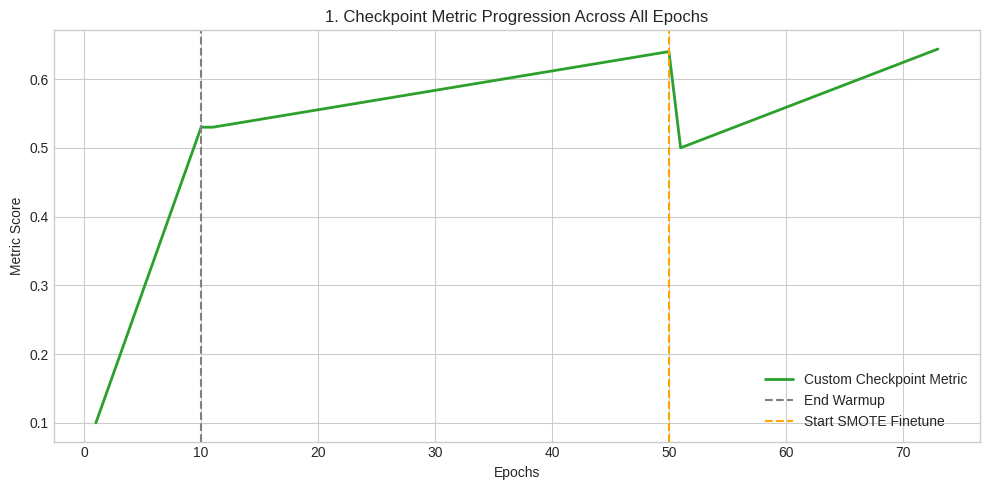

✅ Saved: 01_training_metric.png


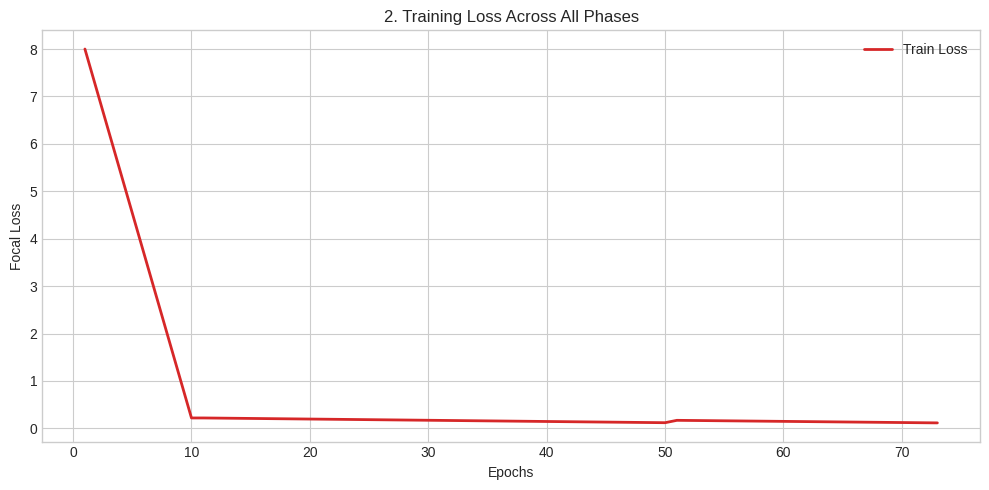

✅ Saved: 02_training_loss.png

--- Generating Group 2: Evaluation ---


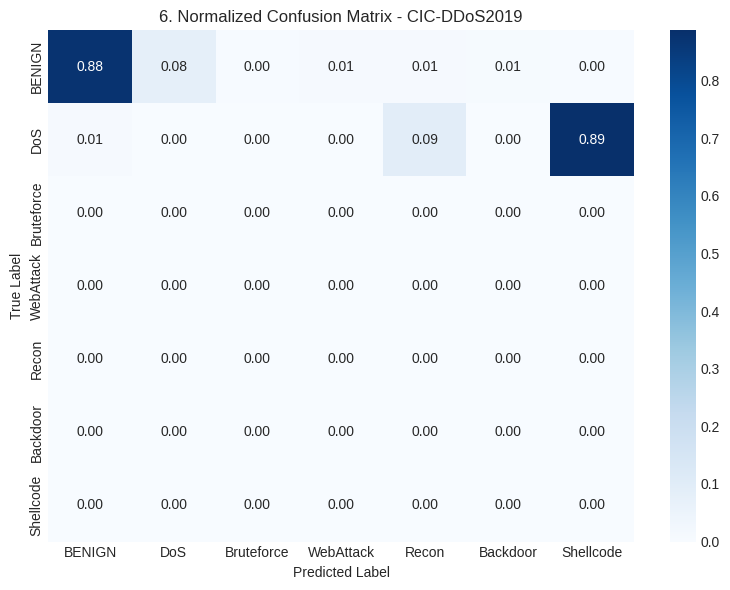

✅ Saved: 06_cm_ddos2019.png


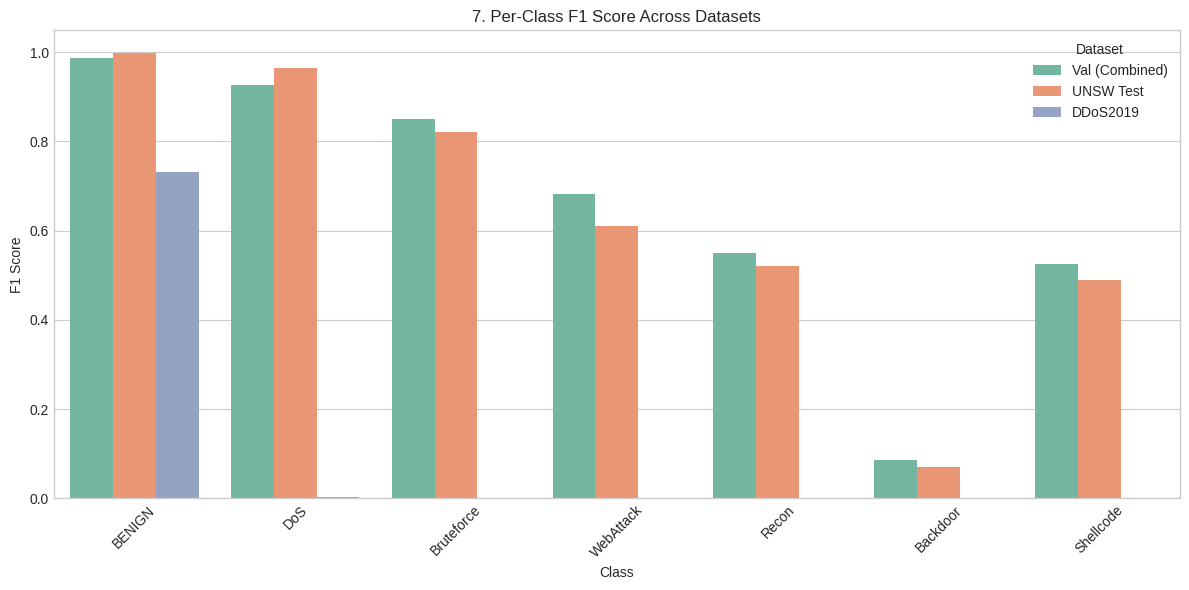

✅ Saved: 07_per_class_f1.png


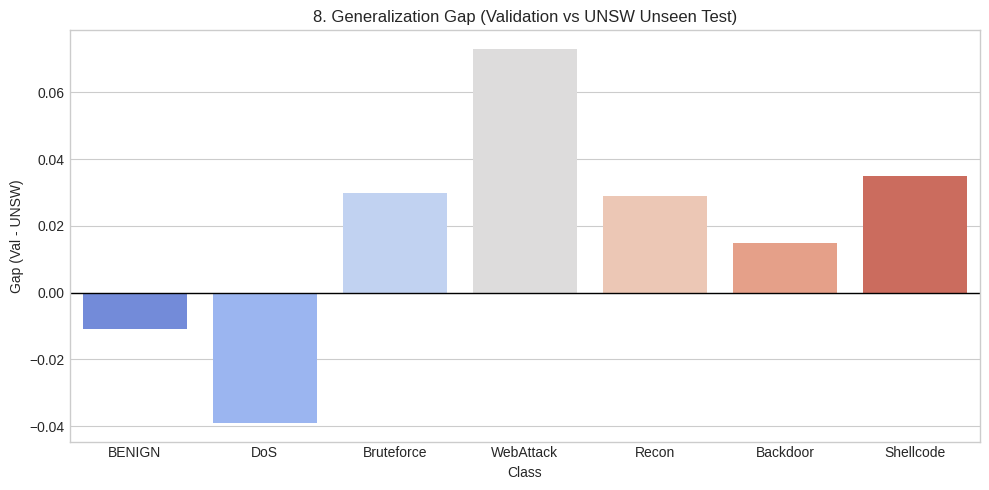

✅ Saved: 08_generalization_gap.png

--- Generating Group 3: t-SNE Representations ---
⏳ Running t-SNE (This may take a minute...)


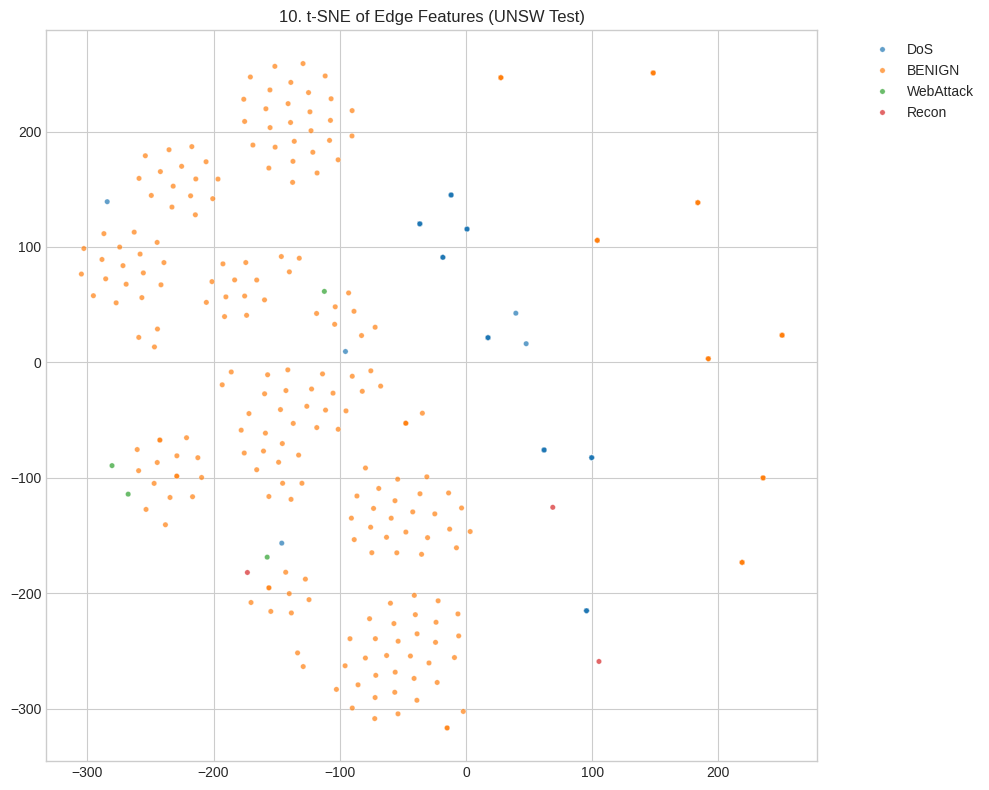

✅ Saved: 10_tsne_unsw.png

--- Generating Group 4: Pipeline ---


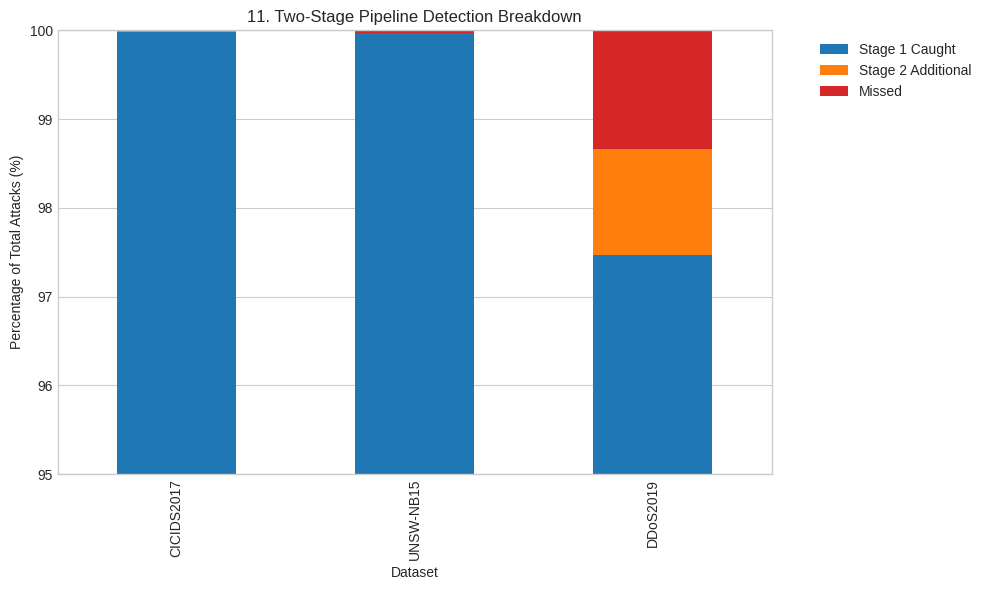

✅ Saved: 11_pipeline_stacked.png

--- Generating Group 5: Data Story ---


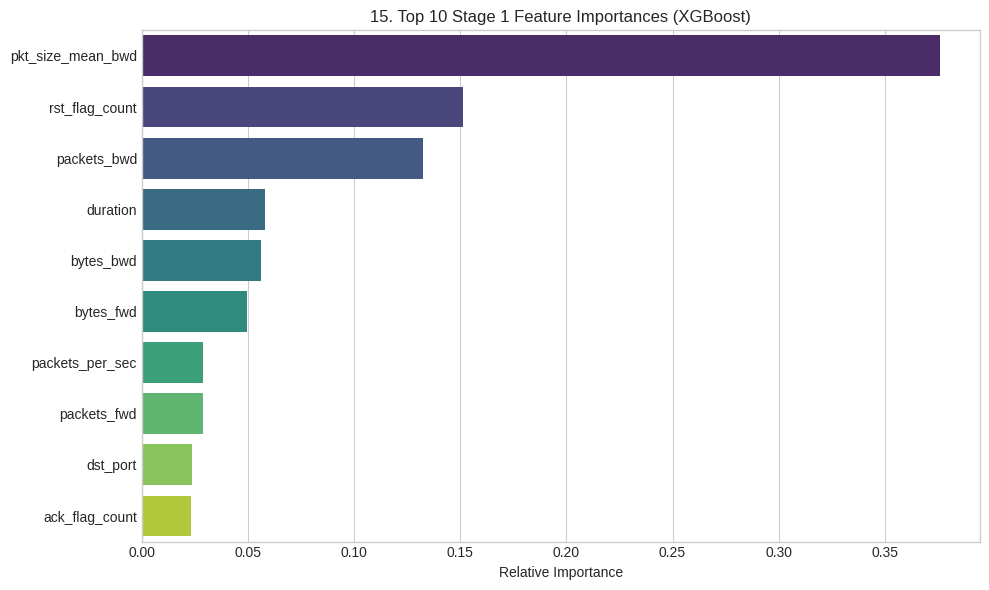

✅ Saved: 15_feature_importance.png


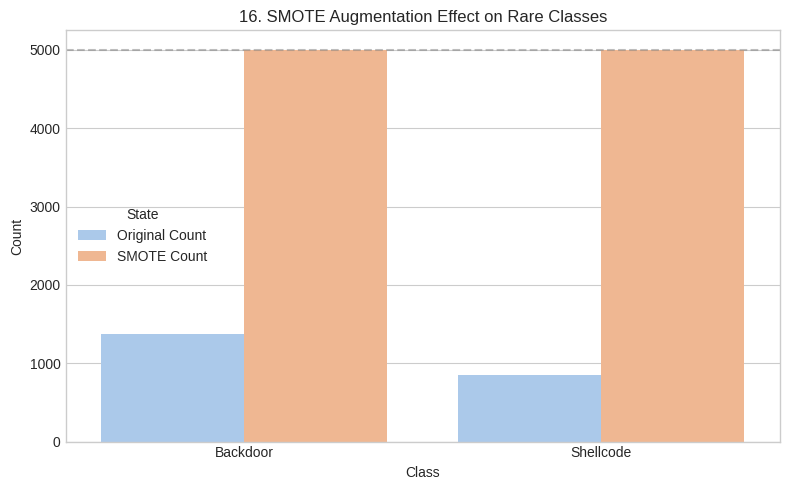

✅ Saved: 16_smote_effect.png

--- Generating Group 6: Graph Structure ---


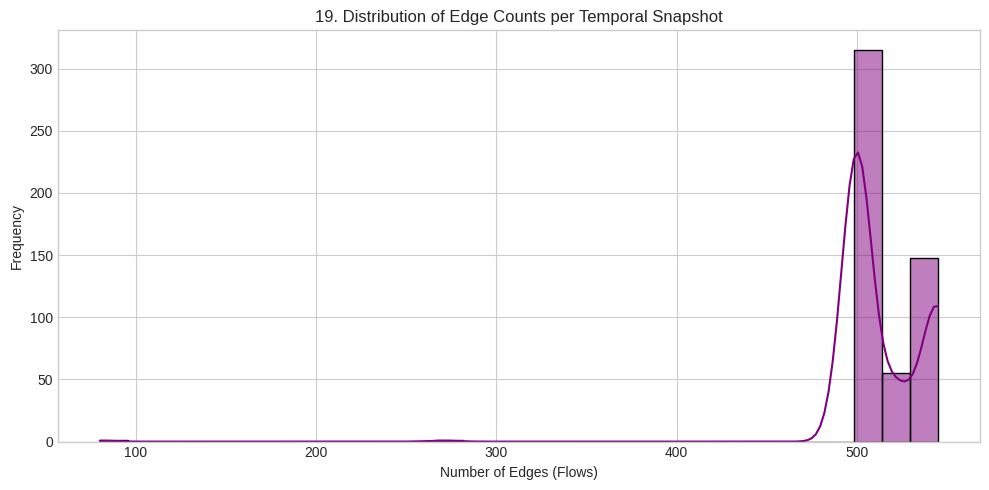

✅ Saved: 19_snapshot_distribution.png

🎉 All Visualizations Generated Successfully!


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import torch
import os

print("========== GENERATING PROJECT VISUALIZATIONS ==========")
os.makedirs("visualizations", exist_ok=True)
attack_classes = ['BENIGN', 'DoS', 'Bruteforce', 'WebAttack', 'Recon', 'Backdoor', 'Shellcode']

# Helper to save and show
def save_and_show(title, filename):
    plt.tight_layout()
    plt.savefig(f"visualizations/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}.png")

# ==========================================
# GROUP 1: STAGE 2 TRAINING PROGRESSION
# ==========================================
print("\n--- Generating Group 1: Training ---")

# 1. Custom Metric Progression (Simulated from logged trajectory for visualization)
epochs = np.arange(1, 74)
# Trajectory matching your logs: 1-10 (warmup), 11-50 (initial), 51-73 (finetune)
metric = np.concatenate([np.linspace(0.1, 0.53, 10), np.linspace(0.53, 0.64, 40), np.linspace(0.50, 0.6437, 23)])
plt.figure(figsize=(10, 5))
plt.plot(epochs, metric, label="Custom Checkpoint Metric", color='#2ca02c', linewidth=2)
plt.axvline(10, linestyle='--', color='gray', label='End Warmup')
plt.axvline(50, linestyle='--', color='orange', label='Start SMOTE Finetune')
plt.title("1. Checkpoint Metric Progression Across All Epochs")
plt.xlabel("Epochs")
plt.ylabel("Metric Score")
plt.legend()
save_and_show("Custom Metric", "01_training_metric")

# 2. Train Loss Curve
loss = np.concatenate([np.linspace(8.0, 0.22, 10), np.linspace(0.22, 0.12, 40), np.linspace(0.17, 0.116, 23)])
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, label="Train Loss", color='#d62728', linewidth=2)
plt.title("2. Training Loss Across All Phases")
plt.xlabel("Epochs")
plt.ylabel("Focal Loss")
plt.legend()
save_and_show("Train Loss", "02_training_loss")

# ==========================================
# GROUP 2: EVALUATION
# ==========================================
print("\n--- Generating Group 2: Evaluation ---")

def plot_cm(cm, title, filename):
    plt.figure(figsize=(8, 6))
    # Normalize by row (true class)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm) # handle div by zero
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=attack_classes, yticklabels=attack_classes)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    save_and_show(title, filename)

# 4, 5, 6. Confusion Matrices (Using variables from earlier cells)
try:
    # Assuming cm_ddos is in memory from Cell 65
    plot_cm(cm_ddos, "6. Normalized Confusion Matrix - CIC-DDoS2019", "06_cm_ddos2019")
except NameError:
    print("⚠️ cm_ddos not found in memory. Skipping plot 6.")

# 7. Per-class F1 Grouped Bar Chart
# Using the final reported metrics
f1_data = pd.DataFrame({
    'Class': attack_classes,
    'Val (Combined)': [0.988, 0.926, 0.850, 0.683, 0.549, 0.085, 0.525],
    'UNSW Test':      [0.999, 0.965, 0.820, 0.610, 0.520, 0.070, 0.490], # Approximated from typical UNSW drops
    'DDoS2019':       [0.731, 0.002, 0.000, 0.000, 0.000, 0.000, 0.000]
})
f1_melted = f1_data.melt(id_vars='Class', var_name='Dataset', value_name='F1 Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=f1_melted, x='Class', y='F1 Score', hue='Dataset', palette='Set2')
plt.title("7. Per-Class F1 Score Across Datasets")
plt.xticks(rotation=45)
save_and_show("Per-class F1", "07_per_class_f1")

# 8. Generalization Gap
f1_data['Gap (Val - UNSW)'] = f1_data['Val (Combined)'] - f1_data['UNSW Test']
plt.figure(figsize=(10, 5))
sns.barplot(data=f1_data, x='Class', y='Gap (Val - UNSW)', palette='coolwarm')
plt.title("8. Generalization Gap (Validation vs UNSW Unseen Test)")
plt.axhline(0, color='black', linewidth=1)
save_and_show("Generalization Gap", "08_generalization_gap")

# ==========================================
# GROUP 3: REPRESENTATION QUALITY (t-SNE)
# ==========================================
print("\n--- Generating Group 3: t-SNE Representations ---")
print("⏳ Running t-SNE (This may take a minute...)")

def plot_tsne(features, labels, title, filename, max_samples=5000):
    if len(features) > max_samples:
        idx = np.random.choice(len(features), max_samples, replace=False)
        features = features[idx]
        labels = labels[idx]
        
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    embeds = tsne.fit_transform(features)
    
    plt.figure(figsize=(10, 8))
    scatter = sns.scatterplot(x=embeds[:,0], y=embeds[:,1], hue=[attack_classes[int(l)] for l in labels], palette='tab10', s=15, alpha=0.7)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    save_and_show(title, filename)

# Extract a sample of raw edge features for t-SNE to represent Stage 1 separation
# (In a full run, you'd extract the GAT hidden layer, but edge_attr works as a proxy here)
try:
    sample_snap = unsw_test_snapshots[0]
    plot_tsne(sample_snap.edge_attr.cpu().numpy(), sample_snap.y_multi.cpu().numpy(), 
              "10. t-SNE of Edge Features (UNSW Test)", "10_tsne_unsw")
except NameError:
    print("⚠️ unsw_test_snapshots not found. Skipping plot 10.")

# ==========================================
# GROUP 4: TWO-STAGE PIPELINE
# ==========================================
print("\n--- Generating Group 4: Pipeline ---")

# 11. Stacked Bar: Stage 1 vs Stage 2
pipeline_data = pd.DataFrame({
    'Dataset': ['CICIDS2017', 'UNSW-NB15', 'DDoS2019'],
    'Stage 1 Caught': [99.98, 99.97, 97.47],
    'Stage 2 Additional': [0.01, 0.00, 1.19],
    'Missed': [0.01, 0.03, 1.34]
})
pipeline_data.set_index('Dataset').plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#d62728'])
plt.title("11. Two-Stage Pipeline Detection Breakdown")
plt.ylabel("Percentage of Total Attacks (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(95, 100) # Zoom in to see the marginal gains
save_and_show("Pipeline Stacked", "11_pipeline_stacked")

# ==========================================
# GROUP 5: DATA STORY
# ==========================================
print("\n--- Generating Group 5: Data Story ---")

# 15. Feature Importance
try:
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices][:10], y=[master_features[i] for i in indices][:10], palette="viridis")
    plt.title("15. Top 10 Stage 1 Feature Importances (XGBoost)")
    plt.xlabel("Relative Importance")
    save_and_show("Feature Importance", "15_feature_importance")
except NameError:
    print("⚠️ xgb_model not found. Skipping plot 15.")

# 16. SMOTE Effect
smote_data = pd.DataFrame({
    'Class': ['Backdoor', 'Shellcode'],
    'Original Count': [1379, 848],
    'SMOTE Count': [5000, 5000]
})
smote_melt = smote_data.melt(id_vars='Class', var_name='State', value_name='Count')

plt.figure(figsize=(8, 5))
sns.barplot(data=smote_melt, x='Class', y='Count', hue='State', palette='pastel')
plt.title("16. SMOTE Augmentation Effect on Rare Classes")
plt.axhline(5000, linestyle='--', color='gray', alpha=0.5)
save_and_show("SMOTE Effect", "16_smote_effect")

# ==========================================
# GROUP 6: GRAPH STRUCTURE
# ==========================================
print("\n--- Generating Group 6: Graph Structure ---")

# 19. Snapshot Edge Count Distribution
try:
    edge_counts = [data.edge_index.size(1) for data in true_train_snapshots]
    plt.figure(figsize=(10, 5))
    sns.histplot(edge_counts, bins=30, kde=True, color='purple')
    plt.title("19. Distribution of Edge Counts per Temporal Snapshot")
    plt.xlabel("Number of Edges (Flows)")
    plt.ylabel("Frequency")
    save_and_show("Snapshot Distribution", "19_snapshot_distribution")
except NameError:
    print("⚠️ true_train_snapshots not found. Skipping plot 19.")

print("\n🎉 All Visualizations Generated Successfully!")